# ST458 Group J — Strategy Development Notebook

Exploration, model selection, and final export pipeline for the systematic trading assignment.


In [ ]:
# Optional installs for Colab.
# Uses GPU acceleration when available.
%pip -q install lightgbm scikit-learn scipy statsmodels nbformat


### Environment setup and imports


In [ ]:
import os
import io
import json
import time
import math
import warnings
import traceback
import importlib.util
import sys
import subprocess
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any
from dataclasses import dataclass, asdict
from collections import defaultdict
from itertools import product
import pickle

os.environ.setdefault("TF_FORCE_GPU_ALLOW_GROWTH", "true")

def _detect_nvidia_gpu() -> Tuple[bool, str]:
    try:
        proc = subprocess.run(
            ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
            check=True,
            capture_output=True,
            text=True,
        )
        names = [x.strip() for x in proc.stdout.splitlines() if x.strip()]
        if names:
            return True, names[0]
    except Exception:
        pass
    return False, "CPU"

GPU_AVAILABLE, GPU_NAME = _detect_nvidia_gpu()

GPU_ACCEL_REPORT = {
    "gpu_available": bool(GPU_AVAILABLE),
    "gpu_name": GPU_NAME,
    "cudf_pandas_loaded": False,
    "cuml_accel_loaded": False,
    "lightgbm_device_mode": "cpu",
    "lightgbm_gpu_probe_error": None,
    "tf_gpu_count": 0,
    "tf_mixed_precision": False,
}

def _maybe_load_ipython_extension(ext_name: str) -> bool:
    try:
        ip = get_ipython()
    except Exception:
        ip = None
    if ip is None:
        return False
    try:
        ip.run_line_magic("load_ext", ext_name)
        return True
    except Exception:
        return False

if GPU_AVAILABLE:
    GPU_ACCEL_REPORT["cudf_pandas_loaded"] = _maybe_load_ipython_extension("cudf.pandas")
    GPU_ACCEL_REPORT["cuml_accel_loaded"] = _maybe_load_ipython_extension("cuml.accel")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from sklearn.linear_model import Ridge, ElasticNet, HuberRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 5)
SEED = 42
np.random.seed(SEED)

try:
    import lightgbm as lgb
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception:
    HAS_TF = False

if HAS_TF:
    try:
        gpus = tf.config.list_physical_devices("GPU")
        GPU_ACCEL_REPORT["tf_gpu_count"] = len(gpus)
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

PROJECT_SLUG = "st458_assignment_s_v26_aligned"

if Path("/content").exists():
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    PROJECT_DIR = Path("/content/drive/MyDrive/ST458") / PROJECT_SLUG
else:
    PROJECT_DIR = Path("/mnt/data") / PROJECT_SLUG

DATA_DIR = PROJECT_DIR / "data"
MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = PROJECT_DIR / "figures"
TABLES_DIR = PROJECT_DIR / "tables"
SUBMISSION_DIR = PROJECT_DIR / "submission"
TESTS_DIR = PROJECT_DIR / "tests"
CACHE_DIR = PROJECT_DIR / "cache"

for p in [PROJECT_DIR, DATA_DIR, MODELS_DIR, RESULTS_DIR, FIGURES_DIR, TABLES_DIR, SUBMISSION_DIR, TESTS_DIR, CACHE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

def _atomic_pickle_dump(obj: Any, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    with open(tmp_path, "wb") as f:
        pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)
    os.replace(tmp_path, path)

def _safe_pickle_load(path: Path) -> Any:
    with open(path, "rb") as f:
        return pickle.load(f)

def _atomic_csv_write(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    df.to_csv(tmp_path, index=False)
    os.replace(tmp_path, path)

def _safe_read_checkpoint_csv(path: Path, expected_columns: Optional[List[str]] = None) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame(columns=expected_columns or [])
    df = pd.read_csv(path)
    if expected_columns:
        for col in expected_columns:
            if col not in df.columns:
                df[col] = np.nan
        df = df[expected_columns + [c for c in df.columns if c not in expected_columns]]
    return df

def _key_tuple(*parts: Any) -> Tuple[str, ...]:
    out = []
    for p in parts:
        if pd.isna(p):
            out.append("")
        else:
            out.append(str(p))
    return tuple(out)

CONFIG = {
    "seed": SEED,
    "cost_rate": 5e-4,
    "runtime_limit_seconds": 600.0,
    "target_daily_vol": 0.012,
    "prefer_gpu": True,
    "use_cudf_pandas_if_available": True,
    "use_cuml_accel_if_available": True,
    "float_dtype": "float32",
    "lightgbm_device_preference": ["cuda", "gpu", "cpu"],
        "enable_tf_mixed_precision": True,
    "data_candidates": [
        DATA_DIR / "df_train.csv",
        PROJECT_DIR / "df_train.csv",
        Path("/content/df_train.csv"),
        Path("/mnt/data/df_train.csv"),
        Path("df_train.csv"),
    ],
    "ridge_alpha_grid": [1.0, 5.0, 20.0],
    "elastic_alpha_grid": [0.0005, 0.002],
    "elastic_l1_ratio_grid": [0.15, 0.5],
    "huber_epsilon_grid": [1.35, 1.8],
    "rf_grid": [
        {"n_estimators": 120, "max_depth": 6, "min_samples_leaf": 8},
        {"n_estimators": 180, "max_depth": 8, "min_samples_leaf": 6},
    ],
    "lgbm_grid": [
        {"num_leaves": 31, "learning_rate": 0.05, "feature_fraction": 0.8, "min_data_in_leaf": 80},
        {"num_leaves": 63, "learning_rate": 0.03, "feature_fraction": 0.7, "min_data_in_leaf": 100},
    ],
    "mlp_grid": [
        {"hidden_layer_sizes": (64, 32), "alpha": 1e-4},
        {"hidden_layer_sizes": (96, 48), "alpha": 3e-4},
    ],
    "outer_min_train_days": 420,
    "outer_valid_days": 84,
    "outer_step_days": 84,
    "inner_min_train_days": 252,
    "inner_valid_days": 63,
    "inner_step_days": 63,
    "long_valid_days": 126,
    "peer_window": 63,
    "pair_z_window": 20,
    "beta_window_fast": 20,
    "beta_window_slow": 60,
    "cluster_k": 6,
    "pca_components": 3,
    "max_selected_features": 55,
    "collinearity_threshold": 0.92,
    "feature_min_abs_ic": 0.003,
    "feature_min_sign_consistency": 0.55,
    "top_n_grid": [8, 12, 16],
    "gross_grid": [0.8, 1.0, 1.2],
    "mapping_methods": ["top_bottom", "zscore", "sigmoid", "softmax"],
    "net_exposure_modes": ["neutral", "weak_long", "mild_tilt"],
    "no_trade_band_grid": [0.0000, 0.0015, 0.0030],
    "per_asset_cap_grid": [0.03, 0.04],
    "daily_turnover_cap_grid": [0.50, 0.75],
    "trade_cap_grid": [0.03, 0.05],
    "confidence_band_grid": [0.10, 0.20],
    "edge_cost_multiplier_grid": [1.0, 1.5],
    "run_lgbm": True,
    "run_mlp": False,
    "run_sequence_ablation": False,
    "sequence_lookback": 10,
    "sequence_epochs": 2,
    "sequence_batch_size": 1024,
    "sequence_train_sample_cap": 30000,
    "recalibration_every_n_days": 21,
    "runtime_benchmark_repeats": 2,
    "max_feature_drop_tests": 10,
    "robustness_top_k": 5,
    "target_variant_candidates": {
        "generic_regression": ["target_r1", "target_sign_next", "target_bucket_next", "target_voladj_next", "target_resid_next"],
        "rank": ["target_rank_next"],
        "alpha": ["target_r1", "target_rank_next", "target_resid_next"]
    },
    "long_fold_top_k": 3,
    "boundary_shift_days": [5, 10],
    "proof_pack_version": "final",
    "finalist_exact_audit_max_count": 3,
    "confidence_recalibration_window": 21,
    "overlay_recalibration_window": 21,
    "min_overlay_weight": 0.05,
    "overlay_weight_shrinkage": 0.60,
    "confidence_scale_bounds": [0.45, 1.45],
    "live_feature_support": ["ret_1", "ret_2", "ret_3", "ret_5", "ret_10", "ret_20", "ret_40", "ret_63", "oc_ret_0", "gap_co_1", "range_0", "close_loc_0", "body_ratio_0", "upper_wick_0", "lower_wick_0", "ma_gap_5", "ma_gap_10", "ma_gap_20", "ma_gap_40", "dist_min_5", "dist_min_10", "dist_min_20", "dist_min_40", "dist_max_5", "dist_max_10", "dist_max_20", "dist_max_40", "vol_5", "vol_10", "vol_20", "down_vol_5", "down_vol_10", "down_vol_20", "up_vol_5", "up_vol_10", "up_vol_20", "ret_mean_5", "ret_mean_10", "ret_mean_20", "mom_5_20", "mom_10_40", "accel_1_5_20", "cond_reversal_1", "signed_sqrt_absret_1", "log_volume", "vol_chg_1", "vol_surprise_5", "vol_surprise_20", "volume_vol_20", "bigmove_x_volsurprise", "signedmove_x_volume", "range_x_volume", "liq_pressure_proxy", "turnover_pressure", "market_ret_1", "market_vol_20", "beta_20", "beta_60", "resid_ret_1", "resid_mom_5", "idio_vol_20", "dispersion_20", "xs_rank_ret_1", "xs_z_ret_1", "xs_rank_ret_5", "xs_z_ret_5", "xs_rank_ret_10", "xs_z_ret_10", "xs_rank_ret_20", "xs_z_ret_20", "xs_rank_gap_co_1", "xs_z_gap_co_1", "xs_rank_mom_5_20", "xs_z_mom_5_20", "xs_rank_mom_10_40", "xs_z_mom_10_40", "xs_rank_ma_gap_20", "xs_z_ma_gap_20", "xs_rank_vol_surprise_5", "xs_z_vol_surprise_5", "xs_rank_vol_surprise_20", "xs_z_vol_surprise_20", "xs_rank_range_0", "xs_z_range_0", "xs_rank_close_loc_0", "xs_z_close_loc_0", "xs_rank_resid_ret_1", "xs_z_resid_ret_1", "xs_rank_idio_vol_20", "xs_z_idio_vol_20", "xs_rank_down_vol_20", "xs_z_down_vol_20"],
    "final_supported_families": ["ridge", "elastic", "huber", "rank_ridge", "lgbm"],
    "final_feature_prune_gain_threshold": 0.0025,
    "finalist_max_count": 3,
    "final_export_include_optional_bundles": False,
    "final_export_include_manual_alpha": False,
    "proof_required_files": [
        "final_summary.json",
        "proof_pack.json",
        "proof_artifact_hashes.csv",
        "proof_checklist.csv",
        "runtime_benchmark_repeats.csv",
        "proof_required_file_status.csv"
    ],
}



CONFIG.update({

"notebook_version": "final",
"project_slug": "st458_assignment_s_v26_aligned",
"proof_pack_version": "final",
"main_search_families": ["ridge", "elastic", "huber", "lgbm"],
"report_only_exploration_families": ["rf", "mlp", "rank_ridge", "rank_lgbm", "alpha_family"],
"run_report_sequence_ablation": True,
"focused_target_candidates": {
    "ridge": ["target_resid_next", "target_r1"],
    "elastic": ["target_resid_next", "target_r1"],
    "huber": ["target_resid_next", "target_r1"],
    "lgbm": ["target_r1", "target_resid_next"],
},
"report_exploration_top_k": 24,
"safe_contender_families": ["ridge", "elastic", "huber"],
"upside_contender_families": ["lgbm"],
"safe_candidate_thresholds": {
    "long_mean_log": 0.1350,
    "long_min_log": 0.0444,
    "boundary_min_log": 0.1630,
    "robustness_min_log": 0.1485,
},
"safe_threshold_required_count": 2,
"upside_switch_thresholds": {
    "long_mean_log": 0.1543,
    "long_min_log": 0.0,
},
"upside_min_primary_margin_vs_safe": 0.0,
"upside_max_robustness_gap_vs_safe": 0.0,
"upside_max_smoke_gap_vs_safe": 0.0,
    "final_supported_families": ["ridge", "elastic", "huber", "rank_ridge", "lgbm"],
    "focused_finalist_families": ["ridge", "elastic", "huber", "lgbm"],
    "focused_finalist_challenger_tolerance": 0.01,
    "focused_finalist_min_pool_size": 6,
    "robustness_top_k": 8,
    "long_fold_top_k": 6,
    "prefinalist_retest_top_k": 8,
    "finalist_max_count": 4,
    "finalist_exact_audit_max_count": 4,
    "final_feature_prune_gain_threshold": 0.0025,
    "robustness_promotion_min_delta": 0.002,
    "feature_drop_promotion_min_delta": 0.01,
    "promotable_robustness_tests": ["turnover_tighter", "notrade_wider", "mild_tilt_mode", "trade_cap_tighter", "gross_up"],
    "disallowed_auto_promotion_tests": ["softmax_mapping"],
    "final_submission_zip_name": "GroupJ_submission_clean.zip",
    "local_check_bundle_zip_name": "GroupJ_local_check_bundle.zip",
    "readme_submission_name": "README_submission.txt",
    "full_portfolio_axes": {
        "gross_exposure": [0.8, 1.0, 1.2],
        "mapping_method": ["top_bottom", "zscore", "sigmoid", "softmax"],
        "net_mode": ["neutral", "weak_long", "mild_tilt"],
        "top_n": [8, 12, 16],
        "no_trade_band": [0.0000, 0.0015, 0.0030],
        "per_asset_cap": [0.03, 0.04],
        "daily_turnover_cap": [0.50, 0.75],
        "trade_cap": [0.03, 0.05],
        "confidence_band": [0.10, 0.20],
        "edge_cost_multiplier": [1.0, 1.5],
    },
    "portfolio_search_axes": {
        "gross_exposure": [0.8],
        "mapping_method": ["top_bottom"],
        "net_mode": ["neutral", "mild_tilt"],
        "top_n": [8, 12, 16],
        "no_trade_band": [0.0000, 0.0015],
        "per_asset_cap": [0.04],
        "daily_turnover_cap": [0.40, 0.50],
        "trade_cap": [0.05],
        "confidence_band": [0.10],
        "edge_cost_multiplier": [1.0],
    },
    "proof_required_files": [
        "final_summary.json",
        "proof_pack.json",
        "proof_artifact_hashes.csv",
        "proof_checklist.csv",
        "runtime_benchmark_repeats.csv",
        "proof_required_file_status.csv"
    ],
})

CONFIG["lgbm_grid"] = [
    {
        "num_leaves": int(num_leaves),
        "learning_rate": float(learning_rate),
        "feature_fraction": float(feature_fraction),
        "min_data_in_leaf": int(min_data_in_leaf),
    }
    for num_leaves in [31, 63]
    for learning_rate in [0.03, 0.05]
    for feature_fraction in [0.7, 0.8]
    for min_data_in_leaf in [80, 100]
]

MODEL_NUMPY_DTYPE = np.float32 if (CONFIG["prefer_gpu"] and GPU_AVAILABLE and CONFIG["float_dtype"] == "float32") else np.float64

def detect_lightgbm_execution_mode() -> str:
    if (not HAS_LGBM) or (not GPU_AVAILABLE) or (not CONFIG["prefer_gpu"]):
        return "cpu"
    probe_x = np.random.RandomState(SEED).randn(128, 8).astype(np.float32)
    probe_y = np.random.RandomState(SEED + 1).randn(128).astype(np.float32)
    ds = lgb.Dataset(probe_x, label=probe_y)
    for mode in CONFIG["lightgbm_device_preference"]:
        try:
            lgb.train(
                params={
                    "objective": "regression",
                    "metric": "l2",
                    "verbosity": -1,
                    "seed": SEED,
                    "device_type": mode,
                    "num_leaves": 15,
                    "learning_rate": 0.1,
                    "min_data_in_leaf": 10,
                    "feature_fraction": 1.0,
                    "max_bin": 63 if mode in ["cuda", "gpu"] else 255,
                    **({"num_gpu": 1} if mode == "cuda" else {}),
                    **({"gpu_use_dp": True} if mode == "gpu" else {}),
                },
                train_set=ds,
                num_boost_round=4,
            )
            return mode
        except Exception as e:
            GPU_ACCEL_REPORT["lightgbm_gpu_probe_error"] = str(e)
            continue
    return "cpu"

LIGHTGBM_DEVICE_MODE = detect_lightgbm_execution_mode()
GPU_ACCEL_REPORT["lightgbm_device_mode"] = LIGHTGBM_DEVICE_MODE

print("HAS_LGBM:", HAS_LGBM, "| HAS_TF:", HAS_TF)
print("Project dir:", PROJECT_DIR)
print("GPU acceleration report:", GPU_ACCEL_REPORT)


Mounted at /content/drive
HAS_LGBM: True | HAS_TF: True
Project dir: /content/drive/MyDrive/ST458/st458_assignment_s_v26_aligned
GPU acceleration report: {'gpu_available': False, 'gpu_name': 'CPU', 'cudf_pandas_loaded': False, 'cuml_accel_loaded': False, 'lightgbm_device_mode': 'cpu', 'lightgbm_gpu_probe_error': None, 'tf_gpu_count': 0, 'tf_mixed_precision': False}


## 1. Load and audit the raw data

Separates hard blockers (contract violations) from soft warnings (synthetic-data quirks). Exports audit tables and figures.


In [ ]:
def locate_training_file(candidates: List[Path]) -> Path:
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError("df_train.csv not found. Upload it or update CONFIG['data_candidates'].")

def load_market_data(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["date"] = pd.to_datetime(df["date"])
    return df

def audit_market_panel(df: pd.DataFrame) -> Dict[str, Any]:
    required_cols = ["date", "symbol", "open", "close", "low", "high", "volume"]
    hard_blockers = []
    soft_warnings = []

    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        hard_blockers.append(f"Missing required columns: {missing_cols}")

    out = {
        "required_cols": required_cols,
        "n_rows": int(len(df)),
        "n_cols": int(df.shape[1]),
        "columns": list(df.columns),
        "n_dates": int(df["date"].nunique()) if "date" in df.columns else None,
        "n_symbols": int(df["symbol"].nunique()) if "symbol" in df.columns else None,
    }

    if "date" in df.columns:
        out["date_min"] = str(df["date"].min().date())
        out["date_max"] = str(df["date"].max().date())

    if df[required_cols].isna().any().any():
        null_counts = df[required_cols].isna().sum()
        hard_blockers.append(f"Missing values detected: {null_counts[null_counts > 0].to_dict()}")

    dup_count = int(df.duplicated(subset=["date", "symbol"]).sum())
    out["duplicate_date_symbol_rows"] = dup_count
    if dup_count > 0:
        hard_blockers.append(f"Duplicate (date, symbol) rows found: {dup_count}")

    rows_per_date = df.groupby("date").size().sort_index()
    rows_per_symbol = df.groupby("symbol").size().sort_index()
    out["rows_per_date_min"] = int(rows_per_date.min())
    out["rows_per_date_max"] = int(rows_per_date.max())
    out["rows_per_symbol_min"] = int(rows_per_symbol.min())
    out["rows_per_symbol_max"] = int(rows_per_symbol.max())

    if rows_per_date.nunique() != 1:
        hard_blockers.append("Rows per date are not constant.")
    if rows_per_symbol.nunique() != 1:
        soft_warnings.append("Rows per symbol vary across the sample.")
    if rows_per_date.min() != out["n_symbols"]:
        hard_blockers.append("At least one date does not contain one row per symbol.")

    stable_symbol_order = True
    first_order = None
    order_mismatch_dates = []
    for d, g in df.groupby("date", sort=True):
        current = tuple(g["symbol"].tolist())
        if first_order is None:
            first_order = current
        elif current != first_order:
            stable_symbol_order = False
            order_mismatch_dates.append(str(pd.Timestamp(d).date()))
            if len(order_mismatch_dates) >= 10:
                break
    out["stable_symbol_row_order"] = bool(stable_symbol_order)
    if not stable_symbol_order:
        soft_warnings.append(f"Symbol row order varies across dates. First mismatches: {order_mismatch_dates}")

    numeric_cols = ["open", "close", "low", "high", "volume"]
    non_positive = {c: int((df[c] <= 0).sum()) for c in numeric_cols}
    out["non_positive_counts"] = non_positive
    if any(v > 0 for v in non_positive.values()):
        hard_blockers.append(f"Non-positive values detected: {non_positive}")

    bar_logic = pd.DataFrame({
        "low_gt_min_oc": (df["low"] > df[["open", "close"]].min(axis=1)).astype(int),
        "high_lt_max_oc": (df["high"] < df[["open", "close"]].max(axis=1)).astype(int),
        "low_gt_high": (df["low"] > df["high"]).astype(int),
    })
    out["bar_logic_warning_rows"] = {c: int(bar_logic[c].sum()) for c in bar_logic.columns}
    total_bar_warn = int((bar_logic.sum(axis=1) > 0).sum())
    out["bar_logic_any_warning_rows"] = total_bar_warn
    if total_bar_warn > 0:
        soft_warnings.append(
            f"Synthetic OHLC anomalies detected on {total_bar_warn} rows; treated as warnings, not hard blockers."
        )

    panel = df.assign(flag=1).pivot(index="date", columns="symbol", values="flag").sort_index().sort_index(axis=1)
    missing_panel = panel.isna()
    out["missing_symbol_date_cells"] = int(missing_panel.sum().sum())
    continuity_by_symbol = 1.0 - missing_panel.mean(axis=0)
    out["symbol_coverage_continuity_min"] = float(continuity_by_symbol.min())
    out["symbol_coverage_continuity_mean"] = float(continuity_by_symbol.mean())
    if out["missing_symbol_date_cells"] > 0:
        hard_blockers.append("The symbol-date panel is incomplete.")

    ret1 = df.sort_values(["symbol", "date"]).groupby("symbol")["close"].pct_change()
    vol_z = (
        np.log1p(df["volume"])
        .groupby(df["symbol"])
        .transform(lambda s: (s - s.rolling(20, min_periods=10).mean()) / s.rolling(20, min_periods=10).std())
    )
    out["abs_ret_gt_25pct_rows"] = int((ret1.abs() > 0.25).sum())
    out["volume_z_gt_5_rows"] = int((vol_z.abs() > 5).sum())
    if out["abs_ret_gt_25pct_rows"] > 0:
        soft_warnings.append(f"Large close-to-close moves >25% on {out['abs_ret_gt_25pct_rows']} rows.")
    if out["volume_z_gt_5_rows"] > 0:
        soft_warnings.append(f"Extreme rolling volume z-scores >5 on {out['volume_z_gt_5_rows']} rows.")

    out["hard_blockers"] = hard_blockers
    out["soft_warnings"] = soft_warnings
    out["hard_blocker_count"] = len(hard_blockers)
    out["soft_warning_count"] = len(soft_warnings)
    return out

train_path = locate_training_file(CONFIG["data_candidates"])
df_raw = load_market_data(train_path)
audit = audit_market_panel(df_raw)

print("Training file:", train_path)
print("Hard blockers:", audit["hard_blockers"])
print("Soft warnings:")
for w in audit["soft_warnings"]:
    print("-", w)

assert audit["hard_blocker_count"] == 0, f"Hard blockers found: {audit['hard_blockers']}"


Training file: /content/df_train.csv
Hard blockers: []
Soft warnings:
- Synthetic OHLC anomalies detected on 95613 rows; treated as warnings, not hard blockers.
- Large close-to-close moves >25% on 13 rows.


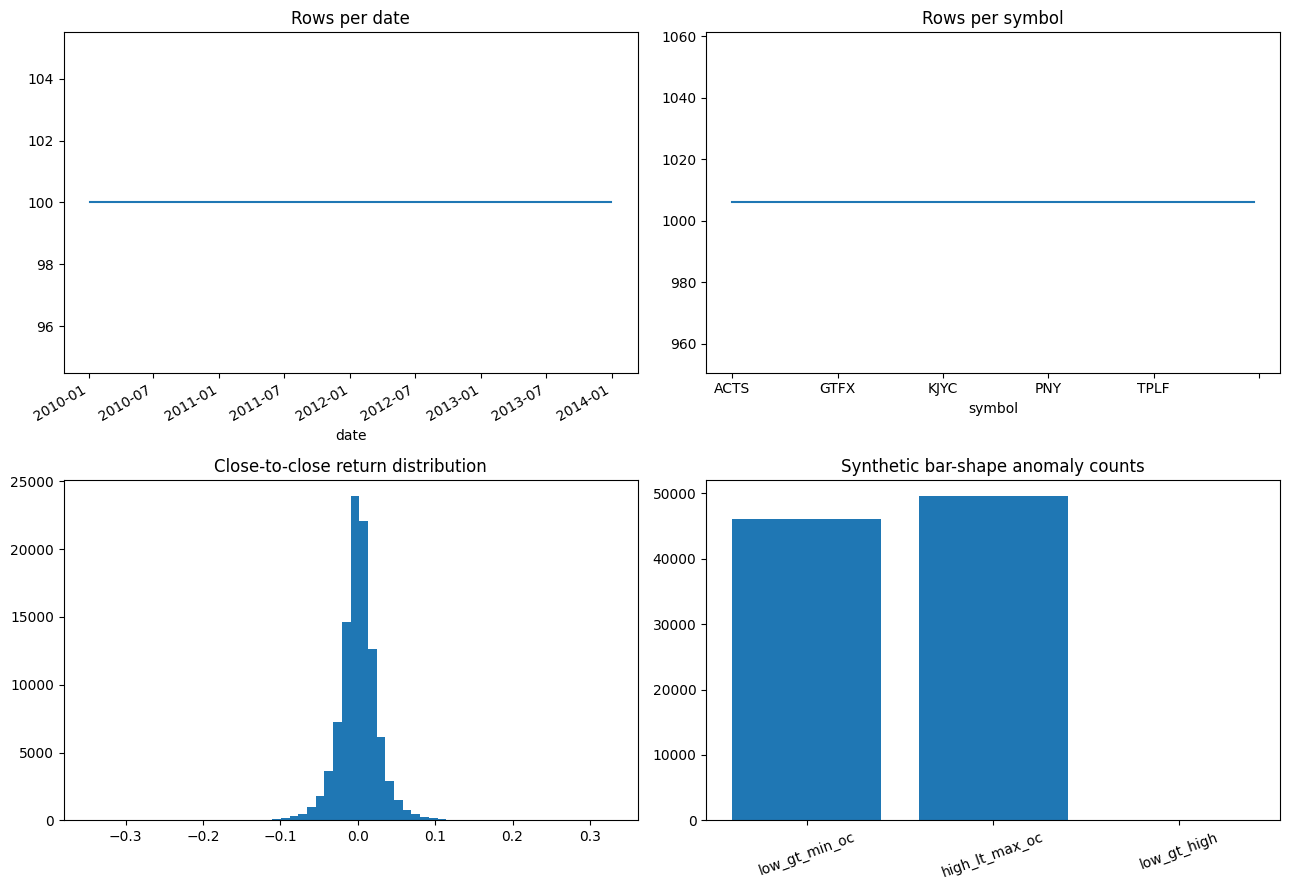

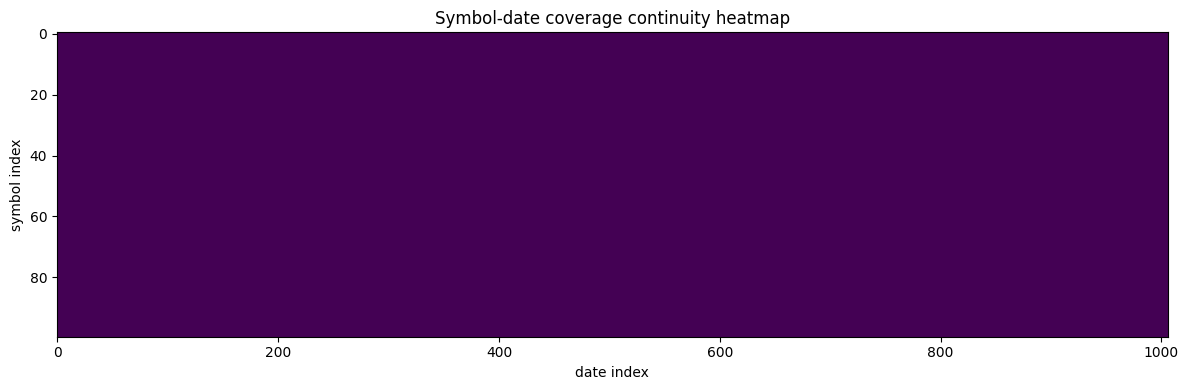

,metric,value
0,rows,100600
1,columns,7
2,dates,1006
3,symbols,100
4,date_min,2010-01-04
5,date_max,2013-12-31
6,stable_symbol_row_order,True
7,hard_blocker_count,0
8,soft_warning_count,2
9,abs_ret_gt_25pct_rows,13


,warning_type,count
0,low_gt_min_oc,46073
1,high_lt_max_oc,49540
2,low_gt_high,0


,date,symbol,open,close,low,high,volume
0,2010-01-04,ACTS,15.13,14.97,14.84,15.28,5459.882
1,2010-01-04,AMWD,7.00,7.12,6.98,7.14,92067.275
2,2010-01-04,ARV,18.27,18.31,18.12,18.47,38034.257
3,2010-01-04,BBY,3.11,3.11,3.09,3.13,40964.820
4,2010-01-04,BCDM,19.78,19.53,19.41,19.90,3646.991


,date,symbol,open,close,low,high,volume
100595,2013-12-31,XTG,20.15,20.00,20.15,20.15,42044.703
100596,2013-12-31,YPN,14.94,14.82,14.94,14.94,29030.106
100597,2013-12-31,YRD,3.40,3.39,3.40,3.40,11778.336
100598,2013-12-31,YVNL,4.25,4.24,4.25,4.25,6431.843
100599,2013-12-31,ZQN,32.01,32.04,32.01,32.01,54319.469


In [ ]:
audit_summary_df = pd.DataFrame([
    ["rows", audit["n_rows"]],
    ["columns", audit["n_cols"]],
    ["dates", audit["n_dates"]],
    ["symbols", audit["n_symbols"]],
    ["date_min", audit["date_min"]],
    ["date_max", audit["date_max"]],
    ["stable_symbol_row_order", audit["stable_symbol_row_order"]],
    ["hard_blocker_count", audit["hard_blocker_count"]],
    ["soft_warning_count", audit["soft_warning_count"]],
    ["abs_ret_gt_25pct_rows", audit["abs_ret_gt_25pct_rows"]],
    ["volume_z_gt_5_rows", audit["volume_z_gt_5_rows"]],
    ["bar_logic_any_warning_rows", audit["bar_logic_any_warning_rows"]],
], columns=["metric", "value"])
audit_summary_df.to_csv(TABLES_DIR / "audit_summary.csv", index=False)

audit_bar_logic_df = pd.DataFrame(list(audit["bar_logic_warning_rows"].items()), columns=["warning_type", "count"])
audit_bar_logic_df.to_csv(TABLES_DIR / "audit_bar_logic.csv", index=False)

rows_per_date = df_raw.groupby("date").size().sort_index()
rows_per_symbol = df_raw.groupby("symbol").size().sort_index()
ret1_long = df_raw.sort_values(["symbol", "date"]).groupby("symbol")["close"].pct_change()

fig, ax = plt.subplots(2, 2, figsize=(13, 9))
rows_per_date.plot(ax=ax[0, 0], title="Rows per date")
rows_per_symbol.sort_values().plot(ax=ax[0, 1], title="Rows per symbol")
ax[1, 0].hist(ret1_long.dropna(), bins=60)
ax[1, 0].set_title("Close-to-close return distribution")
ax[1, 1].bar(audit_bar_logic_df["warning_type"], audit_bar_logic_df["count"])
ax[1, 1].set_title("Synthetic bar-shape anomaly counts")
for lab in ax[1, 1].get_xticklabels():
    lab.set_rotation(20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_data_audit_overview.png", dpi=150, bbox_inches="tight")
plt.show()

continuity_df = (
    df_raw.assign(flag=1)
    .pivot(index="date", columns="symbol", values="flag")
    .sort_index()
    .sort_index(axis=1)
    .notna()
    .astype(int)
)
plt.figure(figsize=(12, 4))
continuity_values = np.asarray(continuity_df.T.to_numpy(dtype=np.int8, copy=True), dtype=np.uint8)
plt.imshow(continuity_values, aspect="auto", interpolation="nearest")
plt.title("Symbol-date coverage continuity heatmap")
plt.xlabel("date index")
plt.ylabel("symbol index")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_symbol_continuity_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

display(audit_summary_df)
display(audit_bar_logic_df)
display(df_raw.head())
display(df_raw.tail())


## 2. Evaluator clone and tests

Python clone of the supplied evaluator logic, plus unit tests.


In [ ]:
def split_like_walk_forward(df: pd.DataFrame, cutoff: str = "2012-01-01") -> Tuple[pd.DataFrame, pd.DataFrame]:
    cutoff_ts = pd.Timestamp(cutoff)
    train_mask = df["date"] < cutoff_ts
    return df.loc[train_mask].copy(), df.loc[~train_mask].copy()

def python_walk_forward(strategy, initialiser, df_train: pd.DataFrame, df_test: pd.DataFrame, cost_rate: float = 0.0005):
    state = initialiser(df_train)
    test_dates = np.sort(df_test["date"].unique())
    symbols = sorted(df_train["symbol"].unique())

    positions = pd.Series(0.0, index=symbols, dtype=float)
    daily_pnl = []
    daily_turnover = []
    daily_gross = []
    prev_close = None

    for i, d in enumerate(test_dates):
        new_data = (
            df_test.loc[df_test["date"] == d]
            .sort_values("symbol")
            .reset_index(drop=True)
        )
        out = strategy(new_data, state)
        if isinstance(out, tuple) and len(out) == 2:
            trades_raw, state = out
        elif isinstance(out, dict):
            trades_raw, state = out["trades"], out["new_state"]
        else:
            raise ValueError("Strategy output must be tuple(trades, new_state) or dict with keys trades/new_state.")

        trades = pd.Series(trades_raw, dtype=float).reindex(symbols).fillna(0.0)
        price = new_data.set_index("symbol")["close"].reindex(symbols).astype(float)

        if i == 0:
            pnl = - cost_rate * float(trades.abs().sum())
            positions = trades.copy()
        else:
            r1d = price / prev_close - 1.0
            pnl = float((positions * r1d).sum()) - cost_rate * float(trades.abs().sum())
            positions = positions * (1.0 + r1d) + trades

        daily_pnl.append(pnl)
        daily_turnover.append(float(trades.abs().sum()))
        daily_gross.append(float(positions.abs().sum()))
        prev_close = price.copy()

    wealth_seq = 1.0 + np.cumsum(np.array(daily_pnl, dtype=float))
    ruined = wealth_seq <= 0
    if ruined.any():
        first_bad = int(np.where(ruined)[0][0])
        wealth_seq[first_bad:] = 0.0

    out = {
        "wealth_seq": wealth_seq,
        "daily_pnl": np.array(daily_pnl, dtype=float),
        "daily_turnover": np.array(daily_turnover, dtype=float),
        "daily_gross": np.array(daily_gross, dtype=float),
    }
    return out

def _toy_initialiser(df_train):
    symbols = sorted(df_train["symbol"].unique())
    return {"symbols": symbols}

def _toy_day1_cost_only_strategy(new_data, state):
    symbols = state["symbols"]
    trades = pd.Series(0.1, index=symbols)
    return {"trades": trades, "new_state": state}

toy_dates = pd.to_datetime(["2020-01-01", "2020-01-02"])
toy_symbols = ["A", "B"]
toy_train = pd.DataFrame({
    "date": [pd.Timestamp("2019-12-31"), pd.Timestamp("2019-12-31")],
    "symbol": toy_symbols,
    "open": [1.0, 1.0],
    "close": [1.0, 1.0],
    "low": [1.0, 1.0],
    "high": [1.0, 1.0],
    "volume": [100, 100],
})
toy_test = pd.DataFrame({
    "date": [toy_dates[0], toy_dates[0], toy_dates[1], toy_dates[1]],
    "symbol": ["A", "B", "A", "B"],
    "open": [1.0, 1.0, 1.0, 1.0],
    "close": [1.0, 1.0, 1.1, 0.9],
    "low": [1.0, 1.0, 1.0, 0.9],
    "high": [1.0, 1.0, 1.1, 1.0],
    "volume": [100, 100, 100, 100],
})
toy_out = python_walk_forward(_toy_day1_cost_only_strategy, _toy_initialiser, toy_train, toy_test, cost_rate=0.0005)
expected_day1 = 1.0 - 0.0005 * 0.2
assert abs(toy_out["wealth_seq"][0] - expected_day1) < 1e-12, "First-day cost-only evaluator test failed."

df_train_rsplit, df_test_rsplit = split_like_walk_forward(df_raw)
print("R-style split train dates:", df_train_rsplit["date"].nunique(), "| test dates:", df_test_rsplit["date"].nunique())
print("Evaluator unit test passed.")


R-style split train dates: 504 | test dates: 502
Evaluator unit test passed.


## 3. Feature engineering

Wide matrices, feature registry, factor/pair/regime blocks, and target variables.


In [ ]:
def build_wide_panel(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    return (
        df.pivot(index="date", columns="symbol", values=value_col)
        .sort_index()
        .sort_index(axis=1)
        .astype(float)
    )

wide_cache_path = CACHE_DIR / "wide_panels.pkl"
if wide_cache_path.exists():
    wide = _safe_pickle_load(wide_cache_path)
    print(f"Loaded cached wide panels from {wide_cache_path}")
else:
    wide = {
        "open": build_wide_panel(df_raw, "open"),
        "close": build_wide_panel(df_raw, "close"),
        "low": build_wide_panel(df_raw, "low"),
        "high": build_wide_panel(df_raw, "high"),
        "volume": build_wide_panel(df_raw, "volume"),
    }
    _atomic_pickle_dump(wide, wide_cache_path)
    print(f"Saved wide-panel cache to {wide_cache_path}")
symbols = list(wide["close"].columns)
dates = list(wide["close"].index)
for key, mat in wide.items():
    assert list(mat.columns) == symbols
    assert list(mat.index) == dates

def xs_rank(df: pd.DataFrame) -> pd.DataFrame:
    return df.rank(axis=1, pct=True) - 0.5

def xs_z(df: pd.DataFrame) -> pd.DataFrame:
    mu = df.mean(axis=1)
    sd = df.std(axis=1).replace(0, np.nan)
    out = df.sub(mu, axis=0).div(sd, axis=0)
    return out.replace([np.inf, -np.inf], np.nan)

def rolling_semistd(ret: pd.DataFrame, window: int, positive: bool) -> pd.DataFrame:
    f = ret.copy()
    if positive:
        f = f.where(f > 0, 0.0)
    else:
        f = f.where(f < 0, 0.0)
    return f.rolling(window).std()

def rolling_beta(asset_ret: pd.DataFrame, factor_ret: pd.Series, window: int) -> pd.DataFrame:
    factor_var = factor_ret.rolling(window).var().replace(0, np.nan)
    betas = {}
    for s in asset_ret.columns:
        cov = asset_ret[s].rolling(window).cov(factor_ret)
        betas[s] = cov / factor_var
    return pd.DataFrame(betas, index=asset_ret.index)

def static_cluster_labels(ret: pd.DataFrame, k: int) -> pd.Series:
    corr = ret.fillna(0.0).corr().fillna(0.0)
    km = KMeans(n_clusters=min(k, len(corr)), random_state=SEED, n_init=10)
    labels = km.fit_predict(corr.values)
    return pd.Series(labels, index=corr.index, name="cluster")

def build_cluster_return_block(ret: pd.DataFrame, labels: pd.Series) -> Dict[str, pd.DataFrame]:
    cluster_ret = pd.DataFrame(index=ret.index, columns=ret.columns, dtype=float)
    for cid in sorted(labels.unique()):
        members = labels.index[labels == cid].tolist()
        cluster_mean = ret[members].mean(axis=1)
        cluster_ret[members] = np.tile(cluster_mean.to_numpy().reshape(-1, 1), (1, len(members)))
    resid = ret - cluster_ret
    return {"cluster_ret": cluster_ret, "cluster_resid": resid}

def static_pca_loadings(ret: pd.DataFrame, n_components: int) -> Tuple[pd.DataFrame, pd.DataFrame]:
    X = ret.fillna(0.0)
    pca = PCA(n_components=min(n_components, X.shape[1]), random_state=SEED)
    scores = pca.fit_transform(X.values)
    score_df = pd.DataFrame(scores, index=X.index, columns=[f"pc_ret_{i+1}" for i in range(scores.shape[1])])
    loadings = pd.DataFrame(pca.components_.T, index=X.columns, columns=score_df.columns)
    return score_df, loadings

def build_monthly_peer_maps(close: pd.DataFrame, ret1: pd.DataFrame, window: int = 63) -> Dict[pd.Timestamp, pd.Series]:
    month_ends = pd.Series(close.index, index=close.index).groupby(close.index.to_period("M")).max().tolist()
    peer_maps = {}
    for d in month_ends:
        hist = ret1.loc[:d].tail(window)
        if hist.shape[0] < max(20, window // 2):
            continue
        corr = hist.corr().fillna(-np.inf)
        np.fill_diagonal(corr.values, -np.inf)
        peer = corr.idxmax(axis=1)
        peer_maps[pd.Timestamp(d)] = peer
    return peer_maps

def peer_map_for_date(date: pd.Timestamp, peer_maps: Dict[pd.Timestamp, pd.Series], symbols: List[str]) -> pd.Series:
    eligible = [d for d in peer_maps.keys() if d <= date]
    if not eligible:
        return pd.Series({s: symbols[(i + 1) % len(symbols)] for i, s in enumerate(symbols)})
    return peer_maps[max(eligible)].reindex(symbols)

def build_pair_feature_block(close: pd.DataFrame, ret1: pd.DataFrame, window_peer: int, window_z: int) -> Dict[str, pd.DataFrame]:
    peer_maps = build_monthly_peer_maps(close, ret1, window_peer)
    symbols = list(close.columns)
    idx = close.index
    spread = pd.DataFrame(index=idx, columns=symbols, dtype=float)
    pair_ret_resid = pd.DataFrame(index=idx, columns=symbols, dtype=float)
    pair_beta_df = pd.DataFrame(index=idx, columns=symbols, dtype=float)

    block_endpoints = sorted(set(list(peer_maps.keys()) + [pd.Timestamp(idx.max())]))
    start_pos = 0
    for endpoint in block_endpoints:
        peer_map = peer_map_for_date(pd.Timestamp(endpoint), peer_maps, symbols)
        end_pos = idx.get_indexer([pd.Timestamp(endpoint)], method="backfill")[0] if pd.Timestamp(endpoint) <= idx.max() else len(idx) - 1
        if end_pos < start_pos:
            continue
        block_idx = idx[start_pos:end_pos + 1]
        peer_cols = peer_map.reindex(symbols).tolist()
        close_peer = close.reindex(columns=peer_cols)
        close_peer.columns = symbols
        ret_peer = ret1.reindex(columns=peer_cols)
        ret_peer.columns = symbols
        spread.loc[block_idx, symbols] = (np.log(close.loc[block_idx, symbols]) - np.log(close_peer.loc[block_idx, symbols])).to_numpy()
        pair_ret_resid.loc[block_idx, symbols] = (ret1.loc[block_idx, symbols] - ret_peer.loc[block_idx, symbols]).to_numpy()
        cov_block = ret1[symbols].rolling(window_peer).cov(ret_peer[symbols])
        var_block = ret_peer[symbols].rolling(window_peer).var().replace(0, np.nan)
        pair_beta_df.loc[block_idx, symbols] = cov_block.loc[block_idx, symbols].div(var_block.loc[block_idx, symbols]).to_numpy()
        start_pos = end_pos + 1

    spread_mean = spread.rolling(window_z).mean()
    spread_std = spread.rolling(window_z).std().replace(0, np.nan)
    spread_z = (spread - spread_mean) / spread_std
    spread_mr = -spread_z
    return {
        "pair_spread": spread,
        "pair_spread_z": spread_z,
        "pair_spread_mr": spread_mr,
        "pair_resid_ret": pair_ret_resid,
        "pair_beta": pair_beta_df,
        "peer_maps": peer_maps,
    }

def register_feature(container: Dict[str, pd.DataFrame], registry: List[Dict[str, Any]],
                     name: str, mat: pd.DataFrame, formula: str, lookback: str,
                     ftype: str, update_cost: str, note: str, family: str):
    container[name] = mat
    registry.append({
        "feature_name": name,
        "formula": formula,
        "lookback": lookback,
        "feature_type": ftype,
        "family": family,
        "online_update_cost": update_cost,
        "report_note": note,
    })


Saved wide-panel cache to /content/drive/MyDrive/ST458/st458_assignment_s_v26_aligned/cache/wide_panels.pkl


### Feature matrix computation

`compute_feature_matrices` builds all features from the wide OHLCV panels and registers metadata for each.


In [ ]:
def compute_feature_matrices(wide: Dict[str, pd.DataFrame]) -> Tuple[Dict[str, pd.DataFrame], pd.DataFrame, Dict[str, Any]]:
    close = wide["close"]
    open_ = wide["open"]
    low = wide["low"]
    high = wide["high"]
    volume = wide["volume"]

    feats = {}
    registry = []

    ret1 = close.pct_change(1)
    register_feature(feats, registry, "ret_1", ret1, "close_t / close_t-1 - 1", 1, "time_series", "O(1)", "One-day close return.", "price_action")
    for lb in [2, 3, 5, 10, 20, 40, 63]:
        register_feature(feats, registry, f"ret_{lb}", close / close.shift(lb) - 1.0,
                         f"close_t / close_t-{lb} - 1", lb, "time_series", "O(1)", f"{lb}-day return.", "price_action")

    register_feature(feats, registry, "oc_ret_0", close / open_ - 1.0, "close_t / open_t - 1", 0, "intraday", "O(1)", "Open-close return.", "price_action")
    register_feature(feats, registry, "gap_co_1", open_ / close.shift(1) - 1.0, "open_t / close_t-1 - 1", 1, "intraday", "O(1)", "Close-open gap.", "price_action")

    bar_span = (high - low).abs().replace(0, np.nan)
    max_oc = open_.where(open_ >= close, close)
    min_oc = open_.where(open_ <= close, close)
    register_feature(feats, registry, "range_0", (high - low) / close.replace(0, np.nan), "(high-low)/close", 0, "intraday", "O(1)", "Synthetic bar range scaled by close.", "price_action")
    register_feature(feats, registry, "close_loc_0", (close - low) / bar_span, "(close-low)/abs(high-low)", 0, "intraday", "O(1)", "Close location within absolute bar span.", "price_action")
    register_feature(feats, registry, "body_ratio_0", (close - open_) / bar_span, "(close-open)/abs(high-low)", 0, "intraday", "O(1)", "Bar body ratio.", "price_action")
    register_feature(feats, registry, "upper_wick_0", (high - max_oc) / bar_span, "(high-max(open,close))/abs(high-low)", 0, "intraday", "O(1)", "Upper wick ratio.", "price_action")
    register_feature(feats, registry, "lower_wick_0", (min_oc - low) / bar_span, "(min(open,close)-low)/abs(high-low)", 0, "intraday", "O(1)", "Lower wick ratio.", "price_action")

    for lb in [5, 10, 20, 40]:
        ma = close.rolling(lb).mean()
        roll_min = close.rolling(lb).min()
        roll_max = close.rolling(lb).max()
        register_feature(feats, registry, f"ma_gap_{lb}", close / ma - 1.0, f"close/MA{lb} - 1", lb, "time_series", "O(1)", f"Distance to {lb}-day moving average.", "price_action")
        register_feature(feats, registry, f"dist_min_{lb}", (close - roll_min) / (roll_max - roll_min).replace(0, np.nan), f"(close-roll_min{lb})/(roll_max{lb}-roll_min{lb})", lb, "time_series", "O(1)", f"Distance to rolling min over {lb} days.", "price_action")
        register_feature(feats, registry, f"dist_max_{lb}", (roll_max - close) / (roll_max - roll_min).replace(0, np.nan), f"(roll_max{lb}-close)/(roll_max{lb}-roll_min{lb})", lb, "time_series", "O(1)", f"Distance to rolling max over {lb} days.", "price_action")

    for lb in [5, 10, 20]:
        register_feature(feats, registry, f"vol_{lb}", ret1.rolling(lb).std(), f"rolling std(ret_1,{lb})", lb, "time_series", "O(1)", "Rolling volatility.", "price_action")
        register_feature(feats, registry, f"down_vol_{lb}", rolling_semistd(ret1, lb, positive=False), f"negative semistd(ret_1,{lb})", lb, "time_series", "O(1)", "Downside volatility.", "price_action")
        register_feature(feats, registry, f"up_vol_{lb}", rolling_semistd(ret1, lb, positive=True), f"positive semistd(ret_1,{lb})", lb, "time_series", "O(1)", "Upside volatility.", "price_action")
        register_feature(feats, registry, f"ret_mean_{lb}", ret1.rolling(lb).mean(), f"rolling mean(ret_1,{lb})", lb, "time_series", "O(1)", "Rolling mean return.", "price_action")

    register_feature(feats, registry, "skew_20", ret1.rolling(20).skew(), "rolling skew(ret_1,20)", 20, "time_series", "O(1)", "Rolling skewness.", "price_action")
    register_feature(feats, registry, "kurt_20", ret1.rolling(20).kurt(), "rolling kurtosis(ret_1,20)", 20, "time_series", "O(1)", "Rolling kurtosis.", "price_action")
    register_feature(feats, registry, "mom_5_20", (close / close.shift(5) - 1.0) - (close / close.shift(20) - 1.0), "ret_5-ret_20", "5,20", "time_series", "O(1)", "Momentum spread 5 vs 20.", "price_action")
    register_feature(feats, registry, "mom_10_40", (close / close.shift(10) - 1.0) - (close / close.shift(40) - 1.0), "ret_10-ret_40", "10,40", "time_series", "O(1)", "Momentum spread 10 vs 40.", "price_action")
    register_feature(feats, registry, "accel_1_5_20", (close / close.shift(1) - 1.0) - 2*(close / close.shift(5) - 1.0) + (close / close.shift(20) - 1.0), "ret_1-2*ret_5+ret_20", "1,5,20", "time_series", "O(1)", "Simple return acceleration.", "price_action")
    big_move = ret1.abs() > ret1.rolling(20).std()
    register_feature(feats, registry, "cond_reversal_1", -ret1.where(big_move, 0.0), "-ret_1 if abs(ret_1)>rolling_vol", 20, "time_series", "O(1)", "Conditional reversal after large move.", "price_action")
    register_feature(feats, registry, "signed_sqrt_absret_1", np.sign(ret1) * np.sqrt(ret1.abs()), "sign(ret_1)*sqrt(abs(ret_1))", 1, "time_series", "O(1)", "Signed square-root return.", "price_action")
    register_feature(feats, registry, "tanh_zret_20", np.tanh(xs_z(ret1.rolling(20).mean())), "tanh(zscore(rolling_mean_ret_20))", 20, "time_series", "O(1)", "Nonlinear tanh return transform.", "price_action")

    log_volume = np.log1p(volume)
    register_feature(feats, registry, "log_volume", log_volume, "log1p(volume)", 0, "volume", "O(1)", "Log volume.", "volume_liquidity")
    register_feature(feats, registry, "vol_chg_1", volume.pct_change(1), "volume_t/volume_t-1 - 1", 1, "volume", "O(1)", "One-day volume change.", "volume_liquidity")
    for lb in [5, 20]:
        register_feature(feats, registry, f"vol_surprise_{lb}", (log_volume - log_volume.rolling(lb).mean()) / log_volume.rolling(lb).std().replace(0, np.nan), f"(log_volume-rolling_mean)/rolling_std ({lb})", lb, "volume", "O(1)", f"Volume surprise over {lb} days.", "volume_liquidity")
    register_feature(feats, registry, "volume_vol_20", log_volume.rolling(20).std(), "rolling std(log_volume,20)", 20, "volume", "O(1)", "Rolling volume volatility.", "volume_liquidity")
    register_feature(feats, registry, "bigmove_x_volsurprise", ret1.abs() * ((log_volume - log_volume.rolling(20).mean()) / log_volume.rolling(20).std().replace(0, np.nan)), "abs(ret_1)*vol_surprise_20", 20, "interaction", "O(1)", "Abnormal volume on large move.", "volume_liquidity")
    register_feature(feats, registry, "signedmove_x_volume", ret1 * xs_z(log_volume), "ret_1 * xs_z(log_volume)", 1, "interaction", "O(1)", "Price move x volume interaction.", "volume_liquidity")
    register_feature(feats, registry, "range_x_volume", feats["range_0"] * xs_z(log_volume), "range_0*xs_z(log_volume)", 1, "interaction", "O(1)", "Range x volume interaction.", "volume_liquidity")
    register_feature(feats, registry, "liq_pressure_proxy", feats["range_0"] / log_volume.replace(0, np.nan), "range_0/log_volume", 1, "liquidity", "O(1)", "Liquidity pressure proxy.", "volume_liquidity")
    register_feature(feats, registry, "turnover_pressure", (ret1.abs() + feats["range_0"].abs()) * feats["vol_surprise_20"].abs(), "(abs(ret_1)+abs(range_0))*abs(vol_surprise_20)", 20, "liquidity", "O(1)", "Turnover pressure proxy.", "volume_liquidity")

    market_ret = ret1.mean(axis=1)
    market_vol20 = market_ret.rolling(20).std()
    beta20 = rolling_beta(ret1, market_ret, CONFIG["beta_window_fast"])
    beta60 = rolling_beta(ret1, market_ret, CONFIG["beta_window_slow"])
    resid_ret = ret1 - beta60.mul(market_ret, axis=0)
    resid_mom = resid_ret.rolling(5).mean()
    idio_vol20 = resid_ret.rolling(20).std()

    register_feature(feats, registry, "market_ret_1", pd.DataFrame(np.tile(market_ret.to_numpy().reshape(-1, 1), (1, close.shape[1])), index=close.index, columns=close.columns), "cross-sectional mean ret_1", 1, "factor", "O(1)", "Market-wide average one-day return.", "factor_residual")
    register_feature(feats, registry, "market_vol_20", pd.DataFrame(np.tile(market_vol20.to_numpy().reshape(-1, 1), (1, close.shape[1])), index=close.index, columns=close.columns), "rolling std(market_ret,20)", 20, "factor", "O(1)", "Market volatility proxy.", "factor_residual")
    register_feature(feats, registry, "beta_20", beta20, "rolling beta to market over 20", 20, "factor", "O(1)", "Rolling fast beta.", "factor_residual")
    register_feature(feats, registry, "beta_60", beta60, "rolling beta to market over 60", 60, "factor", "O(1)", "Rolling slow beta.", "factor_residual")
    register_feature(feats, registry, "resid_ret_1", resid_ret, "ret_1 - beta_60*market_ret_1", 60, "residual", "O(1)", "Factor-adjusted residual return.", "factor_residual")
    register_feature(feats, registry, "resid_mom_5", resid_mom, "rolling mean residual return over 5", 5, "residual", "O(1)", "Residual momentum.", "factor_residual")
    register_feature(feats, registry, "idio_vol_20", idio_vol20, "rolling std(resid_ret_1,20)", 20, "residual", "O(1)", "Idiosyncratic volatility.", "factor_residual")
    register_feature(feats, registry, "dispersion_20", pd.DataFrame(np.tile(ret1.rolling(20).std().mean(axis=1).to_numpy().reshape(-1,1), (1, close.shape[1])), index=close.index, columns=close.columns), "average cross-sectional rolling std", 20, "factor", "O(1)", "Cross-sectional dispersion.", "factor_residual")

    cluster_labels = static_cluster_labels(ret1.fillna(0.0).iloc[20:], CONFIG["cluster_k"])
    cluster_block = build_cluster_return_block(ret1, cluster_labels)
    register_feature(feats, registry, "cluster_ret_1", cluster_block["cluster_ret"], "cluster mean return", 1, "factor", "O(1)", "Pseudo-sector/cluster factor return.", "factor_residual")
    register_feature(feats, registry, "cluster_resid_1", cluster_block["cluster_resid"], "ret_1-cluster_ret_1", 1, "residual", "O(1)", "Cluster-relative residual return.", "factor_residual")

    pc_scores, pc_loadings = static_pca_loadings(ret1.fillna(0.0).iloc[1:], CONFIG["pca_components"])
    for c in pc_scores.columns:
        mat = pd.DataFrame(np.tile(pc_scores[c].reindex(close.index).fillna(0.0).to_numpy().reshape(-1, 1), (1, close.shape[1])), index=close.index, columns=close.columns)
        register_feature(feats, registry, c, mat, f"static PCA factor score {c}", "global train", "factor", "O(1)", f"Latent factor time series {c}.", "factor_residual")
    for c in pc_loadings.columns:
        mat = pd.DataFrame(np.tile(pc_loadings[c].reindex(close.columns).fillna(0.0).to_numpy(), (close.shape[0], 1)), index=close.index, columns=close.columns)
        register_feature(feats, registry, f"{c}_loading", mat, f"static PCA loading for {c}", "global train", "factor", "O(1)", f"Latent factor exposure {c}.", "factor_residual")

    pair_block = build_pair_feature_block(close, ret1, CONFIG["peer_window"], CONFIG["pair_z_window"])
    register_feature(feats, registry, "pair_spread", pair_block["pair_spread"], "log(close)-log(peer_close)", f"{CONFIG['peer_window']}", "relative_value", "O(N^2) monthly", "Peer spread.", "pair_relative_value")
    register_feature(feats, registry, "pair_spread_z", pair_block["pair_spread_z"], "zscore(pair_spread,20)", 20, "relative_value", "O(1)", "Peer spread z-score.", "pair_relative_value")
    register_feature(feats, registry, "pair_spread_mr", pair_block["pair_spread_mr"], "-pair_spread_z", 20, "relative_value", "O(1)", "Peer spread mean-reversion score.", "pair_relative_value")
    register_feature(feats, registry, "pair_resid_ret", pair_block["pair_resid_ret"], "ret_1-peer_ret_1", 1, "relative_value", "O(1)", "Peer-relative residual return.", "pair_relative_value")
    register_feature(feats, registry, "pair_beta", pair_block["pair_beta"], "rolling hedge ratio to peer", CONFIG["peer_window"], "relative_value", "O(N^2) monthly", "Rolling peer hedge-ratio proxy.", "pair_relative_value")

    avg_range = feats["range_0"].mean(axis=1)
    avg_abs_ret = ret1.abs().mean(axis=1)
    avg_vol_surprise = feats["vol_surprise_20"].mean(axis=1)
    confidence_regime = xs_z(ret1).abs().mean(axis=1)
    risk_on = market_ret / market_vol20.replace(0, np.nan)
    for name, ser, note in [
        ("regime_avg_range", avg_range, "Market-wide average range regime."),
        ("regime_avg_abs_ret", avg_abs_ret, "Market-wide average absolute return regime."),
        ("regime_avg_vol_surprise", avg_vol_surprise, "Market-wide average volume-surprise regime."),
        ("regime_confidence", confidence_regime, "Average cross-sectional confidence regime."),
        ("risk_on_proxy", risk_on, "Risk-on / risk-off scaling proxy."),
    ]:
        mat = pd.DataFrame(np.tile(ser.to_numpy().reshape(-1,1), (1, close.shape[1])), index=close.index, columns=close.columns)
        register_feature(feats, registry, name, mat, name, 20, "regime", "O(1)", note, "regime")

    base_for_xs = [
        "ret_1", "ret_5", "ret_10", "ret_20", "gap_co_1",
        "mom_5_20", "mom_10_40", "ma_gap_20",
        "vol_surprise_5", "vol_surprise_20", "range_0", "close_loc_0",
        "resid_ret_1", "cluster_resid_1", "pair_spread_z", "pair_resid_ret",
        "idio_vol_20", "down_vol_20",
    ]
    for base in base_for_xs:
        if base in feats:
            register_feature(feats, registry, f"xs_rank_{base}", xs_rank(feats[base]), f"xs rank of {base}", "same-day", "cross_sectional", "O(1)", f"Cross-sectional rank transform of {base}.", "cross_sectional")
            register_feature(feats, registry, f"xs_z_{base}", xs_z(feats[base]), f"xs z-score of {base}", "same-day", "cross_sectional", "O(1)", f"Cross-sectional z-score transform of {base}.", "cross_sectional")

    feature_meta = pd.DataFrame(registry).sort_values(["family", "feature_name"]).reset_index(drop=True)
    extras = {"cluster_labels": cluster_labels, "pc_loadings": pc_loadings, "pair_peer_maps": pair_block["peer_maps"]}
    return feats, feature_meta, extras

feature_bundle_cache_path = CACHE_DIR / "feature_engineering_bundle.pkl"
if feature_bundle_cache_path.exists():
    feature_cache_bundle = _safe_pickle_load(feature_bundle_cache_path)
    feature_mats = feature_cache_bundle["feature_mats"]
    feature_metadata = feature_cache_bundle["feature_metadata"]
    feature_extras = feature_cache_bundle["feature_extras"]
    print(f"Loaded cached feature-engineering bundle from {feature_bundle_cache_path}")
else:
    feature_mats, feature_metadata, feature_extras = compute_feature_matrices(wide)
    _atomic_pickle_dump(
        {
            "feature_mats": feature_mats,
            "feature_metadata": feature_metadata,
            "feature_extras": feature_extras,
        },
        feature_bundle_cache_path,
    )
    print(f"Saved feature-engineering cache to {feature_bundle_cache_path}")
feature_metadata.to_csv(TABLES_DIR / "feature_metadata_registry.csv", index=False)
print("Feature count:", len(feature_mats))
display(feature_metadata.head(20))


Saved feature-engineering cache to /content/drive/MyDrive/ST458/st458_assignment_s_v26_aligned/cache/feature_engineering_bundle.pkl
Feature count: 119


,feature_name,formula,lookback,feature_type,family,online_update_cost,report_note
0,xs_rank_close_loc_0,xs rank of close_loc_0,same-day,cross_sectional,cross_sectional,O(1),Cross-sectional rank transform of close_loc_0.
1,xs_rank_cluster_resid_1,xs rank of cluster_resid_1,same-day,cross_sectional,cross_sectional,O(1),Cross-sectional rank transform of cluster_resi...
2,xs_rank_down_vol_20,xs rank of down_vol_20,same-day,cross_sectional,cross_sectional,O(1),Cross-sectional rank transform of down_vol_20.
3,xs_rank_gap_co_1,xs rank of gap_co_1,same-day,cross_sectional,cross_sectional,O(1),Cross-sectional rank transform of gap_co_1.
4,xs_rank_idio_vol_20,xs rank of idio_vol_20,same-day,cross_sectional,cross_sectional,O(1),Cross-sectional rank transform of idio_vol_20.
5,xs_rank_ma_gap_20,xs rank of ma_gap_20,same-day,cross_sectional,cross_sectional,O(1),Cross-sectional rank transform of ma_gap_20.
6,xs_rank_mom_10_40,xs rank of mom_10_40,same-day,cross_sectional,cross_sectional,O(1),Cross-sectional rank transform of mom_10_40.
7,xs_rank_mom_5_20,xs rank of mom_5_20,same-day,cross_sectional,cross_sectional,O(1),Cross-sectional rank transform of mom_5_20.
8,xs_rank_pair_resid_ret,xs rank of pair_resid_ret,same-day,cross_sectional,cross_sectional,O(1),Cross-sectional rank transform of pair_resid_ret.
9,xs_rank_pair_spread_z,xs rank of pair_spread_z,same-day,cross_sectional,cross_sectional,O(1),Cross-sectional rank transform of pair_spread_z.


### Modelling frame and target variables

`build_modelling_frame` stacks features into a long-format frame and constructs target variables (raw return, rank, sign, vol-adjusted, residual).


In [ ]:
def build_modelling_frame(feature_mats: Dict[str, pd.DataFrame], feature_metadata: pd.DataFrame, close_wide: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    target_r1 = close_wide.shift(-1) / close_wide - 1.0
    target_rank = xs_rank(target_r1)
    target_sign = np.sign(target_r1)
    target_bucket = pd.DataFrame(0.0, index=target_r1.index, columns=target_r1.columns)
    bucket_rank = target_r1.rank(axis=1, pct=True)
    target_bucket[bucket_rank >= 0.9] = 1.0
    target_bucket[bucket_rank <= 0.1] = -1.0
    vol20 = feature_mats.get("vol_20", target_r1.rolling(20).std())
    target_voladj = target_r1 / vol20.replace(0, np.nan)
    target_resid = feature_mats.get("resid_ret_1", target_r1).shift(-1)

    parts = []
    for fname, mat in feature_mats.items():
        long_df = mat.stack(dropna=False).rename(fname).reset_index()
        long_df.columns = ["date", "symbol", fname]
        parts.append(long_df)

    model_df = parts[0]
    for p in parts[1:]:
        model_df = model_df.merge(p, on=["date", "symbol"], how="outer")

    for name, mat in [
        ("target_r1", target_r1),
        ("target_rank_next", target_rank),
        ("target_sign_next", target_sign),
        ("target_bucket_next", target_bucket),
        ("target_voladj_next", target_voladj),
        ("target_resid_next", target_resid),
    ]:
        tdf = mat.stack(dropna=False).rename(name).reset_index()
        tdf.columns = ["date", "symbol", name]
        model_df = model_df.merge(tdf, on=["date", "symbol"], how="left")

    model_df["alpha_reversal_short"] = (
        -1.0 * model_df.get("xs_z_ret_1", 0).fillna(0.0)
        -0.4 * model_df.get("xs_z_gap_co_1", 0).fillna(0.0)
        +0.25 * model_df.get("xs_z_close_loc_0", 0).fillna(0.0)
    )
    model_df["alpha_momentum_medium"] = (
        0.7 * model_df.get("xs_rank_ret_20", 0).fillna(0.0)
        +0.6 * model_df.get("xs_rank_mom_10_40", 0).fillna(0.0)
        +0.2 * model_df.get("xs_rank_ma_gap_20", 0).fillna(0.0)
    )
    model_df["alpha_factor_resid"] = (
        0.6 * model_df.get("xs_z_resid_ret_1", 0).fillna(0.0)
        +0.4 * model_df.get("xs_z_cluster_resid_1", 0).fillna(0.0)
        -0.2 * model_df.get("xs_z_idio_vol_20", 0).fillna(0.0)
    )
    model_df["alpha_pair_spread"] = (
        0.8 * model_df.get("xs_z_pair_spread_z", 0).fillna(0.0)
        +0.5 * model_df.get("xs_z_pair_resid_ret", 0).fillna(0.0)
    )
    model_df["alpha_vol_conditioned"] = (
        0.6 * model_df.get("xs_rank_ret_5", 0).fillna(0.0) * (1.0 / (1.0 + model_df.get("idio_vol_20", 0).abs().fillna(0.0)))
        -0.4 * model_df.get("xs_z_down_vol_20", 0).fillna(0.0)
    )
    model_df["alpha_rule_score"] = (
        model_df["alpha_reversal_short"]
        + model_df["alpha_momentum_medium"]
        + model_df["alpha_factor_resid"]
        + model_df["alpha_pair_spread"]
        + model_df["alpha_vol_conditioned"]
    ) / 5.0

    alpha_meta_rows = []
    for col, note in [
        ("alpha_reversal_short", "Short-term reversal alpha family."),
        ("alpha_momentum_medium", "Medium-term momentum alpha family."),
        ("alpha_factor_resid", "Factor/residual alpha family."),
        ("alpha_pair_spread", "Pair/spread alpha family."),
        ("alpha_vol_conditioned", "Volatility-conditioned alpha family."),
        ("alpha_rule_score", "Combined handcrafted alpha."),
    ]:
        alpha_meta_rows.append({
            "feature_name": col,
            "formula": "handcrafted family block",
            "lookback": "mixed",
            "feature_type": "alpha_family",
            "family": "alpha_family",
            "online_update_cost": "O(1)",
            "report_note": note,
        })
    feature_metadata = pd.concat([feature_metadata, pd.DataFrame(alpha_meta_rows)], ignore_index=True)
    return model_df.sort_values(["date", "symbol"]).reset_index(drop=True), feature_metadata

model_frame_cache_path = CACHE_DIR / "model_frame_bundle.pkl"
if model_frame_cache_path.exists():
    model_frame_bundle = _safe_pickle_load(model_frame_cache_path)
    model_df = model_frame_bundle["model_df"]
    feature_metadata = model_frame_bundle["feature_metadata"]
    print(f"Loaded cached modelling frame from {model_frame_cache_path}")
else:
    model_df, feature_metadata = build_modelling_frame(feature_mats, feature_metadata, wide["close"])
    _atomic_pickle_dump(
        {
            "model_df": model_df,
            "feature_metadata": feature_metadata,
        },
        model_frame_cache_path,
    )
    print(f"Saved modelling-frame cache to {model_frame_cache_path}")
feature_metadata.to_csv(TABLES_DIR / "feature_metadata_registry.csv", index=False)
_atomic_pickle_dump({"feature_metadata": feature_metadata}, CACHE_DIR / "feature_metadata_final.pkl")

target_table = pd.DataFrame({
    "target_name": ["target_r1", "target_rank_next", "target_sign_next", "target_bucket_next", "target_voladj_next", "target_resid_next"],
    "definition": [
        "Next-day close-to-close return",
        "Cross-sectional next-day return rank",
        "Sign of next-day return",
        "Top-vs-bottom decile target",
        "Next-day return scaled by current vol_20",
        "Next-day factor-adjusted residual return",
    ]
})
target_table.to_csv(TABLES_DIR / "target_family_table.csv", index=False)
display(target_table)
display(model_df.head())
print("Modelling frame shape:", model_df.shape)


Saved modelling-frame cache to /content/drive/MyDrive/ST458/st458_assignment_s_v26_aligned/cache/model_frame_bundle.pkl


,target_name,definition
0,target_r1,Next-day close-to-close return
1,target_rank_next,Cross-sectional next-day return rank
2,target_sign_next,Sign of next-day return
3,target_bucket_next,Top-vs-bottom decile target
4,target_voladj_next,Next-day return scaled by current vol_20
5,target_resid_next,Next-day factor-adjusted residual return


,date,symbol,ret_1,ret_2,ret_3,ret_5,ret_10,ret_20,ret_40,ret_63,...,target_sign_next,target_bucket_next,target_voladj_next,target_resid_next,alpha_reversal_short,alpha_momentum_medium,alpha_factor_resid,alpha_pair_spread,alpha_vol_conditioned,alpha_rule_score
0,2010-01-04,ACTS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.0,0.0,NaN,NaN,-0.449829,0.0,0.0,0.0,0.0,-0.089966
1,2010-01-04,AMWD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.0,-1.0,NaN,NaN,0.244857,0.0,0.0,0.0,0.0,0.048971
2,2010-01-04,ARV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.0,0.0,NaN,NaN,-0.153274,0.0,0.0,0.0,0.0,-0.030655
3,2010-01-04,BBY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.0,0.0,NaN,NaN,-0.204646,0.0,0.0,0.0,0.0,-0.040929
4,2010-01-04,BCDM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.0,0.0,NaN,NaN,-0.510430,0.0,0.0,0.0,0.0,-0.102086


Modelling frame shape: (100600, 133)


## 4. Feature screening, validation framework, and portfolio mapping

Univariate screening, sign-consistency, collinearity pruning, nested walk-forward folds, and multiple score-to-position mappings.


In [ ]:
def make_expanding_folds(dates: List[pd.Timestamp], min_train_days: int, valid_days: int, step_days: int) -> List[Tuple[np.ndarray, np.ndarray]]:
    dates = np.array(sorted(pd.to_datetime(dates)))
    folds = []
    train_end = min_train_days
    while train_end + valid_days <= len(dates):
        train_dates = dates[:train_end]
        valid_dates = dates[train_end:train_end + valid_days]
        folds.append((train_dates, valid_dates))
        train_end += step_days
    return folds

def make_nested_outer_inner_folds(dates: List[pd.Timestamp]) -> List[Dict[str, Any]]:
    dates = np.array(sorted(pd.to_datetime(dates)))
    outer = make_expanding_folds(dates, CONFIG["outer_min_train_days"], CONFIG["outer_valid_days"], CONFIG["outer_step_days"])
    nested = []
    for outer_id, (tr_dates, va_dates) in enumerate(outer, 1):
        inner = make_expanding_folds(list(tr_dates), CONFIG["inner_min_train_days"], CONFIG["inner_valid_days"], CONFIG["inner_step_days"])
        nested.append({"outer_id": outer_id, "train_dates": tr_dates, "valid_dates": va_dates, "inner_folds": inner})
    return nested

def make_alternate_long_folds(dates: List[pd.Timestamp]) -> List[Tuple[np.ndarray, np.ndarray]]:
    return make_expanding_folds(dates, CONFIG["outer_min_train_days"], CONFIG["long_valid_days"], CONFIG["outer_step_days"])

all_dates = sorted(model_df["date"].dropna().unique())
nested_folds = make_nested_outer_inner_folds(all_dates)
long_folds = make_alternate_long_folds(all_dates)

def compute_fold_feature_screen(train_df: pd.DataFrame, feature_cols: List[str], target_col: str, alpha_col_families: List[str]) -> Tuple[List[str], pd.DataFrame, pd.DataFrame]:
    rows = []
    for col in feature_cols:
        tmp = train_df[[col, target_col, "date"]].dropna()
        if tmp.empty:
            continue
        by_date = []
        for d, g in tmp.groupby("date"):
            if len(g) >= 5 and g[col].nunique() > 1:
                ic = spearmanr(g[col], g[target_col]).correlation
                if pd.notna(ic):
                    by_date.append(ic)
        if len(by_date) < 10:
            continue
        rows.append({
            "feature": col,
            "median_ic": float(np.nanmedian(by_date)),
            "mean_ic": float(np.nanmean(by_date)),
            "ic_ir": float(np.nanmean(by_date) / (np.nanstd(by_date) + 1e-12)),
            "sign_consistency": float(np.mean(np.sign(by_date) == np.sign(np.nanmean(by_date)))),
            "n_dates": int(len(by_date)),
        })
    screen_df = pd.DataFrame(rows)
    if screen_df.empty:
        return feature_cols[: min(len(feature_cols), CONFIG["max_selected_features"])], screen_df, pd.DataFrame()
    screen_df = screen_df.sort_values("median_ic", key=lambda s: s.abs(), ascending=False)

    keep = screen_df.loc[
        (screen_df["median_ic"].abs() >= CONFIG["feature_min_abs_ic"])
        & (screen_df["sign_consistency"] >= CONFIG["feature_min_sign_consistency"])
    ].copy()
    if keep.empty:
        keep = screen_df.head(min(25, len(screen_df))).copy()

    selected = keep["feature"].tolist()
    corr_base = train_df[selected].corr().abs()
    pruned = []
    for f in selected:
        if not pruned:
            pruned.append(f)
            continue
        if corr_base.loc[f, pruned].max() < CONFIG["collinearity_threshold"]:
            pruned.append(f)
        if len(pruned) >= CONFIG["max_selected_features"]:
            break

    alpha_rows = []
    for col in alpha_col_families:
        if col not in train_df.columns:
            continue
        tmp = train_df[[col, target_col, "date"]].dropna()
        vals = []
        for d, g in tmp.groupby("date"):
            if len(g) >= 5 and g[col].nunique() > 1:
                ic = spearmanr(g[col], g[target_col]).correlation
                if pd.notna(ic):
                    vals.append(ic)
        alpha_rows.append({
            "alpha_family": col,
            "median_ic": float(np.nanmedian(vals)) if vals else np.nan,
            "mean_ic": float(np.nanmean(vals)) if vals else np.nan,
            "n_dates": int(len(vals)),
        })
    alpha_screen_df = pd.DataFrame(alpha_rows)
    if not alpha_screen_df.empty:
        alpha_screen_df = alpha_screen_df.sort_values("median_ic", key=lambda s: s.abs(), ascending=False)
    return pruned, screen_df, alpha_screen_df

def score_to_target_positions(
    scores: pd.Series,
    wealth: float,
    current_positions: pd.Series,
    mapping_method: str = "top_bottom",
    gross_exposure: float = 1.0,
    target_daily_vol: float = 0.012,
    per_asset_cap: float = 0.04,
    dollar_neutral: bool = True,
    net_mode: str = "neutral",
    confidence_scale: float = 1.0,
    market_regime_scale: float = 1.0,
    vol_regime_scale: float = 1.0,
    low_wealth_scale: float = 1.0,
    top_n: int = 12,
    no_trade_band: float = 0.002,
    max_daily_turnover: float = 0.75,
    trade_cap: float = 0.05,
    edge_cost_multiplier: float = 1.0,
) -> Tuple[pd.Series, Dict[str, float]]:
    scores = scores.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    n = len(scores)
    z = (scores - scores.mean()) / (scores.std() + 1e-12)
    signal_strength = float(z.abs().mean())
    dyn_gross = gross_exposure * confidence_scale * market_regime_scale * vol_regime_scale * low_wealth_scale
    dyn_gross = float(np.clip(dyn_gross, 0.0, 1.5))

    if mapping_method == "top_bottom":
        top_n = int(max(2, min(top_n, n // 2)))
        ranks = scores.rank(method="first")
        w = pd.Series(0.0, index=scores.index, dtype=float)
        long_mask = ranks >= (n - top_n + 1)
        short_mask = ranks <= top_n
        if long_mask.any():
            w.loc[long_mask] = 1.0 / long_mask.sum()
        if short_mask.any():
            w.loc[short_mask] = -1.0 / short_mask.sum()
    elif mapping_method == "zscore":
        w = z.clip(-2.5, 2.5)
        w = w / (w.abs().sum() + 1e-12)
    elif mapping_method == "sigmoid":
        soft = pd.Series(2.0 / (1.0 + np.exp(-z)) - 1.0, index=scores.index)
        w = soft / (soft.abs().sum() + 1e-12)
    elif mapping_method == "softmax":
        pos = np.exp(z.clip(-4, 4))
        neg = np.exp((-z).clip(-4, 4))
        w = pd.Series(pos / pos.sum() - neg / neg.sum(), index=scores.index)
    else:
        raise ValueError(f"Unknown mapping_method: {mapping_method}")

    if dollar_neutral or net_mode == "neutral":
        w = w - w.mean()
    elif net_mode == "weak_long":
        w = w - w.mean() + 0.02 / max(1, len(w))
    elif net_mode == "mild_tilt":
        w = w - w.mean() + 0.05 / max(1, len(w))

    w = w / (w.abs().sum() + 1e-12)
    target_positions = wealth * dyn_gross * w
    target_positions = target_positions.clip(-per_asset_cap * wealth, per_asset_cap * wealth)

    desired_trade = target_positions - current_positions
    edge_threshold = edge_cost_multiplier * CONFIG["cost_rate"] * wealth
    desired_trade = desired_trade.where(desired_trade.abs() >= max(no_trade_band * wealth, edge_threshold), 0.0)
    desired_trade = desired_trade.clip(-trade_cap * wealth, trade_cap * wealth)

    turnover = float(desired_trade.abs().sum())
    if turnover > max_daily_turnover * wealth and turnover > 0:
        desired_trade *= (max_daily_turnover * wealth / turnover)

    target_positions = current_positions + desired_trade
    diagnostics = {
        "signal_strength": signal_strength,
        "dyn_gross": dyn_gross,
        "turnover_before_clip": turnover,
        "turnover_after_clip": float(desired_trade.abs().sum()),
    }
    return target_positions, diagnostics

def compute_drawdown_duration(wealth_seq: np.ndarray) -> int:
    running_max = np.maximum.accumulate(wealth_seq)
    under = wealth_seq < running_max
    longest = cur = 0
    for v in under:
        if v:
            cur += 1
            longest = max(longest, cur)
        else:
            cur = 0
    return int(longest)


### Portfolio construction

`score_to_target_positions_np` maps model scores to dollar positions with risk controls (per-asset cap, trade cap, turnover cap, no-trade band, dollar neutrality).


In [ ]:
def score_to_target_positions_np(
    scores_arr: np.ndarray,
    wealth: float,
    current_positions_arr: np.ndarray,
    mapping_method: str = "top_bottom",
    gross_exposure: float = 1.0,
    target_daily_vol: float = 0.012,
    per_asset_cap: float = 0.04,
    dollar_neutral: bool = True,
    net_mode: str = "neutral",
    confidence_scale: float = 1.0,
    market_regime_scale: float = 1.0,
    vol_regime_scale: float = 1.0,
    low_wealth_scale: float = 1.0,
    top_n: int = 12,
    no_trade_band: float = 0.002,
    max_daily_turnover: float = 0.75,
    trade_cap: float = 0.05,
    edge_cost_multiplier: float = 1.0,
) -> Tuple[np.ndarray, Dict[str, float]]:
    scores = np.asarray(scores_arr, dtype=float)
    scores = np.where(np.isfinite(scores), scores, 0.0)
    current_positions = np.asarray(current_positions_arr, dtype=float)
    n = scores.shape[0]
    score_mean = float(scores.mean()) if n else 0.0
    score_std = float(scores.std()) if n else 0.0
    z = (scores - score_mean) / (score_std + 1e-12)
    signal_strength = float(np.mean(np.abs(z))) if n else 0.0
    dyn_gross = gross_exposure * confidence_scale * market_regime_scale * vol_regime_scale * low_wealth_scale
    dyn_gross = float(np.clip(dyn_gross, 0.0, 1.5))

    if n == 0:
        return np.zeros_like(current_positions), {
            "signal_strength": signal_strength,
            "dyn_gross": dyn_gross,
            "turnover_before_clip": 0.0,
            "turnover_after_clip": 0.0,
        }

    if mapping_method == "top_bottom":
        top_n = int(max(2, min(int(top_n), n // 2 if n >= 2 else 1)))
        order = np.argsort(scores, kind="mergesort")
        w = np.zeros(n, dtype=float)
        short_idx = order[:top_n]
        long_idx = order[-top_n:]
        if len(long_idx):
            w[long_idx] = 1.0 / len(long_idx)
        if len(short_idx):
            w[short_idx] = -1.0 / len(short_idx)
    elif mapping_method == "zscore":
        w = np.clip(z, -2.5, 2.5)
        w = w / (np.sum(np.abs(w)) + 1e-12)
    elif mapping_method == "sigmoid":
        soft = 2.0 / (1.0 + np.exp(-z)) - 1.0
        w = soft / (np.sum(np.abs(soft)) + 1e-12)
    elif mapping_method == "softmax":
        pos = np.exp(np.clip(z, -4.0, 4.0))
        neg = np.exp(np.clip(-z, -4.0, 4.0))
        w = pos / (np.sum(pos) + 1e-12) - neg / (np.sum(neg) + 1e-12)
    else:
        raise ValueError(f"Unknown mapping_method: {mapping_method}")

    if dollar_neutral or net_mode == "neutral":
        w = w - np.mean(w)
    elif net_mode == "weak_long":
        w = w - np.mean(w) + 0.02 / max(1, n)
    elif net_mode == "mild_tilt":
        w = w - np.mean(w) + 0.05 / max(1, n)

    w = w / (np.sum(np.abs(w)) + 1e-12)
    target_positions = wealth * dyn_gross * w
    target_positions = np.clip(target_positions, -per_asset_cap * wealth, per_asset_cap * wealth)

    desired_trade = target_positions - current_positions
    edge_threshold = edge_cost_multiplier * CONFIG["cost_rate"] * wealth
    trade_threshold = max(no_trade_band * wealth, edge_threshold)
    desired_trade = np.where(np.abs(desired_trade) >= trade_threshold, desired_trade, 0.0)
    desired_trade = np.clip(desired_trade, -trade_cap * wealth, trade_cap * wealth)

    turnover = float(np.sum(np.abs(desired_trade)))
    if turnover > max_daily_turnover * wealth and turnover > 0:
        desired_trade = desired_trade * (max_daily_turnover * wealth / turnover)

    target_positions = current_positions + desired_trade
    diagnostics = {
        "signal_strength": signal_strength,
        "dyn_gross": dyn_gross,
        "turnover_before_clip": turnover,
        "turnover_after_clip": float(np.sum(np.abs(desired_trade))),
    }
    return target_positions, diagnostics



def prepare_score_frame_for_simulation(
    score_df: pd.DataFrame,
    close_wide: pd.DataFrame,
) -> Dict[str, Any]:
    if score_df.empty:
        return {
            "dates": [],
            "symbols": [],
            "score_mat": np.empty((0, 0), dtype=float),
            "target_r1_mat": np.empty((0, 0), dtype=float),
            "close_mat": np.empty((0, 0), dtype=float),
            "regime_market_vol": np.empty((0,), dtype=float),
            "regime_confidence": np.empty((0,), dtype=float),
            "volatility_shock_flag": np.empty((0,), dtype=int),
            "flat_mode_flag": np.empty((0,), dtype=int),
        }

    dates = sorted(pd.to_datetime(score_df["date"].unique()))
    symbols = sorted(score_df["symbol"].unique())

    score_mat = (
        score_df.pivot(index="date", columns="symbol", values="score")
        .reindex(index=dates, columns=symbols)
        .fillna(0.0)
        .to_numpy(dtype=MODEL_NUMPY_DTYPE, copy=True)
    )
    target_r1_mat = (
        score_df.pivot(index="date", columns="symbol", values="target_r1")
        .reindex(index=dates, columns=symbols)
        .to_numpy(dtype=MODEL_NUMPY_DTYPE, copy=True)
    )
    close_mat = (
        close_wide.reindex(index=pd.to_datetime(dates), columns=symbols)
        .to_numpy(dtype=MODEL_NUMPY_DTYPE, copy=True)
    )

    regime_market_vol = (
        score_df.groupby("date")["regime_market_vol"].first().reindex(dates).fillna(0.0).to_numpy(dtype=MODEL_NUMPY_DTYPE, copy=True)
        if "regime_market_vol" in score_df.columns else np.nanstd(score_mat, axis=1).astype(MODEL_NUMPY_DTYPE, copy=False)
    )
    regime_confidence = (
        score_df.groupby("date")["regime_confidence"].first().reindex(dates).fillna(0.0).to_numpy(dtype=MODEL_NUMPY_DTYPE, copy=True)
        if "regime_confidence" in score_df.columns else np.nanmean(np.abs(score_mat), axis=1).astype(MODEL_NUMPY_DTYPE, copy=False)
    )
    volatility_shock_flag = (
        score_df.groupby("date")["volatility_shock_flag"].first().reindex(dates).fillna(0).to_numpy(dtype=np.int8, copy=True)
        if "volatility_shock_flag" in score_df.columns else np.zeros(len(dates), dtype=np.int8)
    )
    flat_mode_flag = (
        score_df.groupby("date")["flat_mode_flag"].first().reindex(dates).fillna(0).to_numpy(dtype=np.int8, copy=True)
        if "flat_mode_flag" in score_df.columns else np.zeros(len(dates), dtype=np.int8)
    )

    return {
        "dates": dates,
        "symbols": symbols,
        "score_mat": score_mat,
        "target_r1_mat": target_r1_mat,
        "close_mat": close_mat,
        "regime_market_vol": regime_market_vol,
        "regime_confidence": regime_confidence,
        "volatility_shock_flag": volatility_shock_flag,
        "flat_mode_flag": flat_mode_flag,
    }


def simulate_from_prepared_scores(
    prepared: Dict[str, Any],
    portfolio_cfg: Dict[str, Any],
    cost_rate: float = 5e-4,
) -> Dict[str, Any]:
    dates = prepared["dates"]
    symbols = prepared["symbols"]
    score_mat = prepared["score_mat"]
    target_r1_mat = prepared["target_r1_mat"]
    close_mat = prepared["close_mat"]
    regime_market_vol = prepared["regime_market_vol"]
    regime_confidence = prepared["regime_confidence"]
    volatility_shock_flag = prepared["volatility_shock_flag"]
    flat_mode_flag = prepared["flat_mode_flag"]

    if len(dates) == 0 or len(symbols) == 0:
        return {
            "final_wealth": 0.0,
            "log_final_wealth": -10.0,
            "mean_daily_pnl": 0.0,
            "sharpe": np.nan,
            "max_drawdown": np.nan,
            "drawdown_duration": 0,
            "avg_turnover": 0.0,
            "positive_day_pct": 0.0,
            "ic": np.nan,
            "ic_ir": np.nan,
            "top_bottom_hit_rate": np.nan,
            "no_trade_day_pct": np.nan,
            "turnover_high_conf": np.nan,
            "turnover_low_conf": np.nan,
            "ruin_flag": 1,
            "cost_burden": 0.0,
            "avg_gross_exposure": 0.0,
            "avg_net_exposure": 0.0,
            "avg_max_abs_position": np.nan,
            "wealth_seq": np.array([], dtype=float),
            "exposure_df": pd.DataFrame(columns=["date", "gross", "net", "max_abs_position", "dyn_gross", "signal_strength"]),
        }

    positions = np.zeros(len(symbols), dtype=float)
    wealth = 1.0
    prev_close = None
    wealth_seq = []
    daily_pnl = []
    daily_turnover = []
    daily_gross = []
    daily_net = []
    daily_no_trade = []
    turnover_by_conf = []
    exposure_rows = []

    for i, d in enumerate(dates):
        scores = score_mat[i]
        close_px = close_mat[i]
        market_vol = float(regime_market_vol[i]) if np.isfinite(regime_market_vol[i]) else float(np.nanstd(scores))
        regime_conf = float(regime_confidence[i]) if np.isfinite(regime_confidence[i]) else float(np.nanmean(np.abs(scores)))
        low_wealth_scale = float(np.clip(wealth, 0.35, 1.0))
        conf_scale = float(np.clip(regime_conf / (portfolio_cfg["confidence_band"] + 1e-12), 0.25, 1.5))
        vol_scale = float(np.clip(portfolio_cfg["target_daily_vol"] / max(market_vol, portfolio_cfg["target_daily_vol"]), 0.4, 1.5))
        risk_off_scale = 0.6 if int(volatility_shock_flag[i]) == 1 else 1.0
        flat_mode = bool(int(flat_mode_flag[i]) == 1 or wealth <= 0.15)

        if prev_close is not None:
            r1d = close_px / prev_close - 1.0
            pnl_carry = float(np.nansum(positions * r1d))
            wealth = wealth + pnl_carry
            positions = positions * (1.0 + r1d)
        else:
            pnl_carry = 0.0

        if wealth <= 0:
            wealth = 0.0
            daily_pnl.append(-1.0)
            daily_turnover.append(0.0)
            daily_gross.append(0.0)
            daily_net.append(0.0)
            daily_no_trade.append(1.0)
            turnover_by_conf.append((regime_conf, 0.0))
            wealth_seq.append(wealth)
            prev_close = close_px
            continue

        if flat_mode:
            target_positions = np.zeros(len(symbols), dtype=float)
            diagnostics = {"signal_strength": 0.0, "dyn_gross": 0.0}
        else:
            target_positions, diagnostics = score_to_target_positions_np(
                scores_arr=scores,
                wealth=wealth,
                current_positions_arr=positions,
                mapping_method=portfolio_cfg["mapping_method"],
                gross_exposure=portfolio_cfg["gross_exposure"],
                target_daily_vol=portfolio_cfg["target_daily_vol"],
                per_asset_cap=portfolio_cfg["per_asset_cap"],
                dollar_neutral=portfolio_cfg["net_mode"] == "neutral",
                net_mode=portfolio_cfg["net_mode"],
                confidence_scale=conf_scale,
                market_regime_scale=risk_off_scale,
                vol_regime_scale=vol_scale,
                low_wealth_scale=low_wealth_scale,
                top_n=portfolio_cfg["top_n"],
                no_trade_band=portfolio_cfg["no_trade_band"],
                max_daily_turnover=portfolio_cfg["daily_turnover_cap"],
                trade_cap=portfolio_cfg["trade_cap"],
                edge_cost_multiplier=portfolio_cfg["edge_cost_multiplier"],
            )

        trades = target_positions - positions
        tc = cost_rate * float(np.sum(np.abs(trades)))
        wealth = max(wealth - tc, 0.0)
        positions = target_positions
        daily_pnl.append(float(pnl_carry - tc))
        daily_turnover.append(float(np.sum(np.abs(trades))))
        daily_gross.append(float(np.sum(np.abs(positions))))
        daily_net.append(float(np.sum(positions)))
        daily_no_trade.append(float(np.isclose(np.sum(np.abs(trades)), 0.0)))
        turnover_by_conf.append((regime_conf, float(np.sum(np.abs(trades)))))
        exposure_rows.append({
            "date": pd.Timestamp(d),
            "gross": float(np.sum(np.abs(positions))),
            "net": float(np.sum(positions)),
            "max_abs_position": float(np.max(np.abs(positions))) if len(positions) else 0.0,
            "dyn_gross": float(diagnostics.get("dyn_gross", np.nan)),
            "signal_strength": float(diagnostics.get("signal_strength", np.nan)),
        })
        wealth_seq.append(wealth)
        prev_close = close_px

    wealth_seq = np.array(wealth_seq, dtype=float)
    if len(wealth_seq) and (wealth_seq <= 0).any():
        first_bad = int(np.where(wealth_seq <= 0)[0][0])
        wealth_seq[first_bad:] = 0.0

    log_final = float(np.log(max(wealth_seq[-1], 1e-12))) if len(wealth_seq) else -10.0
    running_max = np.maximum.accumulate(wealth_seq) if len(wealth_seq) else np.array([1.0])
    dd = wealth_seq / np.maximum(running_max, 1e-12) - 1.0 if len(wealth_seq) else np.array([0.0])
    exposure_df = pd.DataFrame(exposure_rows)
    conf_df = pd.DataFrame(turnover_by_conf, columns=["confidence", "turnover"])
    conf_band_hi = conf_df["confidence"].median() if not conf_df.empty else 0.0
    top_mask = conf_df["confidence"] >= conf_band_hi if not conf_df.empty else pd.Series([], dtype=bool)
    bottom_mask = conf_df["confidence"] < conf_band_hi if not conf_df.empty else pd.Series([], dtype=bool)

    daily_ic = []
    hit_tb = []
    for i in range(len(dates)):
        score_row = score_mat[i]
        target_row = target_r1_mat[i]
        valid_mask = np.isfinite(score_row) & np.isfinite(target_row)
        if valid_mask.sum() >= 10 and np.unique(score_row[valid_mask]).size > 1:
            ic = spearmanr(score_row[valid_mask], target_row[valid_mask]).correlation
            if pd.notna(ic):
                daily_ic.append(float(ic))
            q = pd.Series(score_row[valid_mask]).rank(pct=True).to_numpy(dtype=float)
            target_valid = target_row[valid_mask]
            top = np.nanmean(target_valid[q >= 0.8]) if np.any(q >= 0.8) else np.nan
            bot = np.nanmean(target_valid[q <= 0.2]) if np.any(q <= 0.2) else np.nan
            if np.isfinite(top) and np.isfinite(bot):
                hit_tb.append(float(top > bot))

    metrics = {
        "final_wealth": float(wealth_seq[-1]) if len(wealth_seq) else 0.0,
        "log_final_wealth": log_final,
        "mean_daily_pnl": float(np.mean(daily_pnl)) if daily_pnl else 0.0,
        "sharpe": float(np.mean(daily_pnl) / (np.std(daily_pnl) + 1e-12) * np.sqrt(252)) if len(daily_pnl) > 1 else np.nan,
        "max_drawdown": float(dd.min()) if len(dd) else np.nan,
        "drawdown_duration": compute_drawdown_duration(wealth_seq) if len(wealth_seq) else 0,
        "avg_turnover": float(np.mean(daily_turnover)) if daily_turnover else 0.0,
        "positive_day_pct": float(np.mean(np.array(daily_pnl) > 0)) if daily_pnl else 0.0,
        "ic": float(np.nanmean(daily_ic)) if daily_ic else np.nan,
        "ic_ir": float(np.nanmean(daily_ic) / (np.nanstd(daily_ic) + 1e-12)) if daily_ic else np.nan,
        "top_bottom_hit_rate": float(np.mean(hit_tb)) if hit_tb else np.nan,
        "no_trade_day_pct": float(np.mean(np.array(daily_no_trade) > 0.5)) if daily_no_trade else np.nan,
        "turnover_high_conf": float(conf_df.loc[top_mask, "turnover"].mean()) if not conf_df.empty and top_mask.any() else np.nan,
        "turnover_low_conf": float(conf_df.loc[bottom_mask, "turnover"].mean()) if not conf_df.empty and bottom_mask.any() else np.nan,
        "ruin_flag": int((wealth_seq <= 0).any()) if len(wealth_seq) else 1,
        "cost_burden": float(cost_rate * np.sum(daily_turnover)) if daily_turnover else 0.0,
        "avg_gross_exposure": float(np.mean(daily_gross)) if daily_gross else 0.0,
        "avg_net_exposure": float(np.mean(np.abs(daily_net))) if daily_net else 0.0,
        "avg_max_abs_position": float(exposure_df["max_abs_position"].mean()) if not exposure_df.empty else np.nan,
        "wealth_seq": wealth_seq,
        "exposure_df": exposure_df,
    }
    return metrics


def simulate_from_daily_scores(
    score_df: pd.DataFrame,
    close_wide: pd.DataFrame,
    portfolio_cfg: Dict[str, Any],
    cost_rate: float = 5e-4,
) -> Dict[str, Any]:
    if score_df.empty:
        return {
            "final_wealth": 0.0,
            "log_final_wealth": -10.0,
            "mean_daily_pnl": 0.0,
            "sharpe": np.nan,
            "max_drawdown": np.nan,
            "drawdown_duration": 0,
            "avg_turnover": 0.0,
            "positive_day_pct": 0.0,
            "ic": np.nan,
            "ic_ir": np.nan,
            "top_bottom_hit_rate": np.nan,
            "no_trade_day_pct": np.nan,
            "turnover_high_conf": np.nan,
            "turnover_low_conf": np.nan,
            "ruin_flag": 1,
            "cost_burden": 0.0,
            "avg_gross_exposure": 0.0,
            "avg_net_exposure": 0.0,
            "avg_max_abs_position": np.nan,
            "wealth_seq": np.array([], dtype=float),
            "exposure_df": pd.DataFrame(columns=["date", "gross", "net", "max_abs_position", "dyn_gross", "signal_strength"]),
        }
    prepared = prepare_score_frame_for_simulation(score_df, close_wide)
    return simulate_from_prepared_scores(prepared, portfolio_cfg, cost_rate)
alpha_family_cols = [
    "alpha_reversal_short",
    "alpha_momentum_medium",
    "alpha_factor_resid",
    "alpha_pair_spread",
    "alpha_vol_conditioned",
    "alpha_rule_score",
]
candidate_feature_cols = [
    c for c in model_df.columns
    if c not in ["date", "symbol", "target_r1", "target_rank_next", "target_sign_next", "target_bucket_next", "target_voladj_next", "target_resid_next"]
    and not c.startswith("score_")
]
selected_features_global, screen_table_global, alpha_screen_global = compute_fold_feature_screen(
    model_df.dropna(subset=["target_r1"]).copy(),
    candidate_feature_cols,
    target_col="target_r1",
    alpha_col_families=alpha_family_cols,
)
screen_table_global.to_csv(TABLES_DIR / "feature_screen_global.csv", index=False)
alpha_screen_global.to_csv(TABLES_DIR / "alpha_family_screen_global.csv", index=False)
print("Global screened feature count:", len(selected_features_global))
display(screen_table_global.head(20))
display(alpha_screen_global)


Global screened feature count: 17


,feature,median_ic,mean_ic,ic_ir,sign_consistency,n_dates
37,mom_10_40,0.062658,0.060960,0.370117,0.648705,965
77,xs_rank_mom_10_40,0.062658,0.060960,0.370117,0.648705,965
78,xs_z_mom_10_40,0.062658,0.060960,0.370117,0.648705,965
7,ret_63,-0.047642,-0.039610,-0.248451,0.600849,942
98,alpha_momentum_medium,0.043805,0.039340,0.217101,0.598377,986
6,ret_40,-0.038572,-0.039156,-0.245663,0.597927,965
29,ret_mean_10,0.029523,0.026689,0.150585,0.575879,995
68,xs_z_ret_5,0.028393,0.022465,0.122792,0.555000,1000
3,ret_5,0.028393,0.022465,0.122792,0.555000,1000
67,xs_rank_ret_5,0.028393,0.022465,0.122792,0.555000,1000


,alpha_family,median_ic,mean_ic,n_dates
1,alpha_momentum_medium,0.043805,0.039340,986
5,alpha_rule_score,0.022730,0.017342,1005
0,alpha_reversal_short,0.004945,0.007298,1005
3,alpha_pair_spread,0.004570,0.002283,1004
4,alpha_vol_conditioned,0.004039,0.006100,1000
2,alpha_factor_resid,-0.002337,-0.002772,1004


## 5. Model zoo

Ridge, Elastic Net, Huber, Random Forest, LightGBM, MLP ablation, LSTM ablation, and handcrafted alpha families.


In [ ]:
def prepare_xy(train_df: pd.DataFrame, feature_cols: List[str], target_col: str):
    X = train_df[feature_cols].copy()
    y = train_df[target_col].astype(float).to_numpy(dtype=MODEL_NUMPY_DTYPE)
    med = X.median(axis=0)
    X = X.fillna(med)
    mean = X.mean(axis=0)
    std = X.std(axis=0).replace(0, 1.0)
    Xs = (X - mean) / std
    prep = {
        "feature_names": list(feature_cols),
        "median": med.to_numpy(dtype=MODEL_NUMPY_DTYPE),
        "mean": mean.to_numpy(dtype=MODEL_NUMPY_DTYPE),
        "std": std.to_numpy(dtype=MODEL_NUMPY_DTYPE),
    }
    return Xs.to_numpy(dtype=MODEL_NUMPY_DTYPE), y, prep

def transform_with_prep(df: pd.DataFrame, prep: Dict[str, Any]) -> np.ndarray:
    X = df[prep["feature_names"]].copy()
    X = X.fillna(pd.Series(prep["median"], index=prep["feature_names"]))
    X = (X - pd.Series(prep["mean"], index=prep["feature_names"])) / pd.Series(prep["std"], index=prep["feature_names"])
    return X.to_numpy(dtype=MODEL_NUMPY_DTYPE)

def build_lightgbm_train_params(params: Dict[str, Any]) -> Dict[str, Any]:
    train_params = {
        "objective": "regression",
        "metric": "l2",
        "verbosity": -1,
        "seed": SEED,
        "learning_rate": float(params["learning_rate"]),
        "num_leaves": int(params["num_leaves"]),
        "feature_fraction": float(params["feature_fraction"]),
        "min_data_in_leaf": int(params["min_data_in_leaf"]),
    }
    if CONFIG["prefer_gpu"] and LIGHTGBM_DEVICE_MODE in ["cuda", "gpu"]:
        train_params["device_type"] = LIGHTGBM_DEVICE_MODE
        train_params["max_bin"] = 63
        train_params["gpu_device_id"] = 0
        if LIGHTGBM_DEVICE_MODE == "cuda":
            train_params["num_gpu"] = 1
        else:
            train_params["gpu_use_dp"] = True
    return train_params

def fit_model_bundle(train_df: pd.DataFrame, valid_df: pd.DataFrame, feature_cols: List[str], family: str, target_col: str, params: Dict[str, Any]) -> Dict[str, Any]:
    X_train, y_train, prep = prepare_xy(train_df, feature_cols, target_col)
    X_valid = transform_with_prep(valid_df, prep)
    y_valid = valid_df[target_col].astype(float).to_numpy(dtype=MODEL_NUMPY_DTYPE)
    bundle = {"family": family, "prep": prep, "target_col": target_col, "params": params}

    if family == "ridge":
        model = Ridge(alpha=float(params["alpha"]), random_state=SEED)
        model.fit(X_train, y_train)
        bundle["model"] = model
    elif family == "elastic":
        model = ElasticNet(alpha=float(params["alpha"]), l1_ratio=float(params["l1_ratio"]), random_state=SEED, max_iter=5000)
        model.fit(X_train, y_train)
        bundle["model"] = model
    elif family == "huber":
        model = HuberRegressor(epsilon=float(params["epsilon"]), alpha=float(params.get("alpha", 1e-4)))
        model.fit(X_train, y_train)
        bundle["model"] = model
    elif family == "rf":
        model = RandomForestRegressor(
            n_estimators=int(params["n_estimators"]),
            max_depth=int(params["max_depth"]),
            min_samples_leaf=int(params["min_samples_leaf"]),
            random_state=SEED,
            n_jobs=-1,
        )
        model.fit(X_train, y_train)
        bundle["model"] = model
    elif family == "lgbm":
        if not HAS_LGBM:
            raise RuntimeError("LightGBM unavailable.")
        ds_tr = lgb.Dataset(X_train, label=y_train)
        ds_va = lgb.Dataset(X_valid, label=y_valid, reference=ds_tr)
        booster = lgb.train(
            params=build_lightgbm_train_params(params),
            train_set=ds_tr,
            valid_sets=[ds_va],
            num_boost_round=250,
            callbacks=[lgb.early_stopping(25, verbose=False)],
        )
        bundle["model"] = booster
    elif family == "mlp":
        model = MLPRegressor(
            hidden_layer_sizes=tuple(params["hidden_layer_sizes"]),
            alpha=float(params["alpha"]),
            random_state=SEED,
            max_iter=120,
            learning_rate_init=0.001,
        )
        model.fit(X_train, y_train)
        bundle["model"] = model
    elif family == "alpha_family":
        bundle["alpha_name"] = params["alpha_name"]
    elif family == "rank_ridge":
        model = Ridge(alpha=float(params["alpha"]), random_state=SEED)
        model.fit(X_train, y_train)
        bundle["model"] = model
    elif family == "rank_lgbm":
        if not HAS_LGBM:
            raise RuntimeError("LightGBM unavailable.")
        ds_tr = lgb.Dataset(X_train, label=y_train)
        ds_va = lgb.Dataset(X_valid, label=y_valid, reference=ds_tr)
        booster = lgb.train(
            params=build_lightgbm_train_params(params),
            train_set=ds_tr,
            valid_sets=[ds_va],
            num_boost_round=200,
            callbacks=[lgb.early_stopping(20, verbose=False)],
        )
        bundle["model"] = booster
    else:
        raise ValueError(f"Unknown family: {family}")
    return bundle

def predict_model_bundle(bundle: Dict[str, Any], df: pd.DataFrame) -> np.ndarray:
    family = bundle["family"]
    if family == "alpha_family":
        return df[bundle["alpha_name"]].fillna(0.0).to_numpy(dtype=float)
    X = transform_with_prep(df, bundle["prep"])
    if family in ["ridge", "elastic", "huber", "rf", "mlp", "rank_ridge"]:
        return bundle["model"].predict(X)
    elif family in ["lgbm", "rank_lgbm"]:
        return bundle["model"].predict(X)
    else:
        raise ValueError(f"Unknown family: {family}")

def build_sequence_dataset(model_df: pd.DataFrame, feature_names: List[str], target_col: str, lookback: int, sample_cap: int) -> Tuple[np.ndarray, np.ndarray]:
    df = model_df.sort_values(["symbol", "date"]).copy()
    xs = []
    ys = []
    for sym, g in df.groupby("symbol"):
        g = g.reset_index(drop=True)
        vals = g[feature_names].fillna(0.0).to_numpy(dtype=np.float32)
        tgt = g[target_col].to_numpy(dtype=np.float32)
        for i in range(lookback, len(g)):
            xs.append(vals[i-lookback:i, :])
            ys.append(tgt[i])
    if len(xs) == 0:
        return np.empty((0, lookback, len(feature_names)), dtype=np.float32), np.empty((0,), dtype=np.float32)
    X = np.array(xs, dtype=np.float32)
    y = np.array(ys, dtype=np.float32)
    if len(X) > sample_cap:
        idx = np.random.RandomState(SEED).choice(len(X), size=sample_cap, replace=False)
        X = X[idx]
        y = y[idx]
    return X, y

def run_sequence_ablation(train_df: pd.DataFrame, valid_df: pd.DataFrame, feature_names: List[str], target_col: str) -> Dict[str, Any]:
    if not HAS_TF:
        return {"available": False, "reason": "TensorFlow unavailable"}
    seq_features = feature_names[: min(8, len(feature_names))]
    Xtr, ytr = build_sequence_dataset(train_df, seq_features, target_col, CONFIG["sequence_lookback"], CONFIG["sequence_train_sample_cap"])
    Xva, yva = build_sequence_dataset(valid_df, seq_features, target_col, CONFIG["sequence_lookback"], CONFIG["sequence_train_sample_cap"])
    if len(Xtr) == 0 or len(Xva) == 0:
        return {"available": False, "reason": "Insufficient sequence data"}

    tf.random.set_seed(SEED)
    tf.keras.backend.clear_session()
    if CONFIG["prefer_gpu"] and GPU_ACCEL_REPORT["tf_gpu_count"] > 0 and CONFIG["enable_tf_mixed_precision"]:
        try:
            keras.mixed_precision.set_global_policy("mixed_float16")
            GPU_ACCEL_REPORT["tf_mixed_precision"] = True
        except Exception:
            GPU_ACCEL_REPORT["tf_mixed_precision"] = False
    else:
        try:
            keras.mixed_precision.set_global_policy("float32")
        except Exception:
            pass

    model = keras.Sequential([
        keras.layers.Input(shape=(Xtr.shape[1], Xtr.shape[2])),
        keras.layers.LSTM(16),
        keras.layers.Dense(16, activation="relu"),
        keras.layers.Dense(1, dtype="float32"),
    ])
    model.compile(optimizer="adam", loss="mse")

    train_ds = tf.data.Dataset.from_tensor_slices((Xtr, ytr)).batch(CONFIG["sequence_batch_size"]).prefetch(tf.data.AUTOTUNE)
    valid_ds = tf.data.Dataset.from_tensor_slices((Xva, yva)).batch(CONFIG["sequence_batch_size"]).prefetch(tf.data.AUTOTUNE)

    model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=CONFIG["sequence_epochs"],
        verbose=0,
    )
    pred = model.predict(valid_ds, verbose=0).reshape(-1)
    return {
        "available": True,
        "feature_names": seq_features,
        "model": model,
        "valid_pred": pred,
        "valid_y": yva,
    }

ALL_FAMILY_GRIDS = {
    "ridge": [{"alpha": a} for a in CONFIG["ridge_alpha_grid"]],
    "elastic": [{"alpha": a, "l1_ratio": l1} for a in CONFIG["elastic_alpha_grid"] for l1 in CONFIG["elastic_l1_ratio_grid"]],
    "huber": [{"epsilon": e, "alpha": 1e-4} for e in CONFIG["huber_epsilon_grid"]],
    "rf": CONFIG["rf_grid"],
    "lgbm": CONFIG["lgbm_grid"] if CONFIG["run_lgbm"] and HAS_LGBM else [],
    "mlp": CONFIG["mlp_grid"],
    "rank_ridge": [{"alpha": a} for a in CONFIG["ridge_alpha_grid"]],
    "rank_lgbm": CONFIG["lgbm_grid"] if CONFIG["run_lgbm"] and HAS_LGBM else [],
    "alpha_family": [{"alpha_name": c} for c in alpha_family_cols],
}

def _subset_family_grids(source: Dict[str, List[Dict[str, Any]]], allowed: List[str]) -> Dict[str, List[Dict[str, Any]]]:
    return {family: list(source.get(family, [])) for family in allowed if len(source.get(family, []))}

family_grids = _subset_family_grids(ALL_FAMILY_GRIDS, list(CONFIG.get("main_search_families", ["ridge", "elastic", "huber", "lgbm"])))
report_family_grids = _subset_family_grids(ALL_FAMILY_GRIDS, list(CONFIG.get("report_only_exploration_families", ["rf", "mlp", "rank_ridge", "rank_lgbm", "alpha_family"])))

print("Main-search families prepared:", {k: len(v) for k, v in family_grids.items()})
print("Report-only exploration families prepared:", {k: len(v) for k, v in report_family_grids.items()})


Main-search families prepared: {'ridge': 3, 'elastic': 4, 'huber': 2, 'lgbm': 16}
Report-only exploration families prepared: {'rf': 2, 'mlp': 2, 'rank_ridge': 3, 'rank_lgbm': 16, 'alpha_family': 6}


## 6. Nested validation and model selection


### Walk-forward validation and candidate search

Regime-aware nested walk-forward search over model families, targets, and portfolio configurations.


In [ ]:
def attach_regime_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "market_vol_20" in df.columns:
        df["regime_market_vol"] = df["market_vol_20"].fillna(df["market_vol_20"].median())
    else:
        df["regime_market_vol"] = 0.01
    if "regime_confidence" in df.columns:
        df["regime_confidence"] = df["regime_confidence"].fillna(df["regime_confidence"].median())
    else:
        df["regime_confidence"] = np.abs(df.get("alpha_rule_score", 0)).fillna(0.0)
    shock_cut = df["regime_market_vol"].quantile(0.9) if len(df) else 0.0
    df["volatility_shock_flag"] = (df["regime_market_vol"] >= shock_cut).astype(int)
    df["flat_mode_flag"] = (
        (df["regime_market_vol"] >= df["regime_market_vol"].quantile(0.98))
        & (df["regime_confidence"] < df["regime_confidence"].median())
    ).astype(int)
    return df

def make_family_target_map(family: str) -> str:
    if family in ["rank_ridge", "rank_lgbm"]:
        return "target_rank_next"
    if family == "alpha_family":
        return "target_r1"
    return "target_r1"

def get_family_target_candidates(family: str, mode: str = "main_search") -> List[str]:
    """Return target variants for either the decisive search or report-only breadth checks."""
    if mode == "report_only":
        if family in ["rank_ridge", "rank_lgbm"]:
            return list(CONFIG["target_variant_candidates"]["rank"])
        if family == "alpha_family":
            return list(CONFIG["target_variant_candidates"]["alpha"])
        return list(CONFIG["target_variant_candidates"]["generic_regression"])
    focused = CONFIG.get("focused_target_candidates", {})
    if family in focused:
        return list(focused[family])
    if family in ["rank_ridge", "rank_lgbm"]:
        return list(CONFIG["target_variant_candidates"]["rank"])
    if family == "alpha_family":
        return list(CONFIG["target_variant_candidates"]["alpha"])
    return list(CONFIG["target_variant_candidates"]["generic_regression"])


def _build_portfolio_grid_from_axes(axes: Dict[str, List[Any]]) -> List[Dict[str, Any]]:
    ordered_keys = [
        "gross_exposure",
        "mapping_method",
        "net_mode",
        "top_n",
        "no_trade_band",
        "per_asset_cap",
        "daily_turnover_cap",
        "trade_cap",
        "confidence_band",
        "edge_cost_multiplier",
    ]
    missing = [k for k in ordered_keys if k not in axes]
    if missing:
        raise KeyError(f"Portfolio axis definition missing keys: {missing}")
    rows = []
    for values in product(*[axes[k] for k in ordered_keys]):
        row = dict(zip(ordered_keys, values))
        row["target_daily_vol"] = CONFIG["target_daily_vol"]
        rows.append(row)
    return rows

portfolio_grid = _build_portfolio_grid_from_axes(CONFIG["full_portfolio_axes"])
portfolio_grid_search = _build_portfolio_grid_from_axes(CONFIG["portfolio_search_axes"])
if not portfolio_grid_search:
    raise RuntimeError("Focused portfolio search grid resolved to zero configurations.")

def score_model_on_fold(
    train_df: pd.DataFrame,
    valid_df: pd.DataFrame,
    feature_cols: List[str],
    family: str,
    family_params: Dict[str, Any],
) -> Dict[str, Any]:
    target_col = family_params.get("target_col", make_family_target_map(family))
    t0 = time.time()
    model_bundle = fit_model_bundle(train_df, valid_df, feature_cols, family, target_col, family_params)
    valid_scored = valid_df.copy()
    valid_scored["score"] = predict_model_bundle(model_bundle, valid_scored)
    valid_scored = attach_regime_columns(valid_scored)
    keep_cols = [
        c for c in [
            "date",
            "symbol",
            "score",
            "target_r1",
            "regime_market_vol",
            "regime_confidence",
            "volatility_shock_flag",
            "flat_mode_flag",
        ]
        if c in valid_scored.columns
    ]
    valid_scored = valid_scored[keep_cols].copy()
    prepared_sim = prepare_score_frame_for_simulation(valid_scored, wide["close"])
    runtime_fit_predict = time.time() - t0
    return {
        "target_col": target_col,
        "model_bundle": model_bundle,
        "valid_scored": valid_scored,
        "prepared_sim": prepared_sim,
        "runtime_fit_predict_seconds": runtime_fit_predict,
    }

def evaluate_scored_fold(scored_fold: Dict[str, Any], portfolio_cfg: Dict[str, Any]) -> Dict[str, Any]:
    t0 = time.time()
    if "prepared_sim" in scored_fold:
        metrics = simulate_from_prepared_scores(scored_fold["prepared_sim"], portfolio_cfg, cost_rate=CONFIG["cost_rate"])
    else:
        metrics = simulate_from_daily_scores(scored_fold["valid_scored"], wide["close"], portfolio_cfg, cost_rate=CONFIG["cost_rate"])
    runtime = scored_fold["runtime_fit_predict_seconds"] + (time.time() - t0)
    out = {k: v for k, v in metrics.items() if k not in ["wealth_seq", "exposure_df"]}
    out["runtime_seconds"] = runtime
    out["model_bundle"] = scored_fold["model_bundle"]
    out["portfolio_cfg"] = portfolio_cfg
    return out

def evaluate_model_on_fold(
    train_df: pd.DataFrame,
    valid_df: pd.DataFrame,
    feature_cols: List[str],
    family: str,
    family_params: Dict[str, Any],
    portfolio_cfg: Dict[str, Any],
) -> Dict[str, Any]:
    scored_fold = score_model_on_fold(train_df, valid_df, feature_cols, family, family_params)
    return evaluate_scored_fold(scored_fold, portfolio_cfg)

def save_search_checkpoint(
    search_rows: List[Dict[str, Any]],
    elimination_rows: List[Dict[str, Any]],
    permutation_rows: List[Dict[str, Any]],
) -> None:
    pd.DataFrame(search_rows).to_csv(TABLES_DIR / "outer_search_results_checkpoint.csv", index=False)
    pd.DataFrame(elimination_rows).to_csv(TABLES_DIR / "candidate_elimination_log_checkpoint.csv", index=False)
    pd.DataFrame(permutation_rows).to_csv(TABLES_DIR / "permutation_importance_summary_checkpoint.csv", index=False)

import pickle

def _load_csv_if_exists(path: Path) -> Optional[pd.DataFrame]:
    path = Path(path)
    if path.exists():
        return pd.read_csv(path)
    return None

def _load_pickle_if_exists(path: Path):
    path = Path(path)
    if path.exists():
        with open(path, "rb") as f:
            return pickle.load(f)
    return None

def _save_pickle(path: Path, obj: Any) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(obj, f)

def _df_has_required_columns(df: Optional[pd.DataFrame], required_cols: List[str], min_rows: int = 1) -> bool:
    return isinstance(df, pd.DataFrame) and (len(df) >= min_rows) and set(required_cols).issubset(df.columns)

def _serialise_sequence_status(obj: Dict[str, Any]) -> Dict[str, Any]:
    out = {}
    for k, v in obj.items():
        if k == "model":
            continue
        if isinstance(v, np.ndarray):
            out[k] = {
                "type": "ndarray",
                "shape": list(v.shape),
                "dtype": str(v.dtype),
            }
        elif isinstance(v, (np.integer, np.floating)):
            out[k] = float(v)
        elif isinstance(v, (int, float, str, bool, type(None), list, dict)):
            out[k] = v
        else:
            out[k] = str(type(v))
    return out

def _reconstruct_selected_features_from_screen(outer_train: pd.DataFrame, screen_df: Optional[pd.DataFrame]) -> List[str]:
    if not isinstance(screen_df, pd.DataFrame) or screen_df.empty:
        return candidate_feature_cols[: min(len(candidate_feature_cols), CONFIG["max_selected_features"])]
    screen_df = screen_df.copy().sort_values("median_ic", key=lambda s: s.abs(), ascending=False)
    keep = screen_df.loc[
        (screen_df["median_ic"].abs() >= CONFIG["feature_min_abs_ic"])
        & (screen_df["sign_consistency"] >= CONFIG["feature_min_sign_consistency"])
    ].copy()
    if keep.empty:
        keep = screen_df.head(min(25, len(screen_df))).copy()
    selected = [f for f in keep["feature"].tolist() if f in outer_train.columns]
    if not selected:
        return candidate_feature_cols[: min(len(candidate_feature_cols), CONFIG["max_selected_features"])]
    corr_base = outer_train[selected].corr().abs()
    pruned = []
    for f in selected:
        if not pruned:
            pruned.append(f)
            continue
        if corr_base.loc[f, pruned].max() < CONFIG["collinearity_threshold"]:
            pruned.append(f)
        if len(pruned) >= CONFIG["max_selected_features"]:
            break
    return pruned if pruned else selected[: min(len(selected), CONFIG["max_selected_features"])]

def _prepare_outer_feature_screens_cached(force_recompute: bool = False) -> Dict[int, List[str]]:
    out = {}
    for outer in nested_folds:
        outer_id = outer["outer_id"]
        outer_train = model_df.loc[model_df["date"].isin(outer["train_dates"])].copy()
        screen_path = TABLES_DIR / f"feature_screen_outer_{outer_id}.csv"
        alpha_path = TABLES_DIR / f"alpha_screen_outer_{outer_id}.csv"
        loaded = False
        if not force_recompute:
            screen_df = _load_csv_if_exists(screen_path)
            if isinstance(screen_df, pd.DataFrame) and set(["feature", "median_ic", "sign_consistency"]).issubset(screen_df.columns):
                out[outer_id] = _reconstruct_selected_features_from_screen(outer_train, screen_df)
                loaded = True
        if not loaded:
            selected_features, screen_df, alpha_screen_df = compute_fold_feature_screen(
                outer_train,
                candidate_feature_cols,
                "target_r1",
                alpha_family_cols,
            )
            out[outer_id] = selected_features
            screen_df.to_csv(screen_path, index=False)
            alpha_screen_df.to_csv(alpha_path, index=False)
    return out

def _get_selected_features_by_outer() -> Dict[int, List[str]]:
    global selected_features_by_outer
    if selected_features_by_outer is None:
        selected_features_by_outer = _prepare_outer_feature_screens_cached()
    return selected_features_by_outer

def _fmt_elapsed(seconds: float) -> str:
    seconds = int(max(seconds, 0))
    h = seconds // 3600
    m = (seconds % 3600) // 60
    s = seconds % 60
    if h > 0:
        return f"{h:d}:{m:02d}:{s:02d}"
    return f"{m:02d}:{s:02d}"

selected_features_by_outer = None

search_rows: List[Dict[str, Any]] = []
elimination_rows: List[Dict[str, Any]] = []
permutation_rows: List[Dict[str, Any]] = []

units_per_outer = len(portfolio_grid_search) * sum(
    len(grid) * max(1, len(get_family_target_candidates(family, mode="main_search")))
    for family, grid in family_grids.items() if grid
)
search_progress_total = max(1, len(nested_folds) * units_per_outer)
search_progress_done = 0
search_progress_started = time.time()
search_progress_last = search_progress_started
search_progress_update_seconds = 10.0
search_checkpoint_every_units = max(6, len(portfolio_grid_search))

final_search_results_cache = _load_csv_if_exists(TABLES_DIR / "outer_search_results.csv")
final_elimination_log_cache = _load_csv_if_exists(TABLES_DIR / "candidate_elimination_log.csv")
final_perm_cache = _load_csv_if_exists(TABLES_DIR / "permutation_importance_summary.csv")

have_complete_search_cache = (
    _df_has_required_columns(
        final_search_results_cache,
        ["outer_id", "selected_family", "selected_params", "selected_portfolio_cfg", "log_final_wealth"],
        min_rows=len(nested_folds),
    )
    and _df_has_required_columns(final_elimination_log_cache, ["outer_id", "family", "params", "portfolio_cfg"], min_rows=1)
    )

if have_complete_search_cache:
    search_results = final_search_results_cache.copy()
    elimination_log = final_elimination_log_cache.copy()
    perm_importance_df = final_perm_cache.copy() if isinstance(final_perm_cache, pd.DataFrame) else pd.DataFrame(columns=["outer_id", "family", "feature", "perm_importance"])
else:
    checkpoint_search = _load_csv_if_exists(TABLES_DIR / "outer_search_results_checkpoint.csv")
    checkpoint_elimination = _load_csv_if_exists(TABLES_DIR / "candidate_elimination_log_checkpoint.csv")
    checkpoint_perm = _load_csv_if_exists(TABLES_DIR / "permutation_importance_summary_checkpoint.csv")

    completed_outer_ids = set()
    if _df_has_required_columns(checkpoint_search, ["outer_id", "selected_family", "selected_params", "selected_portfolio_cfg"], min_rows=1):
        search_rows = checkpoint_search.to_dict("records")
        completed_outer_ids = set(int(x) for x in checkpoint_search["outer_id"].dropna().astype(int).unique().tolist())
        if isinstance(checkpoint_elimination, pd.DataFrame):
            elimination_rows = checkpoint_elimination.to_dict("records")
        if isinstance(checkpoint_perm, pd.DataFrame):
            permutation_rows = checkpoint_perm.to_dict("records")
        search_progress_done = units_per_outer * len(completed_outer_ids)

    print(
        f"Nested validation starting | outers={len(nested_folds)} | "
        f"portfolio_cfg_search={len(portfolio_grid_search)} | "
        f"family_target_param_units={sum(len(grid) * max(1, len(get_family_target_candidates(family, mode='main_search'))) for family, grid in family_grids.items() if grid)} | "
        f"estimated_progress_units={search_progress_total}",
        flush=True,
    )

    for outer in nested_folds:
        outer_id = outer["outer_id"]
        outer_train = model_df.loc[model_df["date"].isin(outer["train_dates"])].copy()
        outer_valid = model_df.loc[model_df["date"].isin(outer["valid_dates"])].copy()
        selected_features = _get_selected_features_by_outer().get(outer_id, selected_features_global)

        if outer_id in completed_outer_ids and (TABLES_DIR / f"inner_results_outer_{outer_id}.csv").exists():
            inner_results_cached = pd.read_csv(TABLES_DIR / f"inner_results_outer_{outer_id}.csv")
            if not inner_results_cached.empty:
                best_inner_cached = inner_results_cached.sort_values(["keep", "median_log_final_wealth"], ascending=[False, False]).iloc[0]
                print(
                    f"[outer {outer_id}/{len(nested_folds)}] selected family={best_inner_cached['family']} | "
                    f"median_log={best_inner_cached['median_log_final_wealth']:.4f} | keep={int(best_inner_cached['keep'])}",
                    flush=True,
                )
            continue

        print(
            f"[outer {outer_id}/{len(nested_folds)}] start | train_rows={len(outer_train):,} | "
            f"valid_rows={len(outer_valid):,} | selected_features={len(selected_features)} | "
            f"inner_folds={len(outer['inner_folds'])}",
            flush=True,
        )

        inner_fold_cache = []
        target_candidates_all = sorted(
            set(sum([list(v) for v in CONFIG["target_variant_candidates"].values()], []))
            | {"target_r1", "target_rank_next", "target_sign_next", "target_bucket_next", "target_voladj_next", "target_resid_next"}
        )
        for inner_train_dates, inner_valid_dates in outer["inner_folds"]:
            train_base = outer_train.loc[outer_train["date"].isin(inner_train_dates)].copy()
            valid_base = outer_train.loc[outer_train["date"].isin(inner_valid_dates)].copy()
            by_target = {}
            for tcol in target_candidates_all:
                tr_view = train_base.dropna(subset=[tcol]).copy() if tcol in train_base.columns else train_base.iloc[0:0].copy()
                va_view = valid_base.dropna(subset=[tcol]).copy() if tcol in valid_base.columns else valid_base.iloc[0:0].copy()
                by_target[tcol] = {"train": tr_view, "valid": va_view}
            inner_fold_cache.append({
                "train_base": train_base,
                "valid_base": valid_base,
                "by_target": by_target,
            })

        inner_results = []
        for family, grid in family_grids.items():
            if not grid:
                continue
            family_target_candidates = get_family_target_candidates(family, mode="main_search")
            for param_idx, params in enumerate(grid, start=1):
                explicit_target = params.get("target_col")
                target_loop = [explicit_target] if explicit_target else list(family_target_candidates)
                for target_idx, target_col in enumerate(target_loop, start=1):
                    params_with_target = {**params, "target_col": target_col}
                    scored_fold_cache = []
                    for fold_base in inner_fold_cache:
                        tr = fold_base["by_target"][target_col]["train"]
                        va = fold_base["by_target"][target_col]["valid"]
                        if tr.empty or va.empty:
                            continue
                        try:
                            scored_fold = score_model_on_fold(tr, va, selected_features, family, params_with_target)
                            scored_fold_cache.append(scored_fold)
                        except Exception as e:
                            scored_fold_cache.append({
                                "error": str(e),
                                "log_final_wealth": -10.0,
                                "max_drawdown": -1.0,
                                "runtime_seconds": CONFIG["runtime_limit_seconds"],
                            })

                    if not scored_fold_cache:
                        continue

                    candidate_best = -np.inf
                    for portfolio_cfg in portfolio_grid_search:
                        fold_metrics = []
                        for scored_fold in scored_fold_cache:
                            if "error" in scored_fold:
                                fold_metrics.append({
                                    "error": scored_fold["error"],
                                    "log_final_wealth": -10.0,
                                    "max_drawdown": -1.0,
                                    "runtime_seconds": CONFIG["runtime_limit_seconds"],
                                })
                                continue
                            try:
                                res = evaluate_scored_fold(scored_fold, portfolio_cfg)
                                fold_metrics.append(res)
                            except Exception as e:
                                fold_metrics.append({
                                    "error": str(e),
                                    "log_final_wealth": -10.0,
                                    "max_drawdown": -1.0,
                                    "runtime_seconds": CONFIG["runtime_limit_seconds"],
                                })

                        if not fold_metrics:
                            continue

                        med_log = float(np.nanmedian([r.get("log_final_wealth", -10.0) for r in fold_metrics]))
                        worst_fold = float(np.nanmin([r.get("log_final_wealth", -10.0) for r in fold_metrics]))
                        mean_dd = float(np.nanmean([r.get("max_drawdown", -1.0) for r in fold_metrics]))
                        mean_runtime = float(np.nanmean([r.get("runtime_seconds", CONFIG["runtime_limit_seconds"]) for r in fold_metrics]))
                        keep = True
                        reject_reasons = []
                        if worst_fold < -0.75:
                            keep = False
                            reject_reasons.append("poor_worst_fold")
                        if mean_dd < -0.35:
                            keep = False
                            reject_reasons.append("excessive_drawdown")
                        if mean_runtime > 0.6 * CONFIG["runtime_limit_seconds"]:
                            keep = False
                            reject_reasons.append("runtime_too_high")
                        inner_results.append({
                            "outer_id": outer_id,
                            "family": family,
                            "params": json.dumps(params_with_target, sort_keys=True),
                            "portfolio_cfg": json.dumps(portfolio_cfg, sort_keys=True),
                            "median_log_final_wealth": med_log,
                            "worst_fold_log_final_wealth": worst_fold,
                            "mean_drawdown": mean_dd,
                            "mean_runtime": mean_runtime,
                            "keep": int(keep),
                            "reject_reasons": ";".join(reject_reasons),
                            "params_dict": params_with_target,
                            "portfolio_dict": portfolio_cfg,
                        })
                        elimination_rows.append(inner_results[-1].copy())
                        candidate_best = max(candidate_best, med_log)

                    search_progress_done += len(portfolio_grid_search)
                    elapsed = time.time() - search_progress_started
                    rate = search_progress_done / max(elapsed, 1e-9)
                    eta = (search_progress_total - search_progress_done) / max(rate, 1e-9)
                    now = time.time()
                    if (now - search_progress_last) >= search_progress_update_seconds or search_progress_done >= search_progress_total:
                        print(
                            f"[search] outer={outer_id}/{len(nested_folds)} | family={family} | "
                            f"param={param_idx}/{len(grid)} | target={target_idx}/{len(target_loop)}:{target_col} | "
                            f"progress_units={search_progress_done}/{search_progress_total} | "
                            f"elapsed={_fmt_elapsed(elapsed)} | eta={_fmt_elapsed(eta)} | "
                            f"best_inner_median={candidate_best:.4f}",
                            flush=True,
                        )
                        search_progress_last = now
                    if (search_progress_done % search_checkpoint_every_units) == 0:
                        save_search_checkpoint(search_rows, elimination_rows, permutation_rows)

        inner_results_df = pd.DataFrame(inner_results)
        if inner_results_df.empty:
            raise RuntimeError(f"No inner results produced for outer fold {outer_id}.")
        inner_results_df = inner_results_df.sort_values(["keep", "median_log_final_wealth"], ascending=[False, False])
        inner_results_df.to_csv(TABLES_DIR / f"inner_results_outer_{outer_id}.csv", index=False)

        best_inner = inner_results_df.iloc[0]
        print(
            f"[outer {outer_id}/{len(nested_folds)}] selected family={best_inner['family']} | "
            f"median_log={best_inner['median_log_final_wealth']:.4f} | keep={int(best_inner['keep'])}",
            flush=True,
        )
        family = best_inner["family"]
        params_with_target = best_inner["params_dict"]
        portfolio_cfg = best_inner["portfolio_dict"]
        target_col = params_with_target.get("target_col", make_family_target_map(family))

        outer_train_eval = outer_train.dropna(subset=[target_col]).copy()
        outer_valid_eval = outer_valid.dropna(subset=[target_col]).copy()

        scored_outer = score_model_on_fold(outer_train_eval, outer_valid_eval, selected_features, family, params_with_target)
        outer_eval = evaluate_scored_fold(scored_outer, portfolio_cfg)
        outer_eval_row = {k: v for k, v in outer_eval.items() if k not in ["model_bundle", "portfolio_cfg"]}
        outer_eval_row.update({
            "outer_id": outer_id,
            "selected_family": family,
            "selected_params": json.dumps(params_with_target, sort_keys=True),
            "selected_portfolio_cfg": json.dumps(portfolio_cfg, sort_keys=True),
            "selected_feature_count": len(selected_features),
            "selected_target_col": target_col,
        })
        search_rows.append(outer_eval_row)

        if family not in ["alpha_family", "lgbm", "rank_lgbm"] and selected_features:
            try:
                X_valid = outer_valid_eval[selected_features].fillna(outer_train_eval[selected_features].median())
                y_valid = outer_valid_eval[target_col].fillna(0.0)
                pi = permutation_importance(
                    scored_outer["model_bundle"]["model"],
                    transform_with_prep(X_valid, scored_outer["model_bundle"]["prep"]),
                    y_valid.to_numpy(dtype=float),
                    n_repeats=3,
                    random_state=SEED,
                )
                for f, imp in zip(selected_features, pi.importances_mean):
                    permutation_rows.append({
                        "outer_id": outer_id,
                        "family": family,
                        "feature": f,
                        "perm_importance": float(imp),
                    })
            except Exception:
                pass

        save_search_checkpoint(search_rows, elimination_rows, permutation_rows)

    search_results = pd.DataFrame(search_rows)
    elimination_log = pd.DataFrame(elimination_rows)
    perm_importance_df = pd.DataFrame(permutation_rows)
    search_results.to_csv(TABLES_DIR / "outer_search_results.csv", index=False)
    elimination_log.to_csv(TABLES_DIR / "candidate_elimination_log.csv", index=False)
    perm_importance_df.to_csv(TABLES_DIR / "permutation_importance_summary.csv", index=False)

display(search_results)
display(elimination_log.head(20))


report_exploration_df = _load_csv_if_exists(TABLES_DIR / "report_only_family_exploration.csv")
if not _df_has_required_columns(report_exploration_df, ["family", "target_col", "log_final_wealth"], min_rows=1):
    report_rows = []
    if report_family_grids:
        report_fold = nested_folds[-1]
        report_outer_id = int(report_fold["outer_id"])
        report_train = model_df.loc[model_df["date"].isin(report_fold["train_dates"])].copy()
        report_valid = model_df.loc[model_df["date"].isin(report_fold["valid_dates"])].copy()
        report_features = list(_get_selected_features_by_outer().get(report_outer_id, selected_features_global))
        report_portfolio_cfg = dict(portfolio_grid_search[0])
        report_limit = int(CONFIG.get("report_exploration_top_k", 24))
        for family, grid in report_family_grids.items():
            family_grid = list(grid)[:report_limit]
            for params in family_grid:
                for target_col in get_family_target_candidates(family, mode="report_only"):
                    try:
                        out = evaluate_model_on_fold(
                            report_train.dropna(subset=[target_col]),
                            report_valid.dropna(subset=[target_col]),
                            report_features,
                            family,
                            {**dict(params), "target_col": target_col},
                            report_portfolio_cfg,
                        )
                        report_rows.append({
                            "outer_id": report_outer_id,
                            "family": family,
                            "target_col": target_col,
                            "params": json.dumps(params, sort_keys=True),
                            "portfolio_cfg": json.dumps(report_portfolio_cfg, sort_keys=True),
                            "selected_feature_count": len(report_features),
                            "log_final_wealth": float(out.get("log_final_wealth", -10.0)),
                            "avg_turnover": float(out.get("avg_turnover", np.nan)),
                            "max_drawdown": float(out.get("max_drawdown", np.nan)),
                            "runtime_seconds": float(out.get("runtime_seconds", np.nan)),
                            "report_only": True,
                        })
                    except Exception as e:
                        report_rows.append({
                            "outer_id": report_outer_id,
                            "family": family,
                            "target_col": target_col,
                            "params": json.dumps(params, sort_keys=True),
                            "portfolio_cfg": json.dumps(report_portfolio_cfg, sort_keys=True),
                            "selected_feature_count": len(report_features),
                            "log_final_wealth": -10.0,
                            "avg_turnover": np.nan,
                            "max_drawdown": np.nan,
                            "runtime_seconds": np.nan,
                            "error": str(e),
                            "report_only": True,
                        })
    report_exploration_df = pd.DataFrame(report_rows)
    if len(report_exploration_df):
        report_exploration_df = report_exploration_df.sort_values(["log_final_wealth", "family"], ascending=[False, True]).reset_index(drop=True)
    _atomic_csv_write(report_exploration_df, TABLES_DIR / "report_only_family_exploration.csv")

if isinstance(report_exploration_df, pd.DataFrame) and len(report_exploration_df):
    print("Report-only breadth exploration (kept out of final candidate selection):")
    display(report_exploration_df.head(20))

sequence_ablation_result = None
sequence_pickle_path = RESULTS_DIR / "sequence_ablation_result.pkl"
sequence_status_path = RESULTS_DIR / "sequence_ablation_status.json"
if CONFIG.get("run_report_sequence_ablation", False):
    sequence_ablation_result = _load_pickle_if_exists(sequence_pickle_path)
    if sequence_ablation_result is None:
        seq_train = model_df.loc[model_df["date"].isin(nested_folds[-1]["train_dates"])].copy()
        seq_valid = model_df.loc[model_df["date"].isin(nested_folds[-1]["valid_dates"])].copy()
        sequence_ablation_result = run_sequence_ablation(
            seq_train,
            seq_valid,
            selected_features_global[:10],
            "target_r1",
        )
        _save_pickle(sequence_pickle_path, sequence_ablation_result)
        with open(sequence_status_path, "w") as f:
            json.dump(_serialise_sequence_status(sequence_ablation_result), f, indent=2)
    print("Sequence ablation status:", {k: sequence_ablation_result[k] for k in sequence_ablation_result if k != "model"})

target_family_df = _load_csv_if_exists(TABLES_DIR / "target_family_comparison.csv")
if not _df_has_required_columns(target_family_df, ["outer_id", "family", "target_col", "log_final_wealth"], min_rows=1):
    target_family_rows = []
    if len(search_results):
        for _, row in search_results.head(min(30, len(search_results))).iterrows():
            family = row["selected_family"]
            params = json.loads(row["selected_params"])
            portfolio_cfg = json.loads(row["selected_portfolio_cfg"])
            outer_id = int(row["outer_id"])
            selected_features = _get_selected_features_by_outer().get(outer_id, selected_features_global)
            fold = nested_folds[outer_id - 1]
            outer_train = model_df.loc[model_df["date"].isin(fold["train_dates"])].copy()
            outer_valid = model_df.loc[model_df["date"].isin(fold["valid_dates"])].copy()
            for target_col in get_family_target_candidates(family, mode="main_search"):
                try:
                    params_use = dict(params)
                    params_use["target_col"] = target_col
                    out = evaluate_model_on_fold(
                        outer_train.dropna(subset=[target_col]),
                        outer_valid.dropna(subset=[target_col]),
                        selected_features,
                        family,
                        params_use,
                        portfolio_cfg,
                    )
                    target_family_rows.append({
                        "outer_id": outer_id,
                        "family": family,
                        "target_col": target_col,
                        "log_final_wealth": out["log_final_wealth"],
                        "ic": out.get("ic", np.nan),
                        "avg_turnover": out.get("avg_turnover", np.nan),
                    })
                except Exception as e:
                    target_family_rows.append({
                        "outer_id": outer_id,
                        "family": family,
                        "target_col": target_col,
                        "error": str(e),
                        "log_final_wealth": -10.0,
                    })

    target_family_df = pd.DataFrame(target_family_rows)
    if len(target_family_df):
        target_family_df.to_csv(TABLES_DIR / "target_family_comparison.csv", index=False)

search_results = search_results.copy()
if "selected_target_col" in search_results.columns:
    base_target = search_results["selected_target_col"].copy()
else:
    base_target = search_results["selected_family"].map(make_family_target_map)

base_target = base_target.fillna(search_results["selected_family"].map(make_family_target_map))

if len(target_family_df):
    best_targets = (
        target_family_df.sort_values(["outer_id", "family", "log_final_wealth"], ascending=[True, True, False])
        .groupby(["outer_id", "family"], as_index=False)
        .first()[["outer_id", "family", "target_col"]]
        .rename(columns={"family": "selected_family", "target_col": "selected_target_col_best"})
    )
    cols_to_drop = [c for c in ["selected_target_col_best", "selected_target_col_x", "selected_target_col_y"] if c in search_results.columns]
    if cols_to_drop:
        search_results = search_results.drop(columns=cols_to_drop)
    search_results = search_results.merge(best_targets, on=["outer_id", "selected_family"], how="left")
    search_results["selected_target_col"] = (
        search_results["selected_target_col_best"]
        .combine_first(base_target)
        .fillna(search_results["selected_family"].map(make_family_target_map))
    )
    search_results = search_results.drop(columns=["selected_target_col_best"])
else:
    search_results["selected_target_col"] = base_target

search_results.to_csv(TABLES_DIR / "outer_search_results.csv", index=False)


Nested validation starting | outers=6 | portfolio_cfg_search=24 | family_target_param_units=50 | estimated_progress_units=7200
[outer 1/6] start | train_rows=42,000 | valid_rows=8,400 | selected_features=21 | inner_folds=2
[search] outer=1/6 | family=ridge | param=1/3 | target=1/2:target_resid_next | progress_units=24/7200 | elapsed=04:39 | eta=23:14:21 | best_inner_median=0.0398
[search] outer=1/6 | family=ridge | param=3/3 | target=1/2:target_resid_next | progress_units=120/7200 | elapsed=04:52 | eta=4:47:31 | best_inner_median=0.0404
[search] outer=1/6 | family=elastic | param=2/4 | target=1/2:target_resid_next | progress_units=216/7200 | elapsed=05:05 | eta=2:44:27 | best_inner_median=0.0374
[search] outer=1/6 | family=elastic | param=4/4 | target=1/2:target_resid_next | progress_units=312/7200 | elapsed=05:17 | eta=1:56:57 | best_inner_median=0.0061
[search] outer=1/6 | family=huber | param=1/2 | target=2/2:target_r1 | progress_units=384/7200 | elapsed=05:28 | eta=1:37:18 | best_i

,final_wealth,log_final_wealth,mean_daily_pnl,sharpe,max_drawdown,drawdown_duration,avg_turnover,positive_day_pct,ic,ic_ir,...,avg_gross_exposure,avg_net_exposure,avg_max_abs_position,runtime_seconds,outer_id,selected_family,selected_params,selected_portfolio_cfg,selected_feature_count,selected_target_col
0,1.114754,0.108634,0.001366,5.494133,-0.008413,14,0.511681,0.654762,0.062350,0.456733,...,0.799884,0.008546,0.034493,0.594214,1,huber,"{""alpha"": 0.0001, ""epsilon"": 1.35, ""target_col...","{""confidence_band"": 0.1, ""daily_turnover_cap"":...",21,target_resid_next
1,1.035009,0.034410,0.000417,2.154244,-0.017728,18,0.498549,0.583333,0.059546,0.423886,...,0.792800,0.018508,0.033939,0.968823,2,huber,"{""alpha"": 0.0001, ""epsilon"": 1.35, ""target_col...","{""confidence_band"": 0.1, ""daily_turnover_cap"":...",20,target_r1
2,1.075698,0.072970,0.000901,5.436610,-0.006793,6,0.518496,0.607143,0.070192,0.498747,...,0.826158,0.011698,0.036679,0.444603,3,lgbm,"{""feature_fraction"": 0.8, ""learning_rate"": 0.0...","{""confidence_band"": 0.1, ""daily_turnover_cap"":...",16,target_resid_next
3,1.064933,0.062912,0.000773,4.223983,-0.012186,16,0.484386,0.642857,0.078073,0.412370,...,0.707018,0.017096,0.022644,0.394189,4,elastic,"{""alpha"": 0.0005, ""l1_ratio"": 0.15, ""target_co...","{""confidence_band"": 0.1, ""daily_turnover_cap"":...",19,target_r1
4,1.066726,0.064594,0.000794,3.260720,-0.020361,14,0.507611,0.535714,0.068192,0.512149,...,1.047503,0.004706,0.033049,1.788890,5,huber,"{""alpha"": 0.0001, ""epsilon"": 1.35, ""target_col...","{""confidence_band"": 0.1, ""daily_turnover_cap"":...",20,target_resid_next
5,1.047287,0.046203,0.000563,2.019633,-0.021813,27,0.501343,0.571429,0.059954,0.350164,...,0.858897,0.005484,0.035248,2.501130,6,huber,"{""alpha"": 0.0001, ""epsilon"": 1.35, ""target_col...","{""confidence_band"": 0.1, ""daily_turnover_cap"":...",22,target_resid_next


,outer_id,family,params,portfolio_cfg,median_log_final_wealth,worst_fold_log_final_wealth,mean_drawdown,mean_runtime,keep,reject_reasons,params_dict,portfolio_dict
0,1,ridge,"{""alpha"": 1.0, ""target_col"": ""target_resid_next""}","{""confidence_band"": 0.1, ""daily_turnover_cap"":...",0.033163,0.030074,-0.012598,0.141184,1,,"{'alpha': 1.0, 'target_col': 'target_resid_next'}","{'gross_exposure': 0.8, 'mapping_method': 'top..."
1,1,ridge,"{""alpha"": 1.0, ""target_col"": ""target_resid_next""}","{""confidence_band"": 0.1, ""daily_turnover_cap"":...",0.033497,0.029177,-0.015238,0.122314,1,,"{'alpha': 1.0, 'target_col': 'target_resid_next'}","{'gross_exposure': 0.8, 'mapping_method': 'top..."
2,1,ridge,"{""alpha"": 1.0, ""target_col"": ""target_resid_next""}","{""confidence_band"": 0.1, ""daily_turnover_cap"":...",0.034469,0.031787,-0.012584,0.123356,1,,"{'alpha': 1.0, 'target_col': 'target_resid_next'}","{'gross_exposure': 0.8, 'mapping_method': 'top..."
3,1,ridge,"{""alpha"": 1.0, ""target_col"": ""target_resid_next""}","{""confidence_band"": 0.1, ""daily_turnover_cap"":...",0.034727,0.031319,-0.015372,0.120577,1,,"{'alpha': 1.0, 'target_col': 'target_resid_next'}","{'gross_exposure': 0.8, 'mapping_method': 'top..."
4,1,ridge,"{""alpha"": 1.0, ""target_col"": ""target_resid_next""}","{""confidence_band"": 0.1, ""daily_turnover_cap"":...",0.038670,0.034652,-0.011207,0.122738,1,,"{'alpha': 1.0, 'target_col': 'target_resid_next'}","{'gross_exposure': 0.8, 'mapping_method': 'top..."
5,1,ridge,"{""alpha"": 1.0, ""target_col"": ""target_resid_next""}","{""confidence_band"": 0.1, ""daily_turnover_cap"":...",0.038879,0.033957,-0.012367,0.125486,1,,"{'alpha': 1.0, 'target_col': 'target_resid_next'}","{'gross_exposure': 0.8, 'mapping_method': 'top..."
6,1,ridge,"{""alpha"": 1.0, ""target_col"": ""target_resid_next""}","{""confidence_band"": 0.1, ""daily_turnover_cap"":...",0.039393,0.035628,-0.011186,0.123364,1,,"{'alpha': 1.0, 'target_col': 'target_resid_next'}","{'gross_exposure': 0.8, 'mapping_method': 'top..."
7,1,ridge,"{""alpha"": 1.0, ""target_col"": ""target_resid_next""}","{""confidence_band"": 0.1, ""daily_turnover_cap"":...",0.039121,0.034189,-0.012861,0.121433,1,,"{'alpha': 1.0, 'target_col': 'target_resid_next'}","{'gross_exposure': 0.8, 'mapping_method': 'top..."
8,1,ridge,"{""alpha"": 1.0, ""target_col"": ""target_resid_next""}","{""confidence_band"": 0.1, ""daily_turnover_cap"":...",0.038968,0.030731,-0.010907,0.121242,1,,"{'alpha': 1.0, 'target_col': 'target_resid_next'}","{'gross_exposure': 0.8, 'mapping_method': 'top..."
9,1,ridge,"{""alpha"": 1.0, ""target_col"": ""target_resid_next""}","{""confidence_band"": 0.1, ""daily_turnover_cap"":...",0.039332,0.028491,-0.012162,0.132886,1,,"{'alpha': 1.0, 'target_col': 'target_resid_next'}","{'gross_exposure': 0.8, 'mapping_method': 'top..."


Report-only breadth exploration (kept out of decisive finalist selection):


,outer_id,family,target_col,params,portfolio_cfg,selected_feature_count,log_final_wealth,avg_turnover,max_drawdown,runtime_seconds,report_only
0,6,alpha_family,target_r1,"{""alpha_name"": ""alpha_momentum_medium""}","{""confidence_band"": 0.1, ""daily_turnover_cap"":...",22,0.077108,0.336857,-0.017165,0.160783,True
1,6,alpha_family,target_rank_next,"{""alpha_name"": ""alpha_momentum_medium""}","{""confidence_band"": 0.1, ""daily_turnover_cap"":...",22,0.077108,0.336857,-0.017165,0.153329,True
2,6,alpha_family,target_resid_next,"{""alpha_name"": ""alpha_momentum_medium""}","{""confidence_band"": 0.1, ""daily_turnover_cap"":...",22,0.077108,0.336857,-0.017165,0.156861,True
3,6,rank_lgbm,target_rank_next,"{""feature_fraction"": 0.8, ""learning_rate"": 0.0...","{""confidence_band"": 0.1, ""daily_turnover_cap"":...",22,0.053720,0.409378,-0.015444,0.947499,True
4,6,rank_lgbm,target_rank_next,"{""feature_fraction"": 0.7, ""learning_rate"": 0.0...","{""confidence_band"": 0.1, ""daily_turnover_cap"":...",22,0.052050,0.407523,-0.017261,0.655507,True
5,6,rank_lgbm,target_rank_next,"{""feature_fraction"": 0.8, ""learning_rate"": 0.0...","{""confidence_band"": 0.1, ""daily_turnover_cap"":...",22,0.046342,0.408965,-0.013557,0.698944,True
6,6,rank_lgbm,target_rank_next,"{""feature_fraction"": 0.7, ""learning_rate"": 0.0...","{""confidence_band"": 0.1, ""daily_turnover_cap"":...",22,0.045851,0.410102,-0.012333,0.838721,True
7,6,rank_lgbm,target_rank_next,"{""feature_fraction"": 0.7, ""learning_rate"": 0.0...","{""confidence_band"": 0.1, ""daily_turnover_cap"":...",22,0.045144,0.408260,-0.015943,2.159865,True
8,6,rank_lgbm,target_rank_next,"{""feature_fraction"": 0.7, ""learning_rate"": 0.0...","{""confidence_band"": 0.1, ""daily_turnover_cap"":...",22,0.041222,0.407327,-0.012514,0.817054,True
9,6,rank_lgbm,target_rank_next,"{""feature_fraction"": 0.8, ""learning_rate"": 0.0...","{""confidence_band"": 0.1, ""daily_turnover_cap"":...",22,0.040611,0.407160,-0.015613,0.640548,True


Sequence ablation status: {'available': True, 'feature_names': ['mom_10_40', 'xs_rank_mom_10_40', 'ret_63', 'alpha_momentum_medium', 'ret_40', 'ret_mean_10', 'xs_z_ret_5', 'ret_5'], 'valid_pred': array([-0.00505495, -0.00181763, -0.01066447, ...,  0.00214728,
       -0.00068769, -0.00013176], dtype=float32), 'valid_y': array([ 0.03601695, -0.00613497, -0.03292181, ..., -0.01564829,
        0.01021953,  0.03222181], dtype=float32)}


## 7. Robustness retests and final candidate selection


### Robustness retests and final selection

Boundary-shift retests, parameter perturbations, feature-drop ablations, and safe-vs-upside comparison to pick the final candidate.


In [ ]:

selected_features_by_outer_resolved = _get_selected_features_by_outer()

SUPPORTED_FINAL_FAMILIES = set(CONFIG.get("final_supported_families", ["ridge", "elastic", "huber", "rank_ridge", "lgbm"]))
FOCUSED_FINALIST_FAMILIES = set(CONFIG.get("focused_finalist_families", ["ridge", "elastic", "huber", "lgbm"]))
feature_family_lookup = dict(zip(feature_metadata["feature_name"], feature_metadata["family"]))

search_results = search_results.sort_values("log_final_wealth", ascending=False).reset_index(drop=True)

def _choose_stage7_pool(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()
    focused = df.loc[df["selected_family"].isin(FOCUSED_FINALIST_FAMILIES)].copy()
    if focused.empty:
        focused = df.copy()
    best_log = float(df["log_final_wealth"].max())
    challenger_gap = float(CONFIG.get("focused_finalist_challenger_tolerance", 0.01))
    challengers = df.loc[df["log_final_wealth"] >= best_log - challenger_gap].copy()
    combined = pd.concat([focused, challengers], axis=0).drop_duplicates(
        subset=["outer_id", "selected_family", "selected_params", "selected_portfolio_cfg", "selected_target_col"]
    )
    combined = combined.sort_values("log_final_wealth", ascending=False).reset_index(drop=True)
    min_pool = int(CONFIG.get("focused_finalist_min_pool_size", 6))
    if len(combined) < min_pool:
        filler = df.head(min_pool).copy()
        combined = pd.concat([combined, filler], axis=0).drop_duplicates(
            subset=["outer_id", "selected_family", "selected_params", "selected_portfolio_cfg", "selected_target_col"]
        ).sort_values("log_final_wealth", ascending=False).reset_index(drop=True)
    return combined

stage7_pool = _choose_stage7_pool(search_results)
top_candidates = stage7_pool.head(min(int(CONFIG.get("robustness_top_k", 8)), len(stage7_pool))).copy()

def _candidate_base_features(row: pd.Series) -> List[str]:
    outer_id = int(row["outer_id"])
    return list(selected_features_by_outer_resolved.get(outer_id, selected_features_global))

def _candidate_pruned_features(row: pd.Series, min_gain: Optional[float] = None) -> Tuple[List[str], List[str]]:
    if min_gain is None:
        min_gain = float(CONFIG.get("final_feature_prune_gain_threshold", 0.0025))
    base_features = _candidate_base_features(row)
    outer_id = int(row["outer_id"])
    family = str(row["selected_family"]) if "selected_family" in row.index else str(row["family"])
    target_col = str(row.get("selected_target_col", make_family_target_map(family)))
    base_log = float(row["log_final_wealth"])
    subset = feature_drop_df.loc[
        (feature_drop_df["outer_id"] == outer_id)
        & (feature_drop_df["family"] == family)
        & (feature_drop_df["target_col"] == target_col)
    ].copy() if "feature_drop_df" in globals() else pd.DataFrame()
    if subset.empty:
        return base_features, []
    improving_families = (
        subset.loc[subset["log_final_wealth"] > base_log + min_gain, "dropped_family"]
        .dropna()
        .astype(str)
        .tolist()
    )
    improving_families = sorted(set(improving_families))
    pruned = [f for f in base_features if feature_family_lookup.get(f) not in improving_families]
    if not pruned:
        pruned = base_features
        improving_families = []
    return pruned, improving_families

def _make_robustness_perturbations(selected_features: List[str], portfolio_cfg: Dict[str, Any]) -> List[Tuple[str, List[str], Dict[str, Any]]]:
    base_cfg = dict(portfolio_cfg)
    return [
        ("base", list(selected_features), dict(base_cfg)),
        ("gross_down", list(selected_features), {**base_cfg, "gross_exposure": max(0.2, 0.8 * float(base_cfg["gross_exposure"]))}),
        ("gross_up", list(selected_features), {**base_cfg, "gross_exposure": min(1.5, 1.2 * float(base_cfg["gross_exposure"]))}),
        ("turnover_tighter", list(selected_features), {**base_cfg, "daily_turnover_cap": max(0.05, 0.8 * float(base_cfg["daily_turnover_cap"]))}),
        ("notrade_wider", list(selected_features), {**base_cfg, "no_trade_band": float(base_cfg["no_trade_band"]) + 0.0015}),
        ("mild_tilt_mode", list(selected_features), {**base_cfg, "net_mode": "mild_tilt"}),
        ("softmax_mapping", list(selected_features), {**base_cfg, "mapping_method": "softmax"}),
        ("trade_cap_tighter", list(selected_features), {**base_cfg, "trade_cap": max(0.01, 0.75 * float(base_cfg["trade_cap"]))}),
    ]

def _build_candidate_spec_from_row(row: pd.Series) -> Dict[str, Any]:
    family = str(row["family"])
    params = json.loads(row["selected_params"]) if isinstance(row["selected_params"], str) else dict(row["selected_params"])
    portfolio_cfg = json.loads(row["selected_portfolio_cfg"]) if isinstance(row["selected_portfolio_cfg"], str) else dict(row["selected_portfolio_cfg"])
    selected_features = json.loads(row["pruned_features_json"]) if isinstance(row["pruned_features_json"], str) else list(row["pruned_features_json"])
    target_col = str(row.get("selected_target_col", make_family_target_map(family)))
    return {
        "candidate_id": str(row["candidate_id"]),
        "outer_id": int(row["outer_id"]),
        "family": family,
        "params": params,
        "portfolio_cfg": portfolio_cfg,
        "selected_features": selected_features,
        "target_col": target_col,
    }

def _evaluate_candidate_spec(spec: Dict[str, Any], train_dates: List[pd.Timestamp], valid_dates: List[pd.Timestamp]) -> Dict[str, Any]:
    tr = model_df.loc[model_df["date"].isin(train_dates)].dropna(subset=[spec["target_col"]]).copy()
    va = model_df.loc[model_df["date"].isin(valid_dates)].dropna(subset=[spec["target_col"]]).copy()
    if tr.empty or va.empty:
        return {
            "error": "empty_train_or_valid_after_target_filter",
            "log_final_wealth": -10.0,
            "max_drawdown": -1.0,
            "avg_turnover": np.nan,
        }
    return evaluate_model_on_fold(
        tr,
        va,
        spec["selected_features"],
        spec["family"],
        {**spec["params"], "target_col": spec["target_col"]},
        spec["portfolio_cfg"],
    )

# Recompute late-stage evaluations fresh so promoted child candidates do not inherit stale checkpoint collisions.
for stale_path in [
    TABLES_DIR / "robustness_retests_checkpoint.csv",
    TABLES_DIR / "feature_drop_ablations_checkpoint.csv",
    TABLES_DIR / "long_horizon_validation_checkpoint.csv",
    TABLES_DIR / "fold_boundary_sensitivity_checkpoint.csv",
    TABLES_DIR / "robustness_retests.csv",
    TABLES_DIR / "feature_drop_ablations.csv",
    TABLES_DIR / "long_horizon_validation.csv",
    TABLES_DIR / "fold_boundary_sensitivity.csv",
    TABLES_DIR / "prefinalist_targeted_retests.csv",
    TABLES_DIR / "prefinalist_targeted_retest_details.csv",
    TABLES_DIR / "finalist_tournament_summary.csv",
]:
    if stale_path.exists():
        try:
            stale_path.unlink()
        except Exception:
            pass

def make_alternate_long_folds(dates: List[pd.Timestamp], train_days: int = 252, valid_days: int = 126, step_days: int = 63):
    folds = []
    dates = list(sorted(dates))
    start = train_days
    while start + valid_days <= len(dates):
        folds.append((dates[start-train_days:start], dates[start:start+valid_days]))
        start += step_days
    return folds

long_folds = make_alternate_long_folds(all_dates)

robustness_rows: List[Dict[str, Any]] = []
feature_drop_rows: List[Dict[str, Any]] = []
long_fold_rows: List[Dict[str, Any]] = []
boundary_rows: List[Dict[str, Any]] = []

for _, row in top_candidates.iterrows():
    family = row["selected_family"]
    params = json.loads(row["selected_params"])
    portfolio_cfg = json.loads(row["selected_portfolio_cfg"])
    outer_id = int(row["outer_id"])
    target_col = row.get("selected_target_col", make_family_target_map(family))
    selected_features = selected_features_by_outer_resolved.get(outer_id, selected_features_global)
    fold = nested_folds[outer_id - 1]
    tr = model_df.loc[model_df["date"].isin(fold["train_dates"])].dropna(subset=[target_col]).copy()
    va = model_df.loc[model_df["date"].isin(fold["valid_dates"])].dropna(subset=[target_col]).copy()

    if tr.empty or va.empty:
        continue

    base_scored = None
    try:
        base_scored = score_model_on_fold(tr, va, selected_features, family, {**params, "target_col": target_col})
    except Exception:
        base_scored = None

    perturbations = _make_robustness_perturbations(selected_features, portfolio_cfg)
    for test_name, feats_use, port_use in perturbations:
        try:
            if (test_name == "base") and (base_scored is not None):
                res = evaluate_scored_fold(base_scored, port_use)
            elif (feats_use == selected_features) and (base_scored is not None):
                res = evaluate_scored_fold(base_scored, port_use)
            else:
                res = evaluate_model_on_fold(tr, va, feats_use, family, {**params, "target_col": target_col}, port_use)
            robustness_rows.append({
                "candidate_scope": "base_stage7_pool",
                "outer_id": outer_id,
                "family": family,
                "target_col": target_col,
                "test_name": test_name,
                "log_final_wealth": res["log_final_wealth"],
                "max_drawdown": res["max_drawdown"],
                "avg_turnover": res.get("avg_turnover", np.nan),
                "ic": res.get("ic", np.nan),
                "portfolio_cfg_json": json.dumps(port_use, sort_keys=True),
            })
        except Exception as e:
            robustness_rows.append({
                "candidate_scope": "base_stage7_pool",
                "outer_id": outer_id,
                "family": family,
                "target_col": target_col,
                "test_name": test_name,
                "log_final_wealth": -10.0,
                "max_drawdown": -1.0,
                "avg_turnover": np.nan,
                "ic": np.nan,
                "error": str(e),
                "portfolio_cfg_json": json.dumps(port_use, sort_keys=True),
            })

    drop_families = ["pair_relative_value", "factor_residual", "volume_liquidity", "price_action", "cross_sectional", "regime"][: int(CONFIG.get("max_feature_drop_tests", 10))]
    for drop_family in drop_families:
        drop_feats = feature_metadata.loc[feature_metadata["family"] == drop_family, "feature_name"].tolist()
        kept = [f for f in selected_features if f not in drop_feats]
        if not kept:
            continue
        try:
            res = evaluate_model_on_fold(tr, va, kept, family, {**params, "target_col": target_col}, portfolio_cfg)
            feature_drop_rows.append({
                "candidate_scope": "base_stage7_pool",
                "outer_id": outer_id,
                "family": family,
                "target_col": target_col,
                "dropped_family": drop_family,
                "remaining_features": len(kept),
                "log_final_wealth": res["log_final_wealth"],
                "max_drawdown": res["max_drawdown"],
                "kept_features_json": json.dumps(kept),
            })
        except Exception as e:
            feature_drop_rows.append({
                "candidate_scope": "base_stage7_pool",
                "outer_id": outer_id,
                "family": family,
                "target_col": target_col,
                "dropped_family": drop_family,
                "remaining_features": len(kept),
                "log_final_wealth": -10.0,
                "max_drawdown": -1.0,
                "error": str(e),
                "kept_features_json": json.dumps(kept),
            })

base_long_pool = stage7_pool.head(min(int(CONFIG.get("long_fold_top_k", 6)), len(stage7_pool))).copy()
for _, row in base_long_pool.iterrows():
    family = row["selected_family"]
    params = json.loads(row["selected_params"])
    portfolio_cfg = json.loads(row["selected_portfolio_cfg"])
    target_col = row.get("selected_target_col", make_family_target_map(family))
    selected_features = selected_features_by_outer_resolved.get(int(row["outer_id"]), selected_features_global)

    for long_id, (tr_dates, va_dates) in enumerate(long_folds, start=1):
        spec = {
            "selected_features": selected_features,
            "family": family,
            "params": params,
            "target_col": target_col,
            "portfolio_cfg": portfolio_cfg,
        }
        try:
            res = _evaluate_candidate_spec({"candidate_id": f"base_outer{int(row['outer_id'])}", **spec, "outer_id": int(row["outer_id"])}, tr_dates, va_dates)
            long_fold_rows.append({
                "candidate_scope": "base_long_pool",
                "outer_id": int(row["outer_id"]),
                "family": family,
                "target_col": target_col,
                "long_fold_id": long_id,
                "log_final_wealth": res["log_final_wealth"],
                "max_drawdown": res["max_drawdown"],
                "avg_turnover": res.get("avg_turnover", np.nan),
            })
        except Exception as e:
            long_fold_rows.append({
                "candidate_scope": "base_long_pool",
                "outer_id": int(row["outer_id"]),
                "family": family,
                "target_col": target_col,
                "long_fold_id": long_id,
                "log_final_wealth": -10.0,
                "max_drawdown": -1.0,
                "avg_turnover": np.nan,
                "error": str(e),
            })

    base_outer = int(row["outer_id"])
    fold = nested_folds[base_outer - 1]
    for shift in CONFIG["boundary_shift_days"]:
        train_dates = fold["train_dates"][:-shift] if len(fold["train_dates"]) > shift else fold["train_dates"]
        valid_dates = fold["valid_dates"][shift:] if len(fold["valid_dates"]) > shift else fold["valid_dates"]
        spec = {
            "selected_features": selected_features,
            "family": family,
            "params": params,
            "target_col": target_col,
            "portfolio_cfg": portfolio_cfg,
        }
        try:
            res = _evaluate_candidate_spec({"candidate_id": f"base_outer{base_outer}", **spec, "outer_id": base_outer}, train_dates, valid_dates)
            boundary_rows.append({
                "candidate_scope": "base_long_pool",
                "outer_id": base_outer,
                "family": family,
                "target_col": target_col,
                "shift_days": shift,
                "log_final_wealth": res["log_final_wealth"],
                "max_drawdown": res["max_drawdown"],
            })
        except Exception as e:
            boundary_rows.append({
                "candidate_scope": "base_long_pool",
                "outer_id": base_outer,
                "family": family,
                "target_col": target_col,
                "shift_days": shift,
                "log_final_wealth": -10.0,
                "max_drawdown": -1.0,
                "error": str(e),
            })

robustness_df = pd.DataFrame(robustness_rows)
feature_drop_df = pd.DataFrame(feature_drop_rows)
long_horizon_df = pd.DataFrame(long_fold_rows)
boundary_df = pd.DataFrame(boundary_rows)

worst_fold_df = (
    robustness_df.sort_values(["outer_id", "log_final_wealth"]).groupby("outer_id", as_index=False).first()
    if len(robustness_df) else
    pd.DataFrame(columns=["outer_id", "family", "test_name", "log_final_wealth"])
)
what_breaks_df = (
    robustness_df.sort_values("log_final_wealth").head(min(10, len(robustness_df))).copy()
    if len(robustness_df) else
    pd.DataFrame(columns=["outer_id", "family", "test_name"])
)
if len(what_breaks_df):
    what_breaks_df["break_reason"] = np.where(
        what_breaks_df["max_drawdown"].fillna(0) < -0.25,
        "drawdown_fragility",
        "signal_fragility",
    )

_atomic_csv_write(robustness_df, TABLES_DIR / "robustness_retests.csv")
_atomic_csv_write(feature_drop_df, TABLES_DIR / "feature_drop_ablations.csv")
_atomic_csv_write(long_horizon_df, TABLES_DIR / "long_horizon_validation.csv")
_atomic_csv_write(boundary_df, TABLES_DIR / "fold_boundary_sensitivity.csv")
_atomic_csv_write(worst_fold_df, TABLES_DIR / "worst_fold_deep_dive.csv")
_atomic_csv_write(what_breaks_df, TABLES_DIR / "what_breaks_strategy.csv")

runtime_rows = []
for _, row in stage7_pool.iterrows():
    runtime_rows.append({
        "outer_id": int(row["outer_id"]),
        "family": row["selected_family"],
        "target_col": row.get("selected_target_col", make_family_target_map(row["selected_family"])),
        "runtime_seconds": float(row["runtime_seconds"]),
        "runtime_margin_vs_10min": float(CONFIG["runtime_limit_seconds"] - row["runtime_seconds"]),
    })
runtime_df = pd.DataFrame(runtime_rows)
_atomic_csv_write(runtime_df, TABLES_DIR / "runtime_candidate_summary.csv")

long_summary = (
    long_horizon_df.groupby(["outer_id", "family", "target_col"], as_index=False)
    .agg(
        long_mean_log=("log_final_wealth", "mean"),
        long_min_log=("log_final_wealth", "min"),
        long_pos_rate=("log_final_wealth", lambda s: float((pd.Series(s) > 0).mean())),
        long_mean_turnover=("avg_turnover", "mean"),
    )
    if len(long_horizon_df) else
    pd.DataFrame(columns=["outer_id", "family", "target_col", "long_mean_log", "long_min_log", "long_pos_rate", "long_mean_turnover"])
)

boundary_summary = (
    boundary_df.groupby(["outer_id", "family", "target_col"], as_index=False)
    .agg(
        boundary_mean_log=("log_final_wealth", "mean"),
        boundary_min_log=("log_final_wealth", "min"),
    )
    if len(boundary_df) else
    pd.DataFrame(columns=["outer_id", "family", "target_col", "boundary_mean_log", "boundary_min_log"])
)

robustness_summary = (
    robustness_df.groupby(["outer_id", "family", "target_col"], as_index=False)
    .agg(
        robustness_base_log=("log_final_wealth", "mean"),
        robustness_min_log=("log_final_wealth", "min"),
    )
    if len(robustness_df) else
    pd.DataFrame(columns=["outer_id", "family", "target_col", "robustness_base_log", "robustness_min_log"])
)
_atomic_csv_write(robustness_summary, TABLES_DIR / "robustness_summary.csv")

candidate_table = search_results.copy()
candidate_table = candidate_table.rename(columns={"selected_family": "family"})
candidate_table = candidate_table.merge(
    long_summary,
    left_on=["outer_id", "family", "selected_target_col"],
    right_on=["outer_id", "family", "target_col"],
    how="left",
)
candidate_table = candidate_table.merge(
    boundary_summary,
    left_on=["outer_id", "family", "selected_target_col"],
    right_on=["outer_id", "family", "target_col"],
    how="left",
    suffixes=("", "_boundary"),
)
candidate_table = candidate_table.merge(
    robustness_summary,
    left_on=["outer_id", "family", "selected_target_col"],
    right_on=["outer_id", "family", "target_col"],
    how="left",
    suffixes=("", "_robust"),
)

candidate_table["long_mean_log"] = candidate_table["long_mean_log"].fillna(-10.0)
candidate_table["long_min_log"] = candidate_table["long_min_log"].fillna(-10.0)
candidate_table["boundary_min_log"] = candidate_table["boundary_min_log"].fillna(-10.0)
candidate_table["robustness_base_log"] = candidate_table["robustness_base_log"].fillna(-10.0)
candidate_table["robustness_min_log"] = candidate_table["robustness_min_log"].fillna(-10.0)

pruned_features_rows = []
for idx, row in candidate_table.iterrows():
    row_for_prune = pd.Series({
        "outer_id": row["outer_id"],
        "selected_family": row["family"],
        "selected_target_col": row["selected_target_col"],
        "log_final_wealth": row["log_final_wealth"],
    })
    pruned_features, improving_families = _candidate_pruned_features(row_for_prune)
    pruned_features_rows.append({
        "row_index": idx,
        "pruned_features_json": json.dumps(pruned_features),
        "base_features_json": json.dumps(_candidate_base_features(row)),
        "suggested_drop_families_json": json.dumps(improving_families),
        "pruned_feature_count": len(pruned_features),
    })
pruned_features_df = pd.DataFrame(pruned_features_rows)
candidate_table = candidate_table.merge(pruned_features_df, left_index=True, right_on="row_index", how="left").drop(columns=["row_index"])

candidate_table["candidate_id"] = candidate_table.apply(
    lambda r: f"base_outer{int(r['outer_id'])}_{str(r['family'])}_{str(r['selected_target_col'])}",
    axis=1,
)
candidate_table["candidate_origin"] = "base"
candidate_table["candidate_label"] = "base"
candidate_table["parent_candidate_id"] = candidate_table["candidate_id"]
candidate_table["promotion_delta_local"] = 0.0

LIVE_FEATURE_SUPPORT = set(CONFIG.get("live_feature_support", []))
LIVE_FEATURE_SUPPORT |= {
    "pair_resid_ret",
    "pair_spread_z",
    "pair_spread_mr",
    "xs_rank_pair_resid_ret",
    "xs_z_pair_resid_ret",
    "xs_z_pair_spread_z",
    "cluster_resid_1",
    "xs_z_cluster_resid_1",
    "alpha_reversal_short",
    "alpha_momentum_medium",
    "alpha_factor_resid",
    "alpha_pair_spread",
    "alpha_vol_conditioned",
    "alpha_rule_score",
}
CONFIG["live_feature_support"] = sorted(LIVE_FEATURE_SUPPORT)

candidate_table["portable_family"] = candidate_table["family"].isin(SUPPORTED_FINAL_FAMILIES)
candidate_table["unsupported_live_features_json"] = candidate_table["pruned_features_json"].apply(
    lambda s: json.dumps(sorted(set(json.loads(s)) - LIVE_FEATURE_SUPPORT))
)
candidate_table["exact_live_support"] = candidate_table["unsupported_live_features_json"].apply(
    lambda s: len(json.loads(s)) == 0
)
candidate_table["nonempty_pruned_features"] = candidate_table["pruned_feature_count"].fillna(0).astype(int).gt(0)

runtime_scale_estimate = float(
    (int(round(float(df_raw["date"].dt.year.value_counts().median()))) * 3)
    / max(int(df_test_rsplit["date"].nunique()), 1)
)
candidate_table["approx_runtime_3yr_seconds"] = candidate_table["runtime_seconds"].fillna(np.inf) * runtime_scale_estimate
candidate_table["approx_runtime_pass"] = candidate_table["approx_runtime_3yr_seconds"] < float(CONFIG["runtime_limit_seconds"])
candidate_table["runtime_margin_seconds"] = float(CONFIG["runtime_limit_seconds"]) - candidate_table["approx_runtime_3yr_seconds"]

base_lookup = {
    (
        int(r["outer_id"]),
        str(r["family"]),
        str(r["selected_target_col"]),
    ): r
    for _, r in candidate_table.iterrows()
}

promoted_rows = []
for _, rob in robustness_df.iterrows():
    if str(rob.get("test_name")) == "base":
        continue
    if str(rob.get("test_name")) in set(CONFIG.get("disallowed_auto_promotion_tests", [])):
        continue
    key = (int(rob["outer_id"]), str(rob["family"]), str(rob["target_col"]))
    if key not in base_lookup:
        continue
    base_row = base_lookup[key].copy()
    if float(rob.get("log_final_wealth", -10.0)) <= float(base_row["log_final_wealth"]) + float(CONFIG.get("robustness_promotion_min_delta", 0.002)):
        continue
    base_features = json.loads(base_row["base_features_json"])
    base_portfolio_cfg = json.loads(base_row["selected_portfolio_cfg"])
    perturbation_map = {
        name: port_use
        for name, _, port_use in _make_robustness_perturbations(base_features, base_portfolio_cfg)
    }
    if str(rob["test_name"]) not in perturbation_map:
        continue
    child = base_row.copy()
    child["candidate_id"] = f"{base_row['candidate_id']}__robust__{str(rob['test_name'])}"
    child["candidate_origin"] = "robustness_promotion"
    child["candidate_label"] = str(rob["test_name"])
    child["parent_candidate_id"] = base_row["candidate_id"]
    child["selected_portfolio_cfg"] = json.dumps(perturbation_map[str(rob["test_name"])], sort_keys=True)
    child["log_final_wealth"] = float(rob["log_final_wealth"])
    child["avg_turnover"] = float(rob.get("avg_turnover", base_row.get("avg_turnover", np.nan)))
    child["promotion_delta_local"] = float(rob["log_final_wealth"]) - float(base_row["log_final_wealth"])
    promoted_rows.append(child)

for _, drop_row in feature_drop_df.iterrows():
    key = (int(drop_row["outer_id"]), str(drop_row["family"]), str(drop_row["target_col"]))
    if key not in base_lookup:
        continue
    base_row = base_lookup[key].copy()
    if float(drop_row.get("log_final_wealth", -10.0)) <= float(base_row["log_final_wealth"]) + float(CONFIG.get("feature_drop_promotion_min_delta", 0.01)):
        continue
    existing_drop_families = set(json.loads(base_row["suggested_drop_families_json"]))
    existing_drop_families.add(str(drop_row["dropped_family"]))
    base_features = json.loads(base_row["base_features_json"])
    child_features = [f for f in base_features if feature_family_lookup.get(f) not in existing_drop_families]
    if not child_features:
        continue
    child = base_row.copy()
    child["candidate_id"] = f"{base_row['candidate_id']}__drop__{str(drop_row['dropped_family'])}"
    child["candidate_origin"] = "feature_drop_promotion"
    child["candidate_label"] = str(drop_row["dropped_family"])
    child["parent_candidate_id"] = base_row["candidate_id"]
    child["pruned_features_json"] = json.dumps(child_features)
    child["pruned_feature_count"] = len(child_features)
    child["suggested_drop_families_json"] = json.dumps(sorted(existing_drop_families))
    child["unsupported_live_features_json"] = json.dumps(sorted(set(child_features) - LIVE_FEATURE_SUPPORT))
    child["exact_live_support"] = len(json.loads(child["unsupported_live_features_json"])) == 0
    child["log_final_wealth"] = float(drop_row["log_final_wealth"])
    child["promotion_delta_local"] = float(drop_row["log_final_wealth"]) - float(base_row["log_final_wealth"])
    promoted_rows.append(child)

candidate_pool = pd.concat([candidate_table, pd.DataFrame(promoted_rows)], axis=0, ignore_index=True)
candidate_pool = candidate_pool.drop_duplicates(subset=["candidate_id"]).reset_index(drop=True)

candidate_pool["deployment_supported"] = (
    candidate_pool["portable_family"]
    & candidate_pool["exact_live_support"]
    & candidate_pool["nonempty_pruned_features"]
    & candidate_pool["approx_runtime_pass"]
)

candidate_pool["brief_proxy_primary"] = candidate_pool["long_mean_log"]
candidate_pool["brief_proxy_worst"] = candidate_pool["long_min_log"]
candidate_pool["brief_proxy_robustness_mean"] = candidate_pool["robustness_base_log"]
candidate_pool["brief_proxy_robustness_worst"] = candidate_pool["robustness_min_log"]
candidate_pool["brief_proxy_boundary"] = candidate_pool["boundary_min_log"]
candidate_pool["brief_proxy_local"] = candidate_pool["log_final_wealth"]

finalist_pool = candidate_pool.loc[candidate_pool["deployment_supported"]].copy()
if finalist_pool.empty:
    unsupported = candidate_pool.loc[
        ~candidate_pool["deployment_supported"],
        [
            "candidate_id",
            "outer_id",
            "family",
            "pruned_features_json",
            "unsupported_live_features_json",
            "approx_runtime_3yr_seconds",
        ],
    ].head(10)
    raise RuntimeError(
        "No provisional finalists satisfied the portable-family + exact-live-feature-support + approximate-runtime gate. "
        f"Rejected examples: {unsupported.to_dict(orient='records')}"
    )

finalist_pool = finalist_pool.sort_values(
    [
        "brief_proxy_primary",
        "brief_proxy_worst",
        "brief_proxy_robustness_worst",
        "brief_proxy_robustness_mean",
        "brief_proxy_boundary",
        "brief_proxy_local",
        "avg_turnover",
        "approx_runtime_3yr_seconds",
        "pruned_feature_count",
    ],
    ascending=[False, False, False, False, False, False, True, True, True],
).reset_index(drop=True)

prefinalist_pool = finalist_pool.head(min(int(CONFIG.get("prefinalist_retest_top_k", 8)), len(finalist_pool))).copy()

targeted_retest_rows = []
targeted_retest_detail_rows = []
for _, row in prefinalist_pool.iterrows():
    spec = _build_candidate_spec_from_row(row)
    for long_id, (tr_dates, va_dates) in enumerate(long_folds, start=1):
        res = _evaluate_candidate_spec(spec, tr_dates, va_dates)
        targeted_retest_detail_rows.append({
            "candidate_id": spec["candidate_id"],
            "retest_type": "long_fold",
            "fold_or_shift_id": long_id,
            "log_final_wealth": res["log_final_wealth"],
            "max_drawdown": res["max_drawdown"],
            "avg_turnover": res.get("avg_turnover", np.nan),
            "error": res.get("error"),
        })
    fold = nested_folds[spec["outer_id"] - 1]
    for shift in CONFIG["boundary_shift_days"]:
        train_dates = fold["train_dates"][:-shift] if len(fold["train_dates"]) > shift else fold["train_dates"]
        valid_dates = fold["valid_dates"][shift:] if len(fold["valid_dates"]) > shift else fold["valid_dates"]
        res = _evaluate_candidate_spec(spec, train_dates, valid_dates)
        targeted_retest_detail_rows.append({
            "candidate_id": spec["candidate_id"],
            "retest_type": "boundary_shift",
            "fold_or_shift_id": shift,
            "log_final_wealth": res["log_final_wealth"],
            "max_drawdown": res["max_drawdown"],
            "avg_turnover": res.get("avg_turnover", np.nan),
            "error": res.get("error"),
        })

targeted_retest_detail_df = pd.DataFrame(targeted_retest_detail_rows)
if len(targeted_retest_detail_df):
    long_targeted = (
        targeted_retest_detail_df.loc[targeted_retest_detail_df["retest_type"] == "long_fold"]
        .groupby("candidate_id", as_index=False)
        .agg(
            retest_long_mean_log=("log_final_wealth", "mean"),
            retest_long_min_log=("log_final_wealth", "min"),
            retest_long_mean_turnover=("avg_turnover", "mean"),
        )
    )
    boundary_targeted = (
        targeted_retest_detail_df.loc[targeted_retest_detail_df["retest_type"] == "boundary_shift"]
        .groupby("candidate_id", as_index=False)
        .agg(
            retest_boundary_mean_log=("log_final_wealth", "mean"),
            retest_boundary_min_log=("log_final_wealth", "min"),
        )
    )
    targeted_retest_df = long_targeted.merge(boundary_targeted, on="candidate_id", how="outer")
else:
    targeted_retest_df = pd.DataFrame(
        columns=[
            "candidate_id",
            "retest_long_mean_log",
            "retest_long_min_log",
            "retest_long_mean_turnover",
            "retest_boundary_mean_log",
            "retest_boundary_min_log",
        ]
    )

_atomic_csv_write(targeted_retest_detail_df, TABLES_DIR / "prefinalist_targeted_retest_details.csv")
_atomic_csv_write(targeted_retest_df, TABLES_DIR / "prefinalist_targeted_retests.csv")

finalist_pool = finalist_pool.merge(targeted_retest_df, on="candidate_id", how="left")
for fallback_col, base_col in [
    ("retest_long_mean_log", "brief_proxy_primary"),
    ("retest_long_min_log", "brief_proxy_worst"),
    ("retest_boundary_min_log", "brief_proxy_boundary"),
]:
    finalist_pool[fallback_col] = finalist_pool[fallback_col].fillna(finalist_pool[base_col])

finalist_pool["brief_proxy_primary"] = finalist_pool["retest_long_mean_log"]
finalist_pool["brief_proxy_worst"] = finalist_pool["retest_long_min_log"]
finalist_pool["brief_proxy_boundary"] = finalist_pool["retest_boundary_min_log"]

RANK_COLS = [
    "brief_proxy_primary",
    "brief_proxy_worst",
    "brief_proxy_robustness_worst",
    "brief_proxy_robustness_mean",
    "brief_proxy_boundary",
    "brief_proxy_local",
    "avg_turnover",
    "approx_runtime_3yr_seconds",
    "pruned_feature_count",
]
RANK_ASC = [False, False, False, False, False, False, True, True, True]

def _rank_candidate_frame(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()
    return df.sort_values(RANK_COLS, ascending=RANK_ASC).reset_index(drop=True)

top_finalists = _rank_candidate_frame(finalist_pool).head(
    min(int(CONFIG.get("finalist_max_count", 4)), len(finalist_pool))
).copy()

_atomic_csv_write(_rank_candidate_frame(candidate_pool), TABLES_DIR / "finalist_tournament_summary.csv")

if top_finalists.empty:
    raise RuntimeError("No provisional deployment-supported finalists were available for exact-export audit.")

SAFE_CONTENDER_FAMILIES = set(CONFIG.get("safe_contender_families", ["ridge", "elastic", "huber"]))
UPSIDE_CONTENDER_FAMILIES = set(CONFIG.get("upside_contender_families", ["lgbm"]))

safe_candidates = _rank_candidate_frame(finalist_pool.loc[finalist_pool["family"].isin(SAFE_CONTENDER_FAMILIES)].copy())
upside_candidates = _rank_candidate_frame(finalist_pool.loc[finalist_pool["family"].isin(UPSIDE_CONTENDER_FAMILIES)].copy())

safe_contender = safe_candidates.iloc[0].copy() if len(safe_candidates) else None
upside_contender = upside_candidates.iloc[0].copy() if len(upside_candidates) else None

def _safe_threshold_pass_count(row: Optional[pd.Series]) -> int:
    if row is None:
        return 0
    thresholds = dict(CONFIG.get("safe_candidate_thresholds", {}))
    checks = []
    for metric, threshold in thresholds.items():
        checks.append(float(row.get(metric, -10.0)) > float(threshold))
    checks.append(bool(row.get("deployment_supported", False)))
    return int(sum(checks))

def _passes_safe_release_gate(row: Optional[pd.Series]) -> bool:
    return _safe_threshold_pass_count(row) >= int(CONFIG.get("safe_threshold_required_count", 2))

def _passes_upside_switch_gate(upside_row: Optional[pd.Series], safe_row: Optional[pd.Series]) -> bool:
    if upside_row is None:
        return False
    thresholds = dict(CONFIG.get("upside_switch_thresholds", {}))
    if float(upside_row.get("brief_proxy_primary", -10.0)) <= float(thresholds.get("long_mean_log", -10.0)):
        return False
    if float(upside_row.get("brief_proxy_worst", -10.0)) < float(thresholds.get("long_min_log", -10.0)):
        return False
    if not bool(upside_row.get("deployment_supported", False)):
        return False
    if safe_row is not None:
        min_primary_margin = float(CONFIG.get("upside_min_primary_margin_vs_safe", 0.0))
        max_rob_gap = float(CONFIG.get("upside_max_robustness_gap_vs_safe", 0.0))
        if float(upside_row.get("brief_proxy_primary", -10.0)) < float(safe_row.get("brief_proxy_primary", -10.0)) + min_primary_margin:
            return False
        if float(upside_row.get("brief_proxy_robustness_worst", -10.0)) + max_rob_gap < float(safe_row.get("brief_proxy_robustness_worst", -10.0)):
            return False
    return True

two_track_rows = []
if safe_contender is not None:
    two_track_rows.append({
        "track": "safe",
        "candidate_id": safe_contender["candidate_id"],
        "family": safe_contender["family"],
        "selected_target_col": safe_contender["selected_target_col"],
        "brief_proxy_primary": float(safe_contender["brief_proxy_primary"]),
        "brief_proxy_worst": float(safe_contender["brief_proxy_worst"]),
        "brief_proxy_robustness_worst": float(safe_contender["brief_proxy_robustness_worst"]),
        "brief_proxy_boundary": float(safe_contender["brief_proxy_boundary"]),
        "gate_pass": bool(_passes_safe_release_gate(safe_contender)),
        "gate_detail": f"safe_pass_count={_safe_threshold_pass_count(safe_contender)}",
    })
if upside_contender is not None:
    two_track_rows.append({
        "track": "upside",
        "candidate_id": upside_contender["candidate_id"],
        "family": upside_contender["family"],
        "selected_target_col": upside_contender["selected_target_col"],
        "brief_proxy_primary": float(upside_contender["brief_proxy_primary"]),
        "brief_proxy_worst": float(upside_contender["brief_proxy_worst"]),
        "brief_proxy_robustness_worst": float(upside_contender["brief_proxy_robustness_worst"]),
        "brief_proxy_boundary": float(upside_contender["brief_proxy_boundary"]),
        "gate_pass": bool(_passes_upside_switch_gate(upside_contender, safe_contender)),
        "gate_detail": "upside_switch_gate",
    })

two_track_tournament_df = pd.DataFrame(two_track_rows)
_atomic_csv_write(two_track_tournament_df, TABLES_DIR / "two_track_finalist_tournament.csv")

selection_rule = "fallback_top_ranked"
if safe_contender is not None and _passes_safe_release_gate(safe_contender):
    final_choice = safe_contender.copy()
    selection_rule = "safe_default"
else:
    final_choice = top_finalists.iloc[0].copy()
    selection_rule = "fallback_top_ranked"

if upside_contender is not None and _passes_upside_switch_gate(upside_contender, safe_contender):
    final_choice = upside_contender.copy()
    selection_rule = "upside_switch"

final_choice["selection_rule"] = selection_rule

print("Stage-7 pool used for expensive late-stage evaluation:")
display(
    stage7_pool[
        [
            "outer_id",
            "selected_family",
            "selected_target_col",
            "log_final_wealth",
            "avg_turnover",
            "runtime_seconds",
        ]
    ]
)

print("Provisional finalist shortlist before exact exported-object audit:")
display(
    top_finalists[
        [
            "candidate_id",
            "candidate_origin",
            "candidate_label",
            "outer_id",
            "family",
            "selected_target_col",
            "log_final_wealth",
            "brief_proxy_primary",
            "brief_proxy_worst",
            "brief_proxy_robustness_mean",
            "brief_proxy_robustness_worst",
            "brief_proxy_boundary",
            "avg_turnover",
            "approx_runtime_3yr_seconds",
            "selected_feature_count",
            "pruned_feature_count",
            "exact_live_support",
        ]
    ]
)

print("Two-track finalist tournament (safe linear-like contender vs upside LGBM contender):")
display(two_track_tournament_df)

print("Chosen candidate for exact export pass:")
display(final_choice.to_frame().T)
print("Selection rule:", final_choice.get("selection_rule", "unknown"))
print("Stage-1 rule: preserve broad exploration tables for the write-up, but restrict final candidate choice to deployment-supported candidates ranked by long_mean_log, long_min_log, robustness_min_log, robustness_base_log, boundary_min_log, local log wealth, lower turnover, lower approx 3-year runtime, and smaller feature count.")
print("Stage-2 rule: choose the best safe contender by default, then switch to the upside LGBM contender only if it clears the explicit switch thresholds and is not worse on robustness beyond the allowed gap.")
print("Suggested dropped feature families:", json.loads(final_choice["suggested_drop_families_json"]))
print("Exported feature count:", int(final_choice["pruned_feature_count"]))


Stage-7 pool used for expensive late-stage evaluation:


,outer_id,selected_family,selected_target_col,log_final_wealth,avg_turnover,runtime_seconds
0,1,huber,target_r1,0.108634,0.511681,0.594214
1,3,lgbm,target_resid_next,0.072970,0.518496,0.444603
2,5,huber,target_resid_next,0.064594,0.507611,1.788890
3,4,elastic,target_resid_next,0.062912,0.484386,0.394189
4,6,huber,target_resid_next,0.046203,0.501343,2.501130
5,2,huber,target_resid_next,0.034410,0.498549,0.968823


Provisional finalist shortlist before exact exported-object audit:


,candidate_id,candidate_origin,candidate_label,outer_id,family,selected_target_col,log_final_wealth,brief_proxy_primary,brief_proxy_worst,brief_proxy_robustness_mean,brief_proxy_robustness_worst,brief_proxy_boundary,avg_turnover,approx_runtime_3yr_seconds,selected_feature_count,pruned_feature_count,exact_live_support
0,base_outer5_huber_target_resid_next__robust__g...,robustness_promotion,gross_up,5,huber,target_resid_next,0.075429,0.133957,0.074109,0.063130,0.048057,0.063723,0.517781,269.402540,20,19,True
1,base_outer5_huber_target_resid_next,base,base,5,huber,target_resid_next,0.064594,0.117900,0.063955,0.063130,0.048057,0.055052,0.507611,269.402540,20,19,True
2,base_outer5_huber_target_resid_next__robust__t...,robustness_promotion,turnover_tighter,5,huber,target_resid_next,0.066741,0.115306,0.066642,0.063130,0.048057,0.057092,0.413986,269.402540,20,19,True
3,base_outer2_huber_target_resid_next__robust__t...,robustness_promotion,trade_cap_tighter,2,huber,target_resid_next,0.037391,0.108403,0.045090,0.047101,0.036715,0.035178,0.505019,145.902385,20,3,True


Two-track finalist tournament (safe linear-like contender vs upside LGBM contender):


,track,candidate_id,family,selected_target_col,brief_proxy_primary,brief_proxy_worst,brief_proxy_robustness_worst,brief_proxy_boundary,gate_pass,gate_detail
0,safe,base_outer5_huber_target_resid_next__robust__g...,huber,target_resid_next,0.133957,0.074109,0.048057,0.063723,True,safe_pass_count=2
1,upside,base_outer3_lgbm_target_resid_next__drop__pric...,lgbm,target_resid_next,0.075639,0.046772,0.066413,0.069445,False,upside_switch_gate


Chosen candidate for exact export pass:


,final_wealth,log_final_wealth,mean_daily_pnl,sharpe,max_drawdown,drawdown_duration,avg_turnover,positive_day_pct,ic,ic_ir,...,brief_proxy_robustness_mean,brief_proxy_robustness_worst,brief_proxy_boundary,brief_proxy_local,retest_long_mean_log,retest_long_min_log,retest_long_mean_turnover,retest_boundary_mean_log,retest_boundary_min_log,selection_rule
0,1.066726,0.075429,0.000794,3.26072,-0.020361,14,0.517781,0.535714,0.068192,0.512149,...,0.06313,0.048057,0.063723,0.075429,0.133957,0.074109,0.517833,0.07036,0.063723,safe_default


Selection rule: safe_default
Stage-1 rule: preserve broad exploration tables for the write-up, but restrict decisive finalist choice to deployment-supported candidates ranked by long_mean_log, long_min_log, robustness_min_log, robustness_base_log, boundary_min_log, local log wealth, lower turnover, lower approx 3-year runtime, and smaller feature count.
Stage-2 rule: choose the best safe contender by default, then switch to the upside LGBM contender only if it clears the explicit switch thresholds and is not worse on robustness beyond the allowed gap.
Suggested dropped feature families: ['pair_relative_value']
Exported feature count: 19


## 8. Export and packaging

Freeze model weights, export linear and LightGBM bundles, write `GroupJ.py` and supporting config files.


In [ ]:

# Build exact-export helpers, then write a provisional finalist package.
LINEAR_LIKE_FAMILIES = {"ridge", "elastic", "huber", "rank_ridge"}
TREE_LIKE_FAMILIES = {"lgbm"}

def _safe_read_npz(path: Path) -> bool:
    try:
        with np.load(path, allow_pickle=True) as _:
            return True
    except Exception:
        return False

def _safe_read_json_artifact(path: Path) -> bool:
    try:
        with open(path, "r", encoding="utf-8") as f:
            json.load(f)
        return True
    except Exception:
        return False

def _runtime_metadata_from_visible_split() -> Dict[str, Any]:
    local_test_days = int(df_test_rsplit["date"].nunique())
    unique_dates = df_raw[["date"]].drop_duplicates().copy()
    days_per_year_est = int(round(float(unique_dates["date"].dt.year.value_counts().median())))
    official_hidden_days_estimate = int(days_per_year_est * 3)
    runtime_scale = float(official_hidden_days_estimate / max(local_test_days, 1))
    assert official_hidden_days_estimate == int(days_per_year_est * 3)
    assert abs(runtime_scale - official_hidden_days_estimate / max(local_test_days, 1)) < 1e-12
    return {
        "local_pseudo_test_days": local_test_days,
        "days_per_year_est": days_per_year_est,
        "official_hidden_days_estimate": official_hidden_days_estimate,
        "runtime_scaling_factor_estimate": runtime_scale,
    }

def export_linear_like_bundle(
    path: Path,
    bundle: Dict[str, Any],
    target_col: str,
    family: str,
    params: Dict[str, Any],
) -> Dict[str, Any]:
    model = bundle["model"]
    np.savez(
        path,
        feature_names=np.array(bundle["prep"]["feature_names"], dtype=object),
        median=np.array(bundle["prep"]["median"], dtype=float),
        mean=np.array(bundle["prep"]["mean"], dtype=float),
        std=np.array(bundle["prep"]["std"], dtype=float),
        coef=np.array(model.coef_, dtype=float),
        intercept=np.array([float(model.intercept_)], dtype=float),
        target_col=np.array([target_col], dtype=object),
        family=np.array([family], dtype=object),
    )
    return {
        "artifact_format": "linear_npz",
        "artifact_file": path.name,
        "family": family,
        "target_col": target_col,
        "params": params,
        "selected_feature_names": list(bundle["prep"]["feature_names"]),
        "n_features": len(bundle["prep"]["feature_names"]),
    }

def export_lgbm_bundle(
    path: Path,
    bundle: Dict[str, Any],
    target_col: str,
    family: str,
    params: Dict[str, Any],
) -> Dict[str, Any]:
    booster = bundle["model"]
    dump = booster.dump_model()
    payload = {
        "artifact_format": "lgbm_json_v1",
        "family": family,
        "target_col": target_col,
        "params": params,
        "feature_names": list(bundle["prep"]["feature_names"]),
        "median": np.asarray(bundle["prep"]["median"], dtype=float).tolist(),
        "mean": np.asarray(bundle["prep"]["mean"], dtype=float).tolist(),
        "std": np.asarray(bundle["prep"]["std"], dtype=float).tolist(),
        "best_iteration": int(getattr(booster, "best_iteration", -1) or -1),
        "tree_info": dump.get("tree_info", []),
    }
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f)
    return {
        "artifact_format": "lgbm_json_v1",
        "artifact_file": path.name,
        "family": family,
        "target_col": target_col,
        "params": params,
        "selected_feature_names": list(bundle["prep"]["feature_names"]),
        "n_features": len(bundle["prep"]["feature_names"]),
        "tree_count": len(payload["tree_info"]),
    }

def export_exact_finalist(
    choice_row: pd.Series,
    submission_dir: Path = SUBMISSION_DIR,
    results_dir: Path = RESULTS_DIR,
    tables_dir: Path = TABLES_DIR,
) -> Dict[str, Any]:
    final_outer_id = int(choice_row["outer_id"])
    final_family = str(choice_row["family"])
    final_params_original = json.loads(choice_row["selected_params"]) if isinstance(choice_row["selected_params"], str) else dict(choice_row["selected_params"])
    final_target_col = str(choice_row.get("selected_target_col", make_family_target_map(final_family)))
    final_params = {**{k: v for k, v in final_params_original.items() if k != "target_col"}, "target_col": final_target_col}
    final_portfolio_cfg = json.loads(choice_row["selected_portfolio_cfg"]) if isinstance(choice_row["selected_portfolio_cfg"], str) else dict(choice_row["selected_portfolio_cfg"])
    final_features = json.loads(choice_row["pruned_features_json"]) if isinstance(choice_row["pruned_features_json"], str) else list(choice_row["pruned_features_json"])
    final_dropped_families = json.loads(choice_row["suggested_drop_families_json"]) if isinstance(choice_row["suggested_drop_families_json"], str) else list(choice_row["suggested_drop_families_json"])
    final_base_features = json.loads(choice_row["base_features_json"]) if isinstance(choice_row["base_features_json"], str) else list(choice_row["base_features_json"])
    candidate_id = str(choice_row.get("candidate_id", f"base_outer{final_outer_id}_{final_family}_{final_target_col}"))

    if final_family not in (LINEAR_LIKE_FAMILIES | TREE_LIKE_FAMILIES):
        raise RuntimeError(f"Exact export does not support family {final_family}.")
    if not final_features:
        raise RuntimeError("Final export candidate resolved to an empty feature list.")

    supported_live_features = list(CONFIG.get("live_feature_support", []))
    missing_live = [f for f in final_features if f not in supported_live_features]
    if missing_live:
        raise RuntimeError(
            "Final exported feature set is not fully supported by the live engine. "
            f"Missing live features: {missing_live}"
        )

    full_train_df = model_df.dropna(subset=[final_target_col]).copy()
    full_valid_df = full_train_df.tail(min(5000, len(full_train_df))).copy()

    final_bundle = fit_model_bundle(
        full_train_df,
        full_valid_df,
        final_features,
        final_family,
        final_target_col,
        {k: v for k, v in final_params.items() if k != "target_col"},
    )

    model_linear_file = submission_dir / "model_linear.npz"
    model_lgbm_file = submission_dir / "model_lgbm_dump.json"
    readme_file = submission_dir / str(CONFIG.get("readme_submission_name", "README_submission.txt"))

    for stale in [
        model_linear_file,
        model_lgbm_file,
        readme_file,
        submission_dir / "feature_spec.json",
        submission_dir / "risk_config.json",
        submission_dir / "deployment_manifest.json",
    ]:
        if stale.exists():
            stale.unlink()

    if final_family in LINEAR_LIKE_FAMILIES:
        deployment_manifest = export_linear_like_bundle(
            model_linear_file,
            final_bundle,
            final_target_col,
            final_family,
            {k: v for k, v in final_params.items() if k != "target_col"},
        )
        if not _safe_read_npz(model_linear_file):
            raise RuntimeError("Exported linear artifact failed the reload safety check.")
    else:
        deployment_manifest = export_lgbm_bundle(
            model_lgbm_file,
            final_bundle,
            final_target_col,
            final_family,
            {k: v for k, v in final_params.items() if k != "target_col"},
        )
        if not _safe_read_json_artifact(model_lgbm_file):
            raise RuntimeError("Exported LightGBM artifact failed the reload safety check.")

    runtime_meta = _runtime_metadata_from_visible_split()
    feature_spec_payload = {
        "candidate_id": candidate_id,
        "selected_features": final_features,
        "base_features_before_pruning": final_base_features,
        "dropped_feature_families": final_dropped_families,
        "selected_feature_count": len(final_features),
        "outer_id": final_outer_id,
        "family": final_family,
        "target_col": final_target_col,
        "expected_symbol_count": int(df_raw["symbol"].nunique()),
        "max_history_lookback": 80,
        "peer_window": int(CONFIG.get("peer_window", 63)),
        "pair_z_window": int(CONFIG.get("pair_z_window", 20)),
        "cluster_k": int(CONFIG.get("cluster_k", 6)),
        "live_feature_support": supported_live_features,
        "selection_metric_proxy": "broad model exploration retained for writeup; final candidate ranking uses long-horizon visible-fold log wealth, worst-fold robustness, targeted prefinalist retests, exact exported-object smoke/runtime audits, and lower turnover/runtime.",
        "hidden_test_note": "The lecturer grades on unseen future synthetic data. Only df_train.csv is available locally, so the selection rule uses long-horizon post-cost log-wealth robustness on visible folds plus exact exported-object smoke/runtime gating as a proxy for the hidden objective.",
    }
    with open(submission_dir / "feature_spec.json", "w", encoding="utf-8") as f:
        json.dump(feature_spec_payload, f, indent=2)

    risk_cfg = {
        "candidate_id": candidate_id,
        "cost_rate": CONFIG["cost_rate"],
        "runtime_limit_seconds": CONFIG["runtime_limit_seconds"],
        "target_daily_vol": CONFIG["target_daily_vol"],
        "portfolio": final_portfolio_cfg,
        "confidence_scale_bounds": CONFIG["confidence_scale_bounds"],
        "local_pseudo_test_days": runtime_meta["local_pseudo_test_days"],
        "official_hidden_days_estimate": runtime_meta["official_hidden_days_estimate"],
        "runtime_scaling_factor_estimate": runtime_meta["runtime_scaling_factor_estimate"],
    }
    with open(submission_dir / "risk_config.json", "w", encoding="utf-8") as f:
        json.dump(risk_cfg, f, indent=2)

    deployment_manifest = {
        **deployment_manifest,
        "candidate_id": candidate_id,
        "family": final_family,
        "target_col": final_target_col,
        "selected_feature_names": list(final_bundle["prep"]["feature_names"]),
        "selected_feature_count": len(final_bundle["prep"]["feature_names"]),
    }
    with open(submission_dir / "deployment_manifest.json", "w", encoding="utf-8") as f:
        json.dump(deployment_manifest, f, indent=2)

    readme_text = f"""ST458 submission package
=======================

Primary entry point:
- GroupX.py

Required auxiliary artifacts:
- {deployment_manifest['artifact_file']}
- feature_spec.json
- risk_config.json
- deployment_manifest.json

Strategy summary:
- family: {final_family}
- target: {final_target_col}
- candidate_id: {candidate_id}
- selected_feature_count: {len(final_features)}

Interface contract:
- initialise_state(data)
- trading_algorithm(new_data, state)

This clean submission zip is marker-facing. Local check helpers should be kept in a separate bundle.
"""
    readme_file.write_text(readme_text, encoding="utf-8")

    artifact_rows = []
    for path in sorted(submission_dir.iterdir()):
        if path.is_file():
            artifact_rows.append({"file": path.name, "size_bytes": path.stat().st_size})
    artifact_manifest_df = pd.DataFrame(artifact_rows)
    artifact_manifest_df.to_csv(tables_dir / "artifact_manifest.csv", index=False)

    final_choice_export_payload = {
        "candidate_id": candidate_id,
        "outer_id": final_outer_id,
        "family": final_family,
        "target_col": final_target_col,
        "params": final_params,
        "portfolio_cfg": final_portfolio_cfg,
        "selected_features": final_features,
        "dropped_feature_families": final_dropped_families,
        "deployment_manifest": deployment_manifest,
    }
    with open(results_dir / "final_choice_deployment.json", "w", encoding="utf-8") as f:
        json.dump(final_choice_export_payload, f, indent=2, default=str)

    search_results.to_csv(tables_dir / "model_selection_summary.csv", index=False)
    if "robustness_summary" in globals() and isinstance(robustness_summary, pd.DataFrame):
        robustness_summary.to_csv(tables_dir / "robustness_summary.csv", index=False)

    return {
        "candidate_id": candidate_id,
        "outer_id": final_outer_id,
        "family": final_family,
        "target_col": final_target_col,
        "params": final_params,
        "portfolio_cfg": final_portfolio_cfg,
        "selected_features": final_features,
        "dropped_feature_families": final_dropped_families,
        "artifact_manifest_df": artifact_manifest_df,
        "deployment_manifest": deployment_manifest,
        "risk_cfg": risk_cfg,
        "feature_spec_payload": feature_spec_payload,
        "fit_bundle": final_bundle,
        "runtime_meta": runtime_meta,
    }

export_info = export_exact_finalist(final_choice)
final_outer_id = export_info["outer_id"]
final_family = export_info["family"]
final_target_col = export_info["target_col"]
final_features = export_info["selected_features"]
final_dropped_families = export_info["dropped_feature_families"]
artifact_manifest_df = export_info["artifact_manifest_df"]

print("Provisional finalist artifact package written to:", SUBMISSION_DIR)
print("Export family:", final_family)
print("Export target:", final_target_col)
print("Export candidate_id:", export_info["candidate_id"])
print("Export feature count:", len(final_features))
print(artifact_manifest_df)


Provisional finalist artifact package written to: /content/drive/MyDrive/ST458/st458_assignment_s_v26_aligned/submission
Export family: huber
Export target: target_resid_next
Export candidate_id: base_outer5_huber_target_resid_next__robust__gross_up
Export feature count: 19
                       file  size_bytes
0     README_submission.txt         546
1  deployment_manifest.json         724
2         feature_spec.json        3999
3          model_linear.npz        3351
4          risk_config.json         679


### `GroupJ.py` template

Source template for the submitted trading engine. Written out by the export pipeline above; not executed in this notebook.


In [ ]:
GROUPJ_TEMPLATE = r'''"""ST458 final submission strategy.

This module implements the two-function interface required by the brief:
- initialise_state(data)
- trading_algorithm(new_data, state)

The exported package loads one exact-frozen model artifact plus lightweight JSON
metadata. The live engine computes only the supported feature set, maps model
scores into risk-controlled target positions, and returns trades in symbol order.

Supported artifact families:
- linear-like bundles stored as model_linear.npz
- LightGBM bundles stored as model_lgbm_dump.json and scored with pure Python
  tree traversal so the grader does not need the lightgbm package.
"""

import json
from pathlib import Path

import numpy as np
import pandas as pd

THIS_DIR = Path(__file__).resolve().parent
MODEL_LINEAR_NPZ = THIS_DIR / "model_linear.npz"
MODEL_LGBM_JSON = THIS_DIR / "model_lgbm_dump.json"
FEATURE_SPEC_JSON = THIS_DIR / "feature_spec.json"
RISK_JSON = THIS_DIR / "risk_config.json"
DEPLOYMENT_MANIFEST_JSON = THIS_DIR / "deployment_manifest.json"

REQUIRED_COLUMNS = {"date", "symbol", "open", "close", "low", "high", "volume"}


def _require_file(path: Path) -> None:
    """Raise a clear error if a required exported artifact is missing."""
    if not path.exists():
        raise FileNotFoundError(f"Required artifact missing: {path.name}")


def _load_json(path: Path):
    """Load a JSON file after confirming that it exists."""
    _require_file(path)
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def _safe_div(num, den):
    """Elementwise divide with zero / inf / nan protection."""
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    out = num / np.where(den == 0, np.nan, den)
    out[~np.isfinite(out)] = 0.0
    return out


def _xs_rank(arr):
    """Cross-sectional rank scaled to roughly [-0.5, 0.5]."""
    arr = np.asarray(arr, dtype=float)
    if arr.size == 0:
        return arr.astype(float)
    safe = np.where(np.isfinite(arr), arr, 0.0)
    order = np.argsort(safe, kind="mergesort")
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(arr) + 1, dtype=float)
    return ranks / max(len(arr), 1) - 0.5


def _xs_z(arr):
    """Cross-sectional z-score with safe fallback to zeros."""
    arr = np.asarray(arr, dtype=float)
    mu = np.nanmean(arr)
    sd = np.nanstd(arr)
    if (not np.isfinite(sd)) or sd == 0:
        return np.zeros_like(arr, dtype=float)
    out = (arr - mu) / sd
    out[~np.isfinite(out)] = 0.0
    return out


def _roll_last(x, lb):
    """Return the last lb rows from a 2D history array."""
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(-1, 1)
    if x.shape[0] == 0:
        return np.zeros((0, x.shape[1]), dtype=float)
    return x[-min(lb, x.shape[0]):]


def _roll_mean_last(x, lb):
    """Rolling mean over the last lb rows."""
    block = _roll_last(x, lb)
    if block.size == 0:
        return np.zeros(x.shape[1] if np.asarray(x).ndim > 1 else 1, dtype=float)
    out = np.nanmean(block, axis=0)
    out[~np.isfinite(out)] = 0.0
    return out


def _roll_std_last(x, lb):
    """Rolling standard deviation over the last lb rows."""
    block = _roll_last(x, lb)
    if block.size == 0:
        return np.zeros(x.shape[1] if np.asarray(x).ndim > 1 else 1, dtype=float)
    out = np.nanstd(block, axis=0)
    out[~np.isfinite(out)] = 0.0
    return out


def _roll_min_last(x, lb):
    """Rolling minimum over the last lb rows."""
    block = _roll_last(x, lb)
    if block.size == 0:
        return np.zeros(x.shape[1] if np.asarray(x).ndim > 1 else 1, dtype=float)
    out = np.nanmin(block, axis=0)
    out[~np.isfinite(out)] = 0.0
    return out


def _roll_max_last(x, lb):
    """Rolling maximum over the last lb rows."""
    block = _roll_last(x, lb)
    if block.size == 0:
        return np.zeros(x.shape[1] if np.asarray(x).ndim > 1 else 1, dtype=float)
    out = np.nanmax(block, axis=0)
    out[~np.isfinite(out)] = 0.0
    return out


def _ret_from_close(close_hist, lb):
    """Close-to-close return over lb days."""
    close_hist = np.asarray(close_hist, dtype=float)
    if close_hist.shape[0] <= lb:
        return np.zeros(close_hist.shape[1], dtype=float)
    out = _safe_div(close_hist[-1], close_hist[-1 - lb]) - 1.0
    out[~np.isfinite(out)] = 0.0
    return out


def _rolling_semistd_last(ret_hist, lb, positive):
    """Rolling upside or downside semivolatility."""
    block = _roll_last(ret_hist, lb)
    if block.size == 0:
        return np.zeros(ret_hist.shape[1] if np.asarray(ret_hist).ndim > 1 else 1, dtype=float)
    if positive:
        block = np.where(block > 0, block, 0.0)
    else:
        block = np.where(block < 0, block, 0.0)
    out = np.nanstd(block, axis=0)
    out[~np.isfinite(out)] = 0.0
    return out


def _rolling_beta_last(asset_ret_hist, factor_ret_hist, lb):
    """Rolling beta of each asset versus a scalar factor return history."""
    asset_ret_hist = np.asarray(asset_ret_hist, dtype=float)
    factor_ret_hist = np.asarray(factor_ret_hist, dtype=float).reshape(-1)
    if asset_ret_hist.shape[0] < 2:
        return np.zeros(asset_ret_hist.shape[1], dtype=float)
    block_x = _roll_last(asset_ret_hist, lb)
    block_f = factor_ret_hist[-block_x.shape[0]:]
    f_var = np.nanvar(block_f)
    if (not np.isfinite(f_var)) or f_var == 0:
        return np.zeros(asset_ret_hist.shape[1], dtype=float)
    betas = np.zeros(asset_ret_hist.shape[1], dtype=float)
    f_center = block_f - np.nanmean(block_f)
    for j in range(asset_ret_hist.shape[1]):
        y = block_x[:, j]
        y_center = y - np.nanmean(y)
        cov = np.nanmean(y_center * f_center)
        betas[j] = cov / f_var if np.isfinite(cov) else 0.0
    betas[~np.isfinite(betas)] = 0.0
    return betas


def _peer_index_from_history(ret_hist, window_peer=63):
    """Choose the nearest peer for each asset using rolling return correlation."""
    ret_hist = np.asarray(ret_hist, dtype=float)
    n = ret_hist.shape[1] if ret_hist.ndim == 2 else 0
    if n == 0:
        return np.array([], dtype=int)
    if ret_hist.shape[0] < 5:
        return (np.arange(n) + 1) % n
    block = _roll_last(ret_hist, window_peer)
    block = np.nan_to_num(block, nan=0.0, posinf=0.0, neginf=0.0)
    corr = np.corrcoef(block, rowvar=False)
    corr = np.nan_to_num(corr, nan=-np.inf, posinf=-np.inf, neginf=-np.inf)
    np.fill_diagonal(corr, -np.inf)
    peer_idx = np.argmax(corr, axis=1)
    bad = (~np.isfinite(corr.max(axis=1))) | (peer_idx == np.arange(n))
    if np.any(bad):
        peer_idx[bad] = (np.arange(n)[bad] + 1) % n
    return peer_idx.astype(int)


def _cluster_labels_from_history(ret_hist, k=6):
    """Build simple correlation-sorted cluster labels from return history."""
    ret_hist = np.asarray(ret_hist, dtype=float)
    n = ret_hist.shape[1] if ret_hist.ndim == 2 else 0
    if n == 0:
        return np.array([], dtype=int)
    if n <= k:
        return np.arange(n, dtype=int)
    block = _roll_last(ret_hist, min(63, max(20, ret_hist.shape[0])))
    block = np.nan_to_num(block, nan=0.0, posinf=0.0, neginf=0.0)
    corr = np.corrcoef(block, rowvar=False)
    corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
    avg_corr = corr.mean(axis=1)
    order = np.argsort(avg_corr)
    buckets = np.array_split(order, min(k, n))
    labels = np.zeros(n, dtype=int)
    for cid, idxs in enumerate(buckets):
        labels[np.asarray(idxs, dtype=int)] = cid
    return labels.astype(int)


def _load_linear_bundle(path: Path):
    """Load an exported linear-like npz bundle."""
    _require_file(path)
    with np.load(path, allow_pickle=True) as z:
        bundle = {k: z[k] for k in z.files}
    bundle["feature_names"] = [str(x) for x in bundle["feature_names"].tolist()]
    bundle["median"] = np.asarray(bundle["median"], dtype=float)
    bundle["mean"] = np.asarray(bundle["mean"], dtype=float)
    bundle["std"] = np.asarray(bundle["std"], dtype=float)
    bundle["coef"] = np.asarray(bundle["coef"], dtype=float).reshape(-1)
    bundle["intercept"] = float(np.asarray(bundle["intercept"], dtype=float).reshape(-1)[0])
    bundle["family"] = str(np.asarray(bundle.get("family", ["ridge"]), dtype=object).reshape(-1)[0])
    bundle["target_col"] = str(np.asarray(bundle.get("target_col", ["target_r1"]), dtype=object).reshape(-1)[0])
    bundle["artifact_format"] = "linear_npz"
    return bundle


def _load_lgbm_bundle(path: Path):
    """Load an exported LightGBM JSON bundle."""
    payload = _load_json(path)
    payload["feature_names"] = [str(x) for x in payload.get("feature_names", [])]
    payload["median"] = np.asarray(payload.get("median", []), dtype=float)
    payload["mean"] = np.asarray(payload.get("mean", []), dtype=float)
    payload["std"] = np.asarray(payload.get("std", []), dtype=float)
    payload["tree_info"] = list(payload.get("tree_info", []))
    payload["family"] = str(payload.get("family", "lgbm"))
    payload["target_col"] = str(payload.get("target_col", "target_r1"))
    payload["artifact_format"] = str(payload.get("artifact_format", "lgbm_json_v1"))
    return payload


def _load_artifacts():
    """Load feature metadata, risk config, manifest, and the exact exported model bundle."""
    _require_file(FEATURE_SPEC_JSON)
    _require_file(RISK_JSON)
    _require_file(DEPLOYMENT_MANIFEST_JSON)

    feature_spec = _load_json(FEATURE_SPEC_JSON)
    risk_cfg = _load_json(RISK_JSON)
    deployment_manifest = _load_json(DEPLOYMENT_MANIFEST_JSON)

    artifact_file = str(deployment_manifest.get("artifact_file", ""))
    artifact_format = str(deployment_manifest.get("artifact_format", ""))

    if artifact_format == "linear_npz":
        model_bundle = _load_linear_bundle(THIS_DIR / artifact_file)
    elif artifact_format == "lgbm_json_v1":
        model_bundle = _load_lgbm_bundle(THIS_DIR / artifact_file)
    else:
        raise RuntimeError(f"Unsupported artifact_format in deployment manifest: {artifact_format}")

    expected_features = list(deployment_manifest.get("selected_feature_names", []))
    if expected_features and list(model_bundle["feature_names"]) != expected_features:
        raise RuntimeError("Deployment manifest selected_feature_names does not match the exported model bundle.")
    if len(model_bundle["feature_names"]) != int(deployment_manifest.get("selected_feature_count", len(model_bundle["feature_names"]))):
        raise RuntimeError("Deployment manifest selected_feature_count does not match the exported model bundle.")
    if str(deployment_manifest.get("family", model_bundle["family"])) != str(model_bundle["family"]):
        raise RuntimeError("Deployment manifest family does not match the exported model bundle.")
    return feature_spec, risk_cfg, deployment_manifest, model_bundle


def _prepare_model_matrix(model_bundle, X_df):
    """Reindex, impute, and standardise live features exactly like the export path."""
    feat_names = list(model_bundle["feature_names"])
    X = X_df.reindex(columns=feat_names).to_numpy(dtype=float)
    median = np.asarray(model_bundle["median"], dtype=float)
    mean = np.asarray(model_bundle["mean"], dtype=float)
    std = np.asarray(model_bundle["std"], dtype=float)

    if X.shape[1] != len(feat_names):
        raise RuntimeError("Live feature matrix width does not match exported model bundle.")

    bad = ~np.isfinite(X)
    if bad.any():
        X[bad] = np.take(median, np.where(bad)[1])

    denom = np.where(std == 0, 1.0, std)
    return (X - mean) / denom


def _apply_linear_bundle(model_bundle, X_df):
    """Score a feature matrix with the exported linear-like bundle."""
    Xs = _prepare_model_matrix(model_bundle, X_df)
    coef = np.asarray(model_bundle["coef"], dtype=float)
    intercept = float(model_bundle["intercept"])
    score = Xs @ coef + intercept
    score = np.asarray(score, dtype=float).reshape(-1)
    score[~np.isfinite(score)] = 0.0
    return score


def _lgbm_go_left(decision_type, value, threshold):
    """Decide whether a LightGBM tree split should go left."""
    dt = str(decision_type)
    if "==" in dt:
        return value == threshold
    return value <= threshold


def _eval_lgbm_tree_node(node, row):
    """Recursively evaluate one LightGBM tree node for a single row."""
    if "leaf_value" in node:
        return float(node["leaf_value"])
    split_feature = int(node["split_feature"])
    threshold = node["threshold"]
    decision_type = node.get("decision_type", "<=")
    default_left = bool(node.get("default_left", True))
    value = float(row[split_feature]) if np.isfinite(row[split_feature]) else np.nan
    if not np.isfinite(value):
        next_node = node["left_child"] if default_left else node["right_child"]
        return _eval_lgbm_tree_node(next_node, row)
    go_left = _lgbm_go_left(decision_type, value, threshold)
    next_node = node["left_child"] if go_left else node["right_child"]
    return _eval_lgbm_tree_node(next_node, row)


def _apply_lgbm_bundle(model_bundle, X_df):
    """Score a feature matrix with the exported pure-Python LightGBM bundle."""
    Xs = _prepare_model_matrix(model_bundle, X_df)
    out = np.zeros(Xs.shape[0], dtype=float)
    for tree in model_bundle.get("tree_info", []):
        tree_structure = tree.get("tree_structure", {})
        for i in range(Xs.shape[0]):
            out[i] += _eval_lgbm_tree_node(tree_structure, Xs[i])
    out[~np.isfinite(out)] = 0.0
    return out


def _apply_model_bundle(model_bundle, X_df):
    """Dispatch to the correct exported-model scoring path."""
    artifact_format = str(model_bundle.get("artifact_format", ""))
    if artifact_format == "linear_npz":
        return _apply_linear_bundle(model_bundle, X_df)
    if artifact_format == "lgbm_json_v1":
        return _apply_lgbm_bundle(model_bundle, X_df)
    raise RuntimeError(f"Unsupported artifact format at score time: {artifact_format}")


def _score_to_target_positions(scores_arr, wealth, current_positions_arr, portfolio_cfg):
    """Convert model scores into target positions under portfolio caps and turnover limits."""
    scores = np.asarray(scores_arr, dtype=float)
    scores = np.where(np.isfinite(scores), scores, 0.0)
    current_positions = np.asarray(current_positions_arr, dtype=float)
    n = scores.shape[0]
    if n == 0 or wealth <= 0:
        return np.zeros_like(current_positions), {"turnover_after_clip": 0.0}

    mapping_method = str(portfolio_cfg.get("mapping_method", "top_bottom"))
    top_n = int(max(2, min(int(portfolio_cfg.get("top_n", 12)), max(2, n // 2))))
    gross = float(min(float(portfolio_cfg.get("gross_exposure", 1.0)), float(portfolio_cfg.get("gross_exposure_cap", 1.5))))
    per_asset_cap = abs(float(portfolio_cfg.get("per_asset_cap", 0.05))) * max(wealth, 1e-12)
    trade_cap = abs(float(portfolio_cfg.get("trade_cap", 0.10))) * max(wealth, 1e-12)
    daily_turnover_cap = abs(float(portfolio_cfg.get("daily_turnover_cap", 0.50))) * max(wealth, 1e-12)
    no_trade_band = abs(float(portfolio_cfg.get("no_trade_band", 0.0))) * max(wealth, 1e-12)

    z = _xs_z(scores)

    if mapping_method == "softmax":
        temp = np.exp(np.clip(z, -8, 8))
        temp = temp / max(temp.sum(), 1e-12)
        w = temp - temp.mean()
    elif mapping_method == "zscore":
        w = np.clip(z, -2.5, 2.5)
    elif mapping_method == "sigmoid":
        sig = 1.0 / (1.0 + np.exp(-np.clip(z, -8, 8)))
        w = sig - np.mean(sig)
    else:
        order = np.argsort(scores, kind="mergesort")
        w = np.zeros(n, dtype=float)
        short_idx = order[:top_n]
        long_idx = order[-top_n:]
        if len(long_idx):
            w[long_idx] = 1.0 / len(long_idx)
        if len(short_idx):
            w[short_idx] = -1.0 / len(short_idx)

    if portfolio_cfg.get("dollar_neutral", True) or str(portfolio_cfg.get("net_mode", "neutral")) == "neutral":
        w = w - np.mean(w)
    elif str(portfolio_cfg.get("net_mode", "neutral")) == "mild_tilt":
        w = w - 0.75 * np.mean(w)

    gross_norm = np.sum(np.abs(w))
    if gross_norm > 0:
        w = w / gross_norm

    target = wealth * gross * w
    target = np.clip(target, -per_asset_cap, per_asset_cap)

    trades = target - current_positions
    trades[np.abs(trades) < no_trade_band] = 0.0
    trades = np.clip(trades, -trade_cap, trade_cap)

    turnover = float(np.sum(np.abs(trades)))
    if daily_turnover_cap > 0 and turnover > daily_turnover_cap:
        trades *= daily_turnover_cap / max(turnover, 1e-12)

    target_after_clip = current_positions + trades
    return target_after_clip, {"turnover_after_clip": float(np.sum(np.abs(trades)))}


def _append_new_history(state, new_close, new_open, new_low, new_high, new_volume):
    """Append the newest bar into rolling history arrays."""
    close_hist = np.vstack([state["close_hist"], new_close.reshape(1, -1)])
    open_hist = np.vstack([state["open_hist"], new_open.reshape(1, -1)])
    low_hist = np.vstack([state["low_hist"], new_low.reshape(1, -1)])
    high_hist = np.vstack([state["high_hist"], new_high.reshape(1, -1)])
    vol_hist = np.vstack([state["vol_hist"], new_volume.reshape(1, -1)])
    return close_hist, open_hist, low_hist, high_hist, vol_hist


def _build_price_action_features(close_hist, new_close, new_open, new_low, new_high, state):
    """Price-action and candle-shape features."""
    ret_hist = _safe_div(close_hist[1:], close_hist[:-1]) - 1.0 if close_hist.shape[0] >= 2 else np.zeros((0, close_hist.shape[1]), dtype=float)
    ret_1 = ret_hist[-1] if ret_hist.shape[0] else np.zeros_like(new_close, dtype=float)
    ret_1 = np.where(np.isfinite(ret_1), ret_1, 0.0)

    feats = {
        "ret_1": ret_1,
        "ret_2": _ret_from_close(close_hist, 2),
        "ret_3": _ret_from_close(close_hist, 3),
        "ret_5": _ret_from_close(close_hist, 5),
        "ret_10": _ret_from_close(close_hist, 10),
        "ret_20": _ret_from_close(close_hist, 20),
        "ret_40": _ret_from_close(close_hist, 40),
        "ret_63": _ret_from_close(close_hist, 63),
        "oc_ret_0": _safe_div(new_close, new_open) - 1.0,
        "gap_co_1": _safe_div(new_open, state["prev_close"]) - 1.0,
    }

    abs_span = np.abs(new_high - new_low)
    span_safe = np.where(abs_span == 0, np.nan, abs_span)
    feats["range_0"] = _safe_div(new_high - new_low, np.where(new_close == 0, np.nan, new_close))
    feats["close_loc_0"] = _safe_div(new_close - new_low, span_safe)
    feats["body_ratio_0"] = _safe_div(new_close - new_open, span_safe)
    feats["upper_wick_0"] = _safe_div(new_high - np.maximum(new_open, new_close), span_safe)
    feats["lower_wick_0"] = _safe_div(np.minimum(new_open, new_close) - new_low, span_safe)

    for lb in [5, 10, 20, 40]:
        ma = _roll_mean_last(close_hist, lb)
        roll_min = _roll_min_last(close_hist, lb)
        roll_max = _roll_max_last(close_hist, lb)
        denom = np.where((roll_max - roll_min) == 0, np.nan, (roll_max - roll_min))
        feats[f"ma_gap_{lb}"] = _safe_div(new_close, ma) - 1.0
        feats[f"dist_min_{lb}"] = _safe_div(new_close - roll_min, denom)
        feats[f"dist_max_{lb}"] = _safe_div(roll_max - new_close, denom)

    feats["mom_5_20"] = feats["ret_5"] - feats["ret_20"]
    feats["mom_10_40"] = feats["ret_10"] - feats["ret_40"]
    feats["accel_1_5_20"] = feats["ret_1"] - 2.0 * feats["ret_5"] + feats["ret_20"]
    feats["signed_sqrt_absret_1"] = np.sign(feats["ret_1"]) * np.sqrt(np.abs(feats["ret_1"]))
    rolling_vol20 = _roll_std_last(ret_hist, 20)
    big_move = np.abs(feats["ret_1"]) > rolling_vol20
    feats["cond_reversal_1"] = np.where(big_move, -feats["ret_1"], 0.0)
    return feats, ret_hist


def _build_volatility_features(ret_hist):
    """Volatility, semivolatility, and short-horizon return means."""
    feats = {}
    for lb in [5, 10, 20]:
        feats[f"vol_{lb}"] = _roll_std_last(ret_hist, lb)
        feats[f"down_vol_{lb}"] = _rolling_semistd_last(ret_hist, lb, positive=False)
        feats[f"up_vol_{lb}"] = _rolling_semistd_last(ret_hist, lb, positive=True)
        feats[f"ret_mean_{lb}"] = _roll_mean_last(ret_hist, lb)
    return feats


def _build_volume_features(vol_hist, new_volume, base_feats):
    """Volume, liquidity, and flow-proxy features."""
    log_vol_hist = np.log1p(np.where(vol_hist < 0, 0.0, vol_hist))
    log_volume = log_vol_hist[-1]
    prev_vol = vol_hist[-2] if vol_hist.shape[0] >= 2 else np.ones_like(new_volume)
    vol_surp5_denom = np.where(_roll_std_last(log_vol_hist, 5) == 0, np.nan, _roll_std_last(log_vol_hist, 5))
    vol_surp20_denom = np.where(_roll_std_last(log_vol_hist, 20) == 0, np.nan, _roll_std_last(log_vol_hist, 20))

    feats = {
        "log_volume": np.where(np.isfinite(log_volume), log_volume, 0.0),
        "vol_chg_1": _safe_div(new_volume, prev_vol) - 1.0,
        "vol_surprise_5": _safe_div(log_volume - _roll_mean_last(log_vol_hist, 5), vol_surp5_denom),
        "vol_surprise_20": _safe_div(log_volume - _roll_mean_last(log_vol_hist, 20), vol_surp20_denom),
        "volume_vol_20": _roll_std_last(log_vol_hist, 20),
    }
    feats["bigmove_x_volsurprise"] = np.abs(base_feats["ret_1"]) * feats["vol_surprise_20"]
    feats["signedmove_x_volume"] = base_feats["ret_1"] * _xs_z(feats["log_volume"])
    feats["range_x_volume"] = base_feats["range_0"] * _xs_z(feats["log_volume"])
    feats["liq_pressure_proxy"] = _safe_div(base_feats["range_0"], np.where(feats["log_volume"] == 0, np.nan, feats["log_volume"]))
    feats["turnover_pressure"] = (np.abs(base_feats["ret_1"]) + np.abs(base_feats["range_0"])) * np.abs(feats["vol_surprise_20"])
    return feats


def _build_factor_residual_features(ret_hist, base_feats):
    """Market, beta, residual, and dispersion features."""
    if ret_hist.shape[0]:
        market_ret_hist = np.nanmean(ret_hist, axis=1)
        market_ret_1 = float(market_ret_hist[-1])
        market_vol_20_scalar = float(np.nanstd(market_ret_hist[-min(20, len(market_ret_hist)):]))
        beta20 = _rolling_beta_last(ret_hist, market_ret_hist, 20)
        beta60 = _rolling_beta_last(ret_hist, market_ret_hist, 60)
        resid_ret_1 = base_feats["ret_1"] - beta60 * market_ret_1
        resid_hist = ret_hist - market_ret_hist.reshape(-1, 1)
        resid_mom_5 = _roll_mean_last(resid_hist, 5)
        idio_vol_20 = _roll_std_last(resid_hist, 20)
        dispersion_scalar = float(np.nanmean(np.nanstd(_roll_last(ret_hist, 20), axis=1))) if _roll_last(ret_hist, 20).size else 0.0
    else:
        market_ret_1 = 0.0
        market_vol_20_scalar = 0.0
        beta20 = np.zeros_like(base_feats["ret_1"], dtype=float)
        beta60 = np.zeros_like(base_feats["ret_1"], dtype=float)
        resid_ret_1 = np.zeros_like(base_feats["ret_1"], dtype=float)
        resid_mom_5 = np.zeros_like(base_feats["ret_1"], dtype=float)
        idio_vol_20 = np.zeros_like(base_feats["ret_1"], dtype=float)
        dispersion_scalar = 0.0

    return {
        "market_ret_1": np.repeat(market_ret_1, len(base_feats["ret_1"])),
        "market_vol_20": np.repeat(market_vol_20_scalar, len(base_feats["ret_1"])),
        "beta_20": beta20,
        "beta_60": beta60,
        "resid_ret_1": resid_ret_1,
        "resid_mom_5": resid_mom_5,
        "idio_vol_20": idio_vol_20,
        "dispersion_20": np.repeat(dispersion_scalar, len(base_feats["ret_1"])),
    }


def _build_pair_features(close_hist, ret_hist, base_feats, state):
    """Pair-spread and peer-relative features."""
    peer_idx = _peer_index_from_history(ret_hist, int(state.get("peer_window", 63)))
    log_close_hist = np.log(np.clip(close_hist, 1e-12, None))
    log_new_close = log_close_hist[-1]
    pair_spread_current = log_new_close - log_new_close[peer_idx]
    pair_spread_hist = np.vstack([np.asarray(state["pair_spread_hist"], dtype=float), pair_spread_current.reshape(1, -1)])
    spread_window = _roll_last(pair_spread_hist, int(state.get("pair_z_window", 20)))
    spread_mu = np.nanmean(spread_window, axis=0)
    spread_sd = np.nanstd(spread_window, axis=0)
    pair_spread_z = _safe_div(pair_spread_current - spread_mu, np.where(spread_sd == 0, np.nan, spread_sd))
    pair_resid_ret = base_feats["ret_1"] - base_feats["ret_1"][peer_idx]

    pair_spread_mr = -1.0 * pair_spread_z
    feats = {
        "pair_resid_ret": pair_resid_ret,
        "pair_spread_z": pair_spread_z,
        "pair_spread_mr": pair_spread_mr,
        "xs_rank_pair_resid_ret": _xs_rank(pair_resid_ret),
        "xs_z_pair_resid_ret": _xs_z(pair_resid_ret),
        "xs_z_pair_spread_z": _xs_z(pair_spread_z),
    }
    updates = {
        "pair_spread_hist": pair_spread_hist[-int(state["max_history_lookback"]):],
        "peer_idx": peer_idx.astype(int),
    }
    return feats, updates


def _build_cluster_features(base_feats, state):
    """Simple cluster-relative residual features."""
    cluster_labels = np.asarray(state["cluster_labels"], dtype=int)
    cluster_ret_1 = np.zeros_like(base_feats["ret_1"])
    for cid in np.unique(cluster_labels):
        idxs = np.where(cluster_labels == cid)[0]
        if len(idxs):
            cluster_ret_1[idxs] = float(np.nanmean(base_feats["ret_1"][idxs]))
    cluster_resid_1 = base_feats["ret_1"] - cluster_ret_1
    return {
        "cluster_resid_1": cluster_resid_1,
        "xs_z_cluster_resid_1": _xs_z(cluster_resid_1),
    }


def _build_alpha_features(feats):
    """Composite alpha blocks used by the final strategy."""
    alpha_reversal_short = (
        -1.0 * feats.get("xs_z_ret_1", np.zeros_like(feats["ret_1"]))
        -0.4 * feats.get("xs_z_gap_co_1", np.zeros_like(feats["ret_1"]))
        +0.25 * feats.get("xs_z_close_loc_0", np.zeros_like(feats["ret_1"]))
    )
    alpha_momentum_medium = (
        0.7 * feats.get("xs_rank_ret_20", np.zeros_like(feats["ret_1"]))
        +0.6 * feats.get("xs_rank_mom_10_40", np.zeros_like(feats["ret_1"]))
        +0.2 * feats.get("xs_rank_ma_gap_20", np.zeros_like(feats["ret_1"]))
    )
    alpha_factor_resid = (
        0.6 * feats.get("xs_z_resid_ret_1", np.zeros_like(feats["ret_1"]))
        +0.4 * feats.get("xs_z_cluster_resid_1", np.zeros_like(feats["ret_1"]))
        -0.2 * feats.get("xs_z_idio_vol_20", np.zeros_like(feats["ret_1"]))
    )
    alpha_pair_spread = (
        0.8 * feats.get("xs_z_pair_spread_z", np.zeros_like(feats["ret_1"]))
        +0.5 * feats.get("xs_z_pair_resid_ret", np.zeros_like(feats["ret_1"]))
    )
    alpha_vol_conditioned = (
        0.6 * feats.get("xs_rank_ret_5", np.zeros_like(feats["ret_1"]))
        * (1.0 / (1.0 + np.abs(feats.get("idio_vol_20", np.zeros_like(feats["ret_1"])))))
        -0.4 * feats.get("xs_z_down_vol_20", np.zeros_like(feats["ret_1"]))
    )

    return {
        "alpha_reversal_short": alpha_reversal_short,
        "alpha_momentum_medium": alpha_momentum_medium,
        "alpha_factor_resid": alpha_factor_resid,
        "alpha_pair_spread": alpha_pair_spread,
        "alpha_vol_conditioned": alpha_vol_conditioned,
        "alpha_rule_score": (
            alpha_reversal_short
            + alpha_momentum_medium
            + alpha_factor_resid
            + alpha_pair_spread
            + alpha_vol_conditioned
        ) / 5.0,
    }


def _compute_live_features(state, new_close, new_open, new_low, new_high, new_volume):
    """Compute all live-supported features and return an updated history state."""
    close_hist, open_hist, low_hist, high_hist, vol_hist = _append_new_history(
        state, new_close, new_open, new_low, new_high, new_volume
    )

    # Price-action block.
    price_feats, ret_hist = _build_price_action_features(close_hist, new_close, new_open, new_low, new_high, state)

    # Volatility block.
    vol_feats = _build_volatility_features(ret_hist)

    # Volume / liquidity block.
    volume_feats = _build_volume_features(vol_hist, new_volume, {**price_feats, **vol_feats})

    # Factor / residual block.
    factor_feats = _build_factor_residual_features(ret_hist, {**price_feats, **vol_feats, **volume_feats})

    # Pair-relative-value block.
    pair_feats, pair_updates = _build_pair_features(close_hist, ret_hist, {**price_feats, **vol_feats, **volume_feats, **factor_feats}, state)

    # Cluster block.
    cluster_feats = _build_cluster_features({**price_feats, **vol_feats, **volume_feats, **factor_feats, **pair_feats}, state)

    feats = {}
    feats.update(price_feats)
    feats.update(vol_feats)
    feats.update(volume_feats)
    feats.update(factor_feats)
    feats.update(pair_feats)
    feats.update(cluster_feats)

    xs_bases = [
        "ret_1", "ret_5", "ret_10", "ret_20", "gap_co_1",
        "mom_5_20", "mom_10_40", "ma_gap_20",
        "vol_surprise_5", "vol_surprise_20", "range_0", "close_loc_0",
        "resid_ret_1", "idio_vol_20", "down_vol_20",
    ]
    for base in xs_bases:
        if base in feats:
            feats[f"xs_rank_{base}"] = _xs_rank(feats[base])
            feats[f"xs_z_{base}"] = _xs_z(feats[base])

    # Alpha-composite block.
    feats.update(_build_alpha_features(feats))

    feat_df = pd.DataFrame({k: np.asarray(v, dtype=float) for k, v in feats.items()}, index=state["symbols"])
    feat_df = feat_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    updated_bits = {
        "close_hist": close_hist[-int(state["max_history_lookback"]):],
        "open_hist": open_hist[-int(state["max_history_lookback"]):],
        "low_hist": low_hist[-int(state["max_history_lookback"]):],
        "high_hist": high_hist[-int(state["max_history_lookback"]):],
        "vol_hist": vol_hist[-int(state["max_history_lookback"]):],
        **pair_updates,
    }
    return feat_df, updated_bits


def initialise_state(data):
    """Initialise rolling histories, load artifacts, and build the persistent strategy state."""
    df = data.copy()
    missing_cols = REQUIRED_COLUMNS.difference(df.columns)
    if missing_cols:
        raise ValueError(f"Training data missing required columns: {sorted(missing_cols)}")

    df["date"] = pd.to_datetime(df["date"])
    df["symbol"] = df["symbol"].astype(str)
    if df[["date", "symbol"]].duplicated().any():
        raise ValueError("Training data contains duplicate date-symbol rows.")
    df = df.sort_values(["date", "symbol"]).reset_index(drop=True)

    feature_spec, risk_cfg, deployment_manifest, model_bundle = _load_artifacts()

    symbols = sorted(df["symbol"].unique().tolist())
    expected_symbol_count = int(feature_spec.get("expected_symbol_count", len(symbols)))
    if len(symbols) != expected_symbol_count:
        raise ValueError(f"Training universe size {len(symbols)} does not match exported expectation {expected_symbol_count}.")

    close_wide = df.pivot(index="date", columns="symbol", values="close").reindex(columns=symbols)
    open_wide = df.pivot(index="date", columns="symbol", values="open").reindex(columns=symbols)
    low_wide = df.pivot(index="date", columns="symbol", values="low").reindex(columns=symbols)
    high_wide = df.pivot(index="date", columns="symbol", values="high").reindex(columns=symbols)
    vol_wide = df.pivot(index="date", columns="symbol", values="volume").reindex(columns=symbols)

    max_hist = int(feature_spec.get("max_history_lookback", 80))
    close_hist = close_wide.tail(max_hist).to_numpy(dtype=float)
    open_hist = open_wide.tail(max_hist).to_numpy(dtype=float)
    low_hist = low_wide.tail(max_hist).to_numpy(dtype=float)
    high_hist = high_wide.tail(max_hist).to_numpy(dtype=float)
    vol_hist = vol_wide.tail(max_hist).to_numpy(dtype=float)

    ret_hist = _safe_div(close_hist[1:], close_hist[:-1]) - 1.0 if close_hist.shape[0] >= 2 else np.zeros((0, close_hist.shape[1]), dtype=float)
    peer_window = int(feature_spec.get("peer_window", 63))
    pair_z_window = int(feature_spec.get("pair_z_window", 20))
    cluster_k = int(feature_spec.get("cluster_k", 6))

    peer_idx = _peer_index_from_history(ret_hist, peer_window)
    log_close_hist = np.log(np.clip(close_hist, 1e-12, None))
    pair_spread_hist = log_close_hist - log_close_hist[:, peer_idx]
    cluster_labels = _cluster_labels_from_history(ret_hist, cluster_k)

    selected_features = list(feature_spec.get("selected_features", []))
    live_feature_support = set(feature_spec.get("live_feature_support", []))
    missing_live = [f for f in selected_features if f not in live_feature_support]
    if missing_live:
        raise RuntimeError(f"Selected features are not supported by the live engine: {missing_live}")

    portfolio_cfg = dict(risk_cfg.get("portfolio", {}))
    portfolio_cfg.setdefault("mapping_method", "top_bottom")
    portfolio_cfg.setdefault("gross_exposure", 1.0)
    portfolio_cfg.setdefault("gross_exposure_cap", 1.5)
    portfolio_cfg.setdefault("top_n", 12)
    portfolio_cfg.setdefault("per_asset_cap", 0.05)
    portfolio_cfg.setdefault("trade_cap", 0.10)
    portfolio_cfg.setdefault("daily_turnover_cap", 0.50)
    portfolio_cfg.setdefault("no_trade_band", 0.0)
    portfolio_cfg.setdefault("dollar_neutral", True)
    portfolio_cfg.setdefault("net_mode", "neutral")

    if list(deployment_manifest.get("selected_feature_names", selected_features)) != list(selected_features):
        raise RuntimeError("feature_spec selected_features and deployment_manifest selected_feature_names disagree.")

    return {
        "symbols": symbols,
        "positions": np.zeros(len(symbols), dtype=float),
        "wealth": 1.0,
        "prev_close": close_hist[-1].copy(),
        "close_hist": close_hist,
        "open_hist": open_hist,
        "low_hist": low_hist,
        "high_hist": high_hist,
        "vol_hist": vol_hist,
        "pair_spread_hist": pair_spread_hist[-max_hist:],
        "peer_idx": peer_idx,
        "cluster_labels": cluster_labels,
        "selected_features": selected_features,
        "max_history_lookback": max_hist,
        "peer_window": peer_window,
        "pair_z_window": pair_z_window,
        "cluster_k": cluster_k,
        "portfolio_cfg": portfolio_cfg,
        "cost_rate": float(risk_cfg.get("cost_rate", 0.0005)),
        "target_daily_vol": float(risk_cfg.get("target_daily_vol", 0.012)),
        "feature_spec": feature_spec,
        "risk_cfg": risk_cfg,
        "deployment_manifest": deployment_manifest,
        "model_bundle": model_bundle,
        "day_count": 0,
    }


def trading_algorithm(new_data, state):
    """Score the new day, map scores into target positions, and return trades plus updated state."""
    day = new_data.copy()
    missing_cols = REQUIRED_COLUMNS.difference(day.columns)
    if missing_cols:
        raise ValueError(f"new_data missing required columns: {sorted(missing_cols)}")

    day["date"] = pd.to_datetime(day["date"])
    if day["date"].nunique() != 1:
        raise ValueError("new_data must contain exactly one trading date.")
    if day["symbol"].duplicated().any():
        raise ValueError("new_data contains duplicate symbols.")
    day["symbol"] = day["symbol"].astype(str)

    symbols = list(state["symbols"])
    sym_rank = {s: i for i, s in enumerate(symbols)}
    day["_r"] = day["symbol"].map(sym_rank)
    if day["_r"].isna().any():
        missing = sorted(day.loc[day["_r"].isna(), "symbol"].unique().tolist())
        raise ValueError(f"Encountered unknown symbols in new_data: {missing}")
    day = day.sort_values("_r").drop(columns=["_r"]).reset_index(drop=True)

    new_close = day["close"].to_numpy(dtype=float)
    new_open = day["open"].to_numpy(dtype=float)
    new_low = day["low"].to_numpy(dtype=float)
    new_high = day["high"].to_numpy(dtype=float)
    new_volume = day["volume"].to_numpy(dtype=float)

    prev_close = np.asarray(state["prev_close"], dtype=float)
    marked_positions = np.asarray(state["positions"], dtype=float)
    r1d = _safe_div(new_close, prev_close) - 1.0
    marked_positions = marked_positions * (1.0 + r1d)
    state["wealth"] = max(0.0, float(state["wealth"] + np.sum(np.asarray(state["positions"], dtype=float) * r1d)))

    feat_df, updated_bits = _compute_live_features(state, new_close, new_open, new_low, new_high, new_volume)
    selected_features = list(state["selected_features"])
    missing_live = [f for f in selected_features if f not in feat_df.columns]
    if missing_live:
        raise RuntimeError(f"Live feature computation failed to produce: {missing_live}")

    raw_score = _apply_model_bundle(state["model_bundle"], feat_df.loc[:, selected_features])
    target_positions, _ = _score_to_target_positions(raw_score, state["wealth"], marked_positions, state["portfolio_cfg"])

    trades = target_positions - marked_positions
    state["positions"] = np.asarray(target_positions, dtype=float)
    state["prev_close"] = np.asarray(new_close, dtype=float)
    state["day_count"] = int(state["day_count"]) + 1
    for key, value in updated_bits.items():
        state[key] = value

    trade_series = pd.Series(trades, index=symbols, dtype=float)
    return trade_series, state
'''


## 9. Exported-module audit, smoke tests, and submission packaging


### Smoke tests, regression checks, and submission packaging

Loads the exported module, verifies outputs match the notebook model, runs hardening tests, and packages the submission zip.


In [ ]:

import hashlib
import importlib
import importlib.util
import json
import shutil
import sys
import time
import zipfile
import types
from typing import Any, Dict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Rebuild the evaluator split fresh inside this cell so late-stage logic does not depend
# on any stale in-memory objects from earlier failed runs.
WF_CUTOFF = str(CONFIG.get("walk_forward_cutoff", "2012-01-01"))
df_train_eval, df_test_eval = split_like_walk_forward(df_raw, cutoff=WF_CUTOFF)

local_test_days = int(df_test_eval["date"].nunique())
unique_dates = df_raw[["date"]].drop_duplicates().copy()
days_per_year_est = int(round(float(unique_dates["date"].dt.year.value_counts().median())))
official_hidden_days_estimate = int(days_per_year_est * 3)
runtime_scale = float(official_hidden_days_estimate / max(local_test_days, 1))

assert official_hidden_days_estimate == int(days_per_year_est * 3)
assert abs(runtime_scale - official_hidden_days_estimate / max(local_test_days, 1)) < 1e-12

print(
    f"[cell25] rebuilt evaluator split | train_days={int(df_train_eval['date'].nunique())} | "
    f"test_days={local_test_days} | days_per_year_est={days_per_year_est} | "
    f"official_hidden_days_estimate={official_hidden_days_estimate} | runtime_scale={runtime_scale:.6f}",
    flush=True,
)

def _write_groupx_from_template() -> None:
    groupx_path = SUBMISSION_DIR / "GroupX.py"
    SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)
    if "GROUPX_TEMPLATE" not in globals():
        if not groupx_path.exists():
            raise FileNotFoundError("GROUPX_TEMPLATE is not defined and submission/GroupX.py does not exist.")
        return
    groupx_path.write_text(GROUPX_TEMPLATE, encoding="utf-8")

def _unwrap_strategy_output(out):
    if isinstance(out, tuple) and len(out) == 2:
        return out[0], out[1]
    if isinstance(out, dict) and {"trades", "new_state"}.issubset(out.keys()):
        return out["trades"], out["new_state"]
    raise ValueError("Strategy output must be tuple(trades, state) or dict with keys trades/new_state.")

def python_walk_forward_verbose(
    strategy,
    initialiser,
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    cost_rate: float = 0.0005,
    label: str = "walk_forward",
    print_every: int = 25,
):
    state = initialiser(df_train)
    test_dates = np.sort(df_test["date"].unique())
    symbols = sorted(df_train["symbol"].unique())

    positions = pd.Series(0.0, index=symbols, dtype=float)
    daily_pnl = []
    daily_turnover = []
    daily_gross = []
    prev_close = None

    total_days = len(test_dates)
    t_start = time.time()
    print(f"[{label}] start | test_days={total_days}", flush=True)

    for i, d in enumerate(test_dates):
        new_data = (
            df_test.loc[df_test["date"] == d]
            .sort_values("symbol")
            .reset_index(drop=True)
        )
        out = strategy(new_data, state)
        trades_raw, state = _unwrap_strategy_output(out)

        trades = pd.Series(trades_raw, dtype=float).reindex(symbols).fillna(0.0)
        price = new_data.set_index("symbol")["close"].reindex(symbols).astype(float)

        if i == 0:
            pnl = -cost_rate * float(trades.abs().sum())
            positions = trades.copy()
        else:
            r1d = price / prev_close - 1.0
            pnl = float((positions * r1d).sum()) - cost_rate * float(trades.abs().sum())
            positions = positions * (1.0 + r1d) + trades

        daily_pnl.append(pnl)
        daily_turnover.append(float(trades.abs().sum()))
        daily_gross.append(float(positions.abs().sum()))
        prev_close = price.copy()

        done = i + 1
        if done == 1 or done % print_every == 0 or done == total_days:
            elapsed = time.time() - t_start
            wealth_so_far = 1.0 + float(np.sum(np.asarray(daily_pnl, dtype=float)))
            print(
                f"[{label}] day {done}/{total_days} | date={pd.Timestamp(d).date()} | "
                f"elapsed={elapsed:.1f}s | wealth_so_far={wealth_so_far:.6f}",
                flush=True,
            )

    wealth_seq = 1.0 + np.cumsum(np.asarray(daily_pnl, dtype=float))
    ruined = wealth_seq <= 0
    if ruined.any():
        first_ruin = np.argmax(ruined)
        wealth_seq[first_ruin:] = 0.0

    return {
        "wealth_seq": wealth_seq,
        "daily_pnl": np.asarray(daily_pnl, dtype=float),
        "daily_turnover": np.asarray(daily_turnover, dtype=float),
        "daily_gross": np.asarray(daily_gross, dtype=float),
        "final_state": state,
    }

def _import_groupx_module():
    groupx_path = SUBMISSION_DIR / "GroupX.py"
    if "GroupX" in sys.modules:
        del sys.modules["GroupX"]
    spec = importlib.util.spec_from_file_location("GroupX", groupx_path)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"Could not create import spec for {groupx_path}")
    module = importlib.util.module_from_spec(spec)
    sys.modules["GroupX"] = module
    spec.loader.exec_module(module)
    return module

def _make_in_memory_artifact_bundle(export_meta: Dict[str, Any]) -> Dict[str, Any]:
    """Convert the notebook-side fitted bundle into the export shape expected by GroupJ.py."""
    deployment_manifest = json.loads(json.dumps(export_meta["deployment_manifest"], default=str))
    fit_bundle = export_meta["fit_bundle"]
    artifact_format = str(deployment_manifest.get("artifact_format", ""))
    family = str(deployment_manifest.get("family", export_meta.get("family", "")))
    target_col = str(deployment_manifest.get("target_col", export_meta.get("target_col", "")))
    prep = fit_bundle["prep"]
    feature_names = list(prep["feature_names"])
    median = np.asarray(prep["median"], dtype=float)
    mean = np.asarray(prep["mean"], dtype=float)
    std = np.asarray(prep["std"], dtype=float)

    if artifact_format == "linear_npz":
        model = fit_bundle["model"]
        return {
            "artifact_format": "linear_npz",
            "family": family,
            "target_col": target_col,
            "feature_names": feature_names,
            "median": median,
            "mean": mean,
            "std": std,
            "coef": np.asarray(model.coef_, dtype=float).reshape(-1),
            "intercept": float(np.asarray(model.intercept_, dtype=float).reshape(-1)[0]),
        }

    if artifact_format == "lgbm_json_v1":
        booster = fit_bundle["model"]
        dump = booster.dump_model()
        return {
            "artifact_format": "lgbm_json_v1",
            "family": family,
            "target_col": target_col,
            "feature_names": feature_names,
            "median": median,
            "mean": mean,
            "std": std,
            "best_iteration": int(getattr(booster, "best_iteration", -1) or -1),
            "tree_info": dump.get("tree_info", []),
        }

    raise RuntimeError(f"Unsupported artifact format for in-memory parity module: {artifact_format}")


def _build_in_memory_export_module(export_meta: Dict[str, Any], module_name: str = "GroupX_in_memory"):
    if "GROUPX_TEMPLATE" not in globals():
        raise RuntimeError("GROUPX_TEMPLATE is required to build the in-memory exported-object module.")
    module = types.ModuleType(module_name)
    module.__file__ = str(SUBMISSION_DIR / "GroupX.py")
    exec(GROUPX_TEMPLATE, module.__dict__)
    feature_spec = json.loads(json.dumps(export_meta["feature_spec_payload"], default=str))
    risk_cfg = json.loads(json.dumps(export_meta["risk_cfg"], default=str))
    deployment_manifest = json.loads(json.dumps(export_meta["deployment_manifest"], default=str))
    artifact_bundle = _make_in_memory_artifact_bundle(export_meta)

    def _load_artifacts_override():
        return feature_spec, risk_cfg, deployment_manifest, artifact_bundle

    module._load_artifacts = _load_artifacts_override
    return module

def _score_equivalence_check(module, fit_bundle: Dict[str, Any], feature_names: List[str], family: str) -> Dict[str, Any]:
    if not feature_names:
        return {
            "max_abs_diff": 0.0,
            "mean_abs_diff": 0.0,
            "n_rows_checked": 0,
            "dates_checked": 0,
            "date_level_max_abs_diff": 0.0,
            "date_level_mean_abs_diff": 0.0,
            "date_level_rows_checked": 0,
        }
    sample_pool = model_df.dropna(subset=feature_names).copy()
    if sample_pool.empty:
        return {
            "max_abs_diff": np.nan,
            "mean_abs_diff": np.nan,
            "n_rows_checked": 0,
            "dates_checked": 0,
            "date_level_max_abs_diff": np.nan,
            "date_level_mean_abs_diff": np.nan,
            "date_level_rows_checked": 0,
        }

    artifacts = module._load_artifacts()
    artifact_bundle = artifacts[3]

    sample_n = min(512, len(sample_pool))
    sample_df = sample_pool.sample(sample_n, random_state=SEED).loc[:, feature_names].copy()
    exported_score = module._apply_model_bundle(artifact_bundle, sample_df)
    notebook_score = predict_model_bundle(fit_bundle, sample_df)
    diff = np.abs(np.asarray(exported_score, dtype=float) - np.asarray(notebook_score, dtype=float))

    candidate_dates = list(pd.Index(sample_pool["date"]).dropna().drop_duplicates())
    if candidate_dates:
        rng = np.random.default_rng(int(SEED))
        sample_date_n = min(5, len(candidate_dates))
        date_positions = rng.choice(len(candidate_dates), size=sample_date_n, replace=False)
        sampled_dates = [candidate_dates[int(i)] for i in np.asarray(date_positions).tolist()]
    else:
        sampled_dates = []

    date_diffs = []
    date_rows_checked = 0
    for sampled_date in sampled_dates:
        day_rows = sample_pool.loc[sample_pool["date"] == sampled_date, feature_names].copy()
        if day_rows.empty:
            continue
        exported_day = module._apply_model_bundle(artifact_bundle, day_rows)
        notebook_day = predict_model_bundle(fit_bundle, day_rows)
        day_diff = np.abs(np.asarray(exported_day, dtype=float) - np.asarray(notebook_day, dtype=float))
        if day_diff.size:
            date_diffs.append(day_diff)
            date_rows_checked += int(day_diff.size)

    if date_diffs:
        date_diff_flat = np.concatenate(date_diffs).astype(float, copy=False)
        date_level_max_abs_diff = float(np.nanmax(date_diff_flat))
        date_level_mean_abs_diff = float(np.nanmean(date_diff_flat))
    else:
        date_level_max_abs_diff = 0.0
        date_level_mean_abs_diff = 0.0

    return {
        "max_abs_diff": float(np.nanmax(diff)) if diff.size else 0.0,
        "mean_abs_diff": float(np.nanmean(diff)) if diff.size else 0.0,
        "n_rows_checked": int(diff.size),
        "dates_checked": int(len(sampled_dates)),
        "date_level_max_abs_diff": date_level_max_abs_diff,
        "date_level_mean_abs_diff": date_level_mean_abs_diff,
        "date_level_rows_checked": int(date_rows_checked),
    }

def _write_clean_submission_zip() -> Path:
    zip_path = PROJECT_DIR / str(CONFIG.get("final_submission_zip_name", "GroupX_submission_clean.zip"))
    if zip_path.exists():
        zip_path.unlink()
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        root = "GroupX_submission_clean"
        for path in sorted(SUBMISSION_DIR.iterdir()):
            if path.is_file():
                zf.write(path, arcname=f"{root}/{path.name}")
    return zip_path

def _write_local_check_bundle() -> Optional[Path]:
    zip_name = str(CONFIG.get("local_check_bundle_zip_name", "GroupX_local_check_bundle.zip"))
    zip_path = PROJECT_DIR / zip_name
    if zip_path.exists():
        zip_path.unlink()

    optional_candidates = [
        Path("/mnt/data/walk_forward.py"),
        PROJECT_DIR / "tests" / "walk_forward.py",
        Path("/mnt/data/df_train.csv"),
        DATA_DIR / "df_train.csv",
    ]
    extras = [p for p in optional_candidates if p.exists()]
    if not extras:
        return None

    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        root = "GroupX_local_check_bundle"
        for path in sorted(SUBMISSION_DIR.iterdir()):
            if path.is_file():
                zf.write(path, arcname=f"{root}/{path.name}")
        for path in extras:
            zf.write(path, arcname=f"{root}/{path.name}")
    return zip_path

def _full_visible_split_parity_check(
    export_meta: Dict[str, Any],
    imported_module,
    imported_smoke_out: Dict[str, Any],
    imported_smoke_log_wealth: float,
) -> Dict[str, Any]:
    in_memory_module = _build_in_memory_export_module(
        export_meta,
        module_name=f"GroupX_in_memory_{str(export_meta.get('candidate_id', 'final')).replace('-', '_')}",
    )
    visible_start = time.time()
    notebook_visible_out = python_walk_forward_verbose(
        in_memory_module.trading_algorithm,
        in_memory_module.initialise_state,
        df_train_eval,
        df_test_eval,
        cost_rate=float(CONFIG["cost_rate"]),
        label="visible_split_parity_notebook_object",
        print_every=max(int(df_test_eval["date"].nunique()) + 1, 10**9),
    )
    visible_runtime = float(time.time() - visible_start)

    imported_wealth = np.asarray(imported_smoke_out["wealth_seq"], dtype=float)
    notebook_wealth = np.asarray(notebook_visible_out["wealth_seq"], dtype=float)
    imported_pnl = np.asarray(imported_smoke_out.get("daily_pnl", []), dtype=float)
    notebook_pnl = np.asarray(notebook_visible_out.get("daily_pnl", []), dtype=float)

    wealth_len_match = bool(imported_wealth.shape == notebook_wealth.shape)
    pnl_len_match = bool(imported_pnl.shape == notebook_pnl.shape)

    if wealth_len_match and imported_wealth.size:
        wealth_diff = np.abs(imported_wealth - notebook_wealth)
        wealth_path_max_abs_diff = float(np.nanmax(wealth_diff))
        wealth_path_mean_abs_diff = float(np.nanmean(wealth_diff))
        final_wealth_abs_diff = float(abs(imported_wealth[-1] - notebook_wealth[-1]))
    else:
        wealth_path_max_abs_diff = np.inf
        wealth_path_mean_abs_diff = np.inf
        final_wealth_abs_diff = np.inf

    notebook_visible_log_wealth = float(np.log(max(float(notebook_wealth[-1]), 1e-12))) if notebook_wealth.size else np.nan
    final_log_abs_diff = (
        float(abs(float(imported_smoke_log_wealth) - notebook_visible_log_wealth))
        if np.isfinite(imported_smoke_log_wealth) and np.isfinite(notebook_visible_log_wealth)
        else np.inf
    )

    if pnl_len_match and imported_pnl.size:
        pnl_diff = np.abs(imported_pnl - notebook_pnl)
        pnl_path_max_abs_diff = float(np.nanmax(pnl_diff))
        pnl_path_mean_abs_diff = float(np.nanmean(pnl_diff))
    else:
        pnl_path_max_abs_diff = np.inf
        pnl_path_mean_abs_diff = np.inf

    parity_tol = float(CONFIG.get("visible_split_parity_tol", 1e-8))
    parity_pass = bool(
        wealth_len_match
        and pnl_len_match
        and np.isfinite(wealth_path_max_abs_diff)
        and np.isfinite(final_log_abs_diff)
        and np.isfinite(pnl_path_max_abs_diff)
        and wealth_path_max_abs_diff <= parity_tol
        and final_wealth_abs_diff <= parity_tol
        and final_log_abs_diff <= parity_tol
        and pnl_path_max_abs_diff <= parity_tol
    )

    return {
        "visible_split_parity_pass": parity_pass,
        "visible_split_parity_tol": parity_tol,
        "visible_split_notebook_runtime_seconds": visible_runtime,
        "visible_split_notebook_log_final_wealth": notebook_visible_log_wealth,
        "visible_split_wealth_len_match": wealth_len_match,
        "visible_split_pnl_len_match": pnl_len_match,
        "visible_split_wealth_path_max_abs_diff": wealth_path_max_abs_diff,
        "visible_split_wealth_path_mean_abs_diff": wealth_path_mean_abs_diff,
        "visible_split_final_wealth_abs_diff": final_wealth_abs_diff,
        "visible_split_final_log_abs_diff": final_log_abs_diff,
        "visible_split_pnl_path_max_abs_diff": pnl_path_max_abs_diff,
        "visible_split_pnl_path_mean_abs_diff": pnl_path_mean_abs_diff,
        "visible_split_days_checked": int(imported_wealth.size),
    }

def audit_exact_export_candidate(choice_row: pd.Series, label: str) -> Dict[str, Any]:
    export_meta = export_exact_finalist(choice_row)
    _write_groupx_from_template()
    module = _import_groupx_module()

    score_equivalence = _score_equivalence_check(
        module,
        export_meta["fit_bundle"],
        export_meta["selected_features"],
        export_meta["family"],
    )
    diff_tol = 1e-8 if export_meta["family"] in LINEAR_LIKE_FAMILIES else 1e-6
    exact_score_equivalence_pass = bool(
        np.isfinite(score_equivalence["max_abs_diff"])
        and np.isfinite(score_equivalence["date_level_max_abs_diff"])
        and score_equivalence["max_abs_diff"] <= diff_tol
        and score_equivalence["date_level_max_abs_diff"] <= diff_tol
        and int(score_equivalence["dates_checked"]) >= min(5, int(model_df["date"].nunique()))
    )

    smoke_start = time.time()
    smoke_out_local = python_walk_forward_verbose(
        module.trading_algorithm,
        module.initialise_state,
        df_train_eval,
        df_test_eval,
        cost_rate=float(CONFIG["cost_rate"]),
        label=label,
        print_every=125,
    )
    smoke_runtime_local = float(time.time() - smoke_start)
    smoke_final_wealth = float(smoke_out_local["wealth_seq"][-1])
    smoke_log_local = float(np.log(max(smoke_final_wealth, 1e-12)))
    visible_split_parity = _full_visible_split_parity_check(
        export_meta=export_meta,
        imported_module=module,
        imported_smoke_out=smoke_out_local,
        imported_smoke_log_wealth=smoke_log_local,
    )
    est_3yr_runtime = float(smoke_runtime_local * runtime_scale)
    exact_export_pass = bool(
        np.isfinite(smoke_log_local)
        and est_3yr_runtime < float(CONFIG["runtime_limit_seconds"])
        and exact_score_equivalence_pass
        and bool(visible_split_parity["visible_split_parity_pass"])
    )

    return {
        "candidate_id": str(choice_row.get("candidate_id", "")),
        "outer_id": int(choice_row["outer_id"]),
        "family": str(choice_row["family"]),
        "selected_target_col": str(choice_row["selected_target_col"]),
        "smoke_final_wealth": smoke_final_wealth,
        "smoke_log_final_wealth": smoke_log_local,
        "smoke_runtime_seconds": smoke_runtime_local,
        "estimated_3yr_runtime_seconds": est_3yr_runtime,
        "estimated_pass_3yr": bool(est_3yr_runtime < float(CONFIG["runtime_limit_seconds"])),
        "exact_export_pass": exact_export_pass,
        "exact_score_equivalence_pass": exact_score_equivalence_pass,
        "score_equivalence_max_abs_diff": float(score_equivalence["max_abs_diff"]),
        "score_equivalence_mean_abs_diff": float(score_equivalence["mean_abs_diff"]),
        "score_equivalence_rows": int(score_equivalence["n_rows_checked"]),
        "score_equivalence_dates_checked": int(score_equivalence["dates_checked"]),
        "score_equivalence_date_level_max_abs_diff": float(score_equivalence["date_level_max_abs_diff"]),
        "score_equivalence_date_level_mean_abs_diff": float(score_equivalence["date_level_mean_abs_diff"]),
        "score_equivalence_date_level_rows": int(score_equivalence["date_level_rows_checked"]),
        "visible_split_parity_pass": bool(visible_split_parity["visible_split_parity_pass"]),
        "visible_split_parity_tol": float(visible_split_parity["visible_split_parity_tol"]),
        "visible_split_days_checked": int(visible_split_parity["visible_split_days_checked"]),
        "visible_split_notebook_runtime_seconds": float(visible_split_parity["visible_split_notebook_runtime_seconds"]),
        "visible_split_notebook_log_final_wealth": float(visible_split_parity["visible_split_notebook_log_final_wealth"]),
        "visible_split_wealth_len_match": bool(visible_split_parity["visible_split_wealth_len_match"]),
        "visible_split_pnl_len_match": bool(visible_split_parity["visible_split_pnl_len_match"]),
        "visible_split_wealth_path_max_abs_diff": float(visible_split_parity["visible_split_wealth_path_max_abs_diff"]),
        "visible_split_wealth_path_mean_abs_diff": float(visible_split_parity["visible_split_wealth_path_mean_abs_diff"]),
        "visible_split_final_wealth_abs_diff": float(visible_split_parity["visible_split_final_wealth_abs_diff"]),
        "visible_split_final_log_abs_diff": float(visible_split_parity["visible_split_final_log_abs_diff"]),
        "visible_split_pnl_path_max_abs_diff": float(visible_split_parity["visible_split_pnl_path_max_abs_diff"]),
        "visible_split_pnl_path_mean_abs_diff": float(visible_split_parity["visible_split_pnl_path_mean_abs_diff"]),
        "exported_feature_count": int(len(export_meta["selected_features"])),
    }

# Remove stale late-stage audit/proof files and recompute fresh from the shortlist.
for stale_path in [
    TABLES_DIR / "exact_export_finalist_audit_checkpoint.csv",
    TABLES_DIR / "exact_export_finalist_audit.csv",
    TABLES_DIR / "audited_finalist_tournament_summary.csv",
    TABLES_DIR / "runtime_benchmark_repeats.csv",
    RESULTS_DIR / "final_summary.json",
    RESULTS_DIR / "proof_pack.json",
    RESULTS_DIR / "proof_checklist.csv",
    RESULTS_DIR / "proof_required_file_status.csv",
    RESULTS_DIR / "proof_artifact_hashes.csv",
    FIGURES_DIR / "fig_smoke_test_wealth.png",
    PROJECT_DIR / str(CONFIG.get("final_submission_zip_name", "GroupX_submission_clean.zip")),
    PROJECT_DIR / str(CONFIG.get("local_check_bundle_zip_name", "GroupX_local_check_bundle.zip")),
]:
    try:
        if stale_path.exists():
            stale_path.unlink()
            print(f"[cell25] removed stale file: {stale_path.name}", flush=True)
    except Exception as e:
        print(f"[cell25] warning: could not remove {stale_path.name}: {e}", flush=True)

audit_pool = top_finalists.head(
    min(int(CONFIG.get("finalist_exact_audit_max_count", len(top_finalists))), len(top_finalists))
).copy()
if audit_pool.empty:
    raise RuntimeError("top_finalists is empty before exact-export audit.")

exact_export_audit_rows = []
for audit_rank, (_, audit_candidate) in enumerate(audit_pool.iterrows(), start=1):
    print(f"[cell25] exact exported-object audit for shortlist candidate {audit_rank}/{len(audit_pool)}", flush=True)
    row = audit_exact_export_candidate(audit_candidate, label=f"exact_audit_{audit_rank}")
    exact_export_audit_rows.append(row)
    exact_export_audit_df_tmp = pd.DataFrame(exact_export_audit_rows)
    _atomic_csv_write(exact_export_audit_df_tmp, TABLES_DIR / "exact_export_finalist_audit_checkpoint.csv")
    _atomic_csv_write(exact_export_audit_df_tmp, TABLES_DIR / "exact_export_finalist_audit.csv")

exact_export_audit_df = pd.DataFrame(exact_export_audit_rows)
if exact_export_audit_df.empty:
    raise RuntimeError("Exact-export audit produced no rows.")

numeric_cols = [
    "smoke_final_wealth",
    "smoke_log_final_wealth",
    "smoke_runtime_seconds",
    "estimated_3yr_runtime_seconds",
    "exported_feature_count",
    "score_equivalence_max_abs_diff",
    "score_equivalence_mean_abs_diff",
]
for col in numeric_cols:
    exact_export_audit_df[col] = pd.to_numeric(exact_export_audit_df[col], errors="coerce")

exact_export_audit_df["estimated_pass_3yr"] = (
    exact_export_audit_df["estimated_3yr_runtime_seconds"] < float(CONFIG["runtime_limit_seconds"])
)
exact_export_audit_df["exact_export_pass"] = (
    exact_export_audit_df["smoke_log_final_wealth"].apply(np.isfinite)
    & exact_export_audit_df["estimated_pass_3yr"]
    & exact_export_audit_df["exact_score_equivalence_pass"].fillna(False)
)
_atomic_csv_write(exact_export_audit_df, TABLES_DIR / "exact_export_finalist_audit.csv")

audited_finalists = audit_pool.merge(
    exact_export_audit_df,
    on=["candidate_id", "outer_id", "family", "selected_target_col"],
    how="left",
)
eligible_finalists = audited_finalists.loc[audited_finalists["exact_export_pass"].fillna(False)].copy()

if eligible_finalists.empty:
    debug_cols = [
        "candidate_id",
        "outer_id",
        "family",
        "selected_target_col",
        "smoke_final_wealth",
        "smoke_log_final_wealth",
        "smoke_runtime_seconds",
        "estimated_3yr_runtime_seconds",
        "exact_score_equivalence_pass",
        "exact_export_pass",
        "estimated_pass_3yr",
    ]
    print(audited_finalists[debug_cols].to_string(index=False))
    raise RuntimeError(
        "Fresh exact-export shortlist audit completed, but no finalist passed. "
        "The printed table above is the current audit table."
    )

eligible_finalists = eligible_finalists.sort_values(
    [
        "brief_proxy_primary",
        "brief_proxy_worst",
        "brief_proxy_robustness_worst",
        "brief_proxy_robustness_mean",
        "brief_proxy_boundary",
        "brief_proxy_local",
        "smoke_log_final_wealth",
        "estimated_3yr_runtime_seconds",
        "avg_turnover",
        "pruned_feature_count",
    ],
    ascending=[False, False, False, False, False, False, False, True, True, True],
).reset_index(drop=True)

AUDITED_METRIC_COLUMN_MAP = {
    "long_mean_log": "brief_proxy_primary",
    "long_min_log": "brief_proxy_worst",
    "boundary_min_log": "brief_proxy_boundary",
    "robustness_min_log": "brief_proxy_robustness_worst",
    "robustness_base_log": "brief_proxy_robustness_mean",
}

def _audited_metric_value(row: Optional[pd.Series], metric: str) -> float:
    if row is None:
        return float("nan")
    preferred_col = AUDITED_METRIC_COLUMN_MAP.get(metric, metric)
    value = row.get(preferred_col, row.get(metric, np.nan))
    try:
        return float(value)
    except Exception:
        return float("nan")

def _safe_gate_detail(row: Optional[pd.Series]) -> Dict[str, Any]:
    detail = {
        "pass_count": 0,
        "passes": [],
        "fails": [],
        "no_failures": False,
        "exact_export_pass": False,
        "deployment_supported": False,
        "smoke_log_finite": False,
        "gate_pass": False,
    }
    if row is None:
        return detail
    thresholds = dict(CONFIG.get("safe_candidate_thresholds", {}))
    for metric, threshold in thresholds.items():
        value = _audited_metric_value(row, metric)
        passed = np.isfinite(value) and value > float(threshold)
        payload = {"metric": metric, "value": None if not np.isfinite(value) else float(value), "threshold": float(threshold)}
        if passed:
            detail["passes"].append(payload)
        else:
            detail["fails"].append(payload)
    detail["pass_count"] = int(len(detail["passes"]))
    detail["no_failures"] = bool(len(detail["fails"]) == 0)
    detail["exact_export_pass"] = bool(row.get("exact_export_pass", False))
    detail["deployment_supported"] = bool(row.get("deployment_supported", False))
    detail["smoke_log_finite"] = bool(np.isfinite(_audited_metric_value(row, "smoke_log_final_wealth")))
    detail["gate_pass"] = bool(
        detail["pass_count"] >= int(CONFIG.get("safe_threshold_required_count", 2))
        and detail["no_failures"]
        and detail["exact_export_pass"]
        and detail["deployment_supported"]
        and detail["smoke_log_finite"]
    )
    return detail

def _passes_safe_release_gate(row: Optional[pd.Series]) -> bool:
    return bool(_safe_gate_detail(row)["gate_pass"])

def _upside_gate_detail(upside_row: Optional[pd.Series], safe_row: Optional[pd.Series]) -> Dict[str, Any]:
    detail = {
        "long_mean_pass": False,
        "long_min_pass": False,
        "deployment_supported": False,
        "exact_export_pass": False,
        "smoke_log_finite": False,
        "smoke_not_worse_than_safe": False,
        "primary_margin_vs_safe": None,
        "robustness_gap_vs_safe": None,
        "smoke_gap_vs_safe": None,
        "gate_pass": False,
    }
    if upside_row is None:
        return detail
    thresholds = dict(CONFIG.get("upside_switch_thresholds", {}))
    primary_value = _audited_metric_value(upside_row, "long_mean_log")
    worst_value = _audited_metric_value(upside_row, "long_min_log")
    detail["long_mean_pass"] = bool(np.isfinite(primary_value) and primary_value > float(thresholds.get("long_mean_log", -10.0)))
    detail["long_min_pass"] = bool(np.isfinite(worst_value) and worst_value >= float(thresholds.get("long_min_log", -10.0)))
    detail["deployment_supported"] = bool(upside_row.get("deployment_supported", False))
    detail["exact_export_pass"] = bool(upside_row.get("exact_export_pass", False))
    upside_smoke = _audited_metric_value(upside_row, "smoke_log_final_wealth")
    detail["smoke_log_finite"] = bool(np.isfinite(upside_smoke))
    if safe_row is None:
        detail["smoke_not_worse_than_safe"] = detail["smoke_log_finite"]
        detail["gate_pass"] = bool(
            detail["long_mean_pass"]
            and detail["long_min_pass"]
            and detail["deployment_supported"]
            and detail["exact_export_pass"]
            and detail["smoke_log_finite"]
        )
        return detail

    safe_primary = _audited_metric_value(safe_row, "long_mean_log")
    safe_robustness = _audited_metric_value(safe_row, "robustness_min_log")
    safe_smoke = _audited_metric_value(safe_row, "smoke_log_final_wealth")

    detail["primary_margin_vs_safe"] = None if not (np.isfinite(primary_value) and np.isfinite(safe_primary)) else float(primary_value - safe_primary)
    detail["robustness_gap_vs_safe"] = None if not (np.isfinite(_audited_metric_value(upside_row, "robustness_min_log")) and np.isfinite(safe_robustness)) else float(_audited_metric_value(upside_row, "robustness_min_log") - safe_robustness)
    detail["smoke_gap_vs_safe"] = None if not (np.isfinite(upside_smoke) and np.isfinite(safe_smoke)) else float(upside_smoke - safe_smoke)

    min_primary_margin = float(CONFIG.get("upside_min_primary_margin_vs_safe", 0.0))
    max_rob_gap = float(CONFIG.get("upside_max_robustness_gap_vs_safe", 0.0))
    max_smoke_gap = float(CONFIG.get("upside_max_smoke_gap_vs_safe", 0.0))

    primary_margin_pass = detail["primary_margin_vs_safe"] is not None and detail["primary_margin_vs_safe"] >= min_primary_margin
    robustness_gap_pass = detail["robustness_gap_vs_safe"] is not None and detail["robustness_gap_vs_safe"] >= -max_rob_gap
    detail["smoke_not_worse_than_safe"] = detail["smoke_gap_vs_safe"] is not None and detail["smoke_gap_vs_safe"] >= -max_smoke_gap

    detail["gate_pass"] = bool(
        detail["long_mean_pass"]
        and detail["long_min_pass"]
        and detail["deployment_supported"]
        and detail["exact_export_pass"]
        and detail["smoke_log_finite"]
        and primary_margin_pass
        and robustness_gap_pass
        and detail["smoke_not_worse_than_safe"]
    )
    return detail

def _passes_upside_switch_gate(upside_row: Optional[pd.Series], safe_row: Optional[pd.Series]) -> bool:
    return bool(_upside_gate_detail(upside_row, safe_row)["gate_pass"])

SAFE_CONTENDER_FAMILIES = set(CONFIG.get("safe_contender_families", ["ridge", "elastic", "huber"]))
UPSIDE_CONTENDER_FAMILIES = set(CONFIG.get("upside_contender_families", ["lgbm"]))

audited_safe_candidates = _rank_candidate_frame(
    eligible_finalists.loc[eligible_finalists["family"].isin(SAFE_CONTENDER_FAMILIES)].copy()
)
audited_upside_candidates = _rank_candidate_frame(
    eligible_finalists.loc[eligible_finalists["family"].isin(UPSIDE_CONTENDER_FAMILIES)].copy()
)

audited_safe_contender = audited_safe_candidates.iloc[0].copy() if len(audited_safe_candidates) else None
audited_upside_contender = audited_upside_candidates.iloc[0].copy() if len(audited_upside_candidates) else None

audited_two_track_rows = []
if audited_safe_contender is not None:
    safe_gate_detail = _safe_gate_detail(audited_safe_contender)
    audited_two_track_rows.append({
        "track": "safe",
        "candidate_id": audited_safe_contender["candidate_id"],
        "family": audited_safe_contender["family"],
        "selected_target_col": audited_safe_contender["selected_target_col"],
        "brief_proxy_primary": float(audited_safe_contender["brief_proxy_primary"]),
        "brief_proxy_worst": float(audited_safe_contender["brief_proxy_worst"]),
        "brief_proxy_robustness_worst": float(audited_safe_contender["brief_proxy_robustness_worst"]),
        "brief_proxy_boundary": float(audited_safe_contender["brief_proxy_boundary"]),
        "smoke_log_final_wealth": float(audited_safe_contender["smoke_log_final_wealth"]),
        "exact_export_pass": bool(audited_safe_contender["exact_export_pass"]),
        "gate_pass": bool(safe_gate_detail["gate_pass"]),
        "gate_detail": json.dumps(safe_gate_detail, sort_keys=True),
    })
if audited_upside_contender is not None:
    upside_gate_detail = _upside_gate_detail(audited_upside_contender, audited_safe_contender)
    audited_two_track_rows.append({
        "track": "upside",
        "candidate_id": audited_upside_contender["candidate_id"],
        "family": audited_upside_contender["family"],
        "selected_target_col": audited_upside_contender["selected_target_col"],
        "brief_proxy_primary": float(audited_upside_contender["brief_proxy_primary"]),
        "brief_proxy_worst": float(audited_upside_contender["brief_proxy_worst"]),
        "brief_proxy_robustness_worst": float(audited_upside_contender["brief_proxy_robustness_worst"]),
        "brief_proxy_boundary": float(audited_upside_contender["brief_proxy_boundary"]),
        "smoke_log_final_wealth": float(audited_upside_contender["smoke_log_final_wealth"]),
        "exact_export_pass": bool(audited_upside_contender["exact_export_pass"]),
        "gate_pass": bool(upside_gate_detail["gate_pass"]),
        "gate_detail": json.dumps(upside_gate_detail, sort_keys=True),
    })

audited_two_track_tournament_df = pd.DataFrame(audited_two_track_rows)
_atomic_csv_write(audited_two_track_tournament_df, TABLES_DIR / "audited_two_track_finalist_tournament.csv")
_atomic_csv_write(eligible_finalists, TABLES_DIR / "audited_finalist_tournament_summary.csv")

selection_rule = "fallback_top_ranked"
if audited_safe_contender is not None and _passes_safe_release_gate(audited_safe_contender):
    final_choice = audited_safe_contender.copy()
    selection_rule = "safe_default"
else:
    final_choice = eligible_finalists.iloc[0].copy()
    selection_rule = "fallback_top_ranked"

if audited_upside_contender is not None and _passes_upside_switch_gate(audited_upside_contender, audited_safe_contender):
    final_choice = audited_upside_contender.copy()
    selection_rule = "upside_switch"

final_choice["selection_rule"] = selection_rule
final_choice["audited_two_track_gate_used"] = True

export_info = export_exact_finalist(final_choice)
_write_groupx_from_template()
GroupX = _import_groupx_module()
print("[cell25] imported final audited GroupX.py selected by the audited two-track gate", flush=True)

# Verify runtime metadata consistency across the exported files.
assert int(export_info["risk_cfg"]["official_hidden_days_estimate"]) == official_hidden_days_estimate
assert abs(float(export_info["risk_cfg"]["runtime_scaling_factor_estimate"]) - runtime_scale) < 1e-12

smoke_start = time.time()
print("[cell25] starting final audited smoke walk-forward", flush=True)
smoke_out = python_walk_forward_verbose(
    GroupX.trading_algorithm,
    GroupX.initialise_state,
    df_train_eval,
    df_test_eval,
    cost_rate=float(CONFIG["cost_rate"]),
    label="smoke_final_audited",
    print_every=25,
)
smoke_runtime = float(time.time() - smoke_start)
wealth_seq_smoke = smoke_out["wealth_seq"]
smoke_log_wealth = float(np.log(max(float(wealth_seq_smoke[-1]), 1e-12)))
print("Smoke final wealth:", float(wealth_seq_smoke[-1]))
print("Smoke log final wealth:", float(smoke_log_wealth))
print("Smoke runtime (seconds):", float(smoke_runtime))

final_visible_split_parity = _full_visible_split_parity_check(
    export_meta=export_info,
    imported_module=GroupX,
    imported_smoke_out=smoke_out,
    imported_smoke_log_wealth=smoke_log_wealth,
)
assert bool(final_visible_split_parity["visible_split_parity_pass"]), (
    "Full visible-split parity check failed between the notebook-side exported object "
    "and the re-imported GroupX.py strategy."
)
print(
    "[cell25] full visible-split parity check passed | "
    f"max_wealth_diff={final_visible_split_parity['visible_split_wealth_path_max_abs_diff']:.3e} | "
    f"max_pnl_diff={final_visible_split_parity['visible_split_pnl_path_max_abs_diff']:.3e}",
    flush=True,
)

print("[cell25] final audited smoke walk-forward complete; starting hardening tests", flush=True)

first_day = (
    df_test_eval.loc[df_test_eval["date"] == df_test_eval["date"].min()]
    .sort_values("symbol")
    .reset_index(drop=True)
)

state_tmp = GroupX.initialise_state(df_train_eval)
misordered_day = first_day.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
trades1, state_tmp = _unwrap_strategy_output(GroupX.trading_algorithm(misordered_day, state_tmp))
trades1 = pd.Series(trades1, dtype=float).reindex(state_tmp["symbols"]).fillna(0.0)
assert len(trades1) == df_train_eval["symbol"].nunique(), "Symbol-order hardening test failed."
assert float(np.max(np.abs(trades1))) <= state_tmp["portfolio_cfg"]["per_asset_cap"] * max(state_tmp["wealth"], 1.0) + 1e-8, "Per-asset cap hardening test failed."

state_tmp2 = GroupX.initialise_state(df_train_eval)
state_tmp2["portfolio_cfg"]["no_trade_band"] = 10.0
trades2, state_tmp2 = _unwrap_strategy_output(GroupX.trading_algorithm(first_day, state_tmp2))
assert float(pd.Series(trades2).abs().sum()) == 0.0, "No-trade-band hardening test failed."

state_tmp3 = GroupX.initialise_state(df_train_eval)
state_tmp3["wealth"] = 0.0
trades3, state_tmp3 = _unwrap_strategy_output(GroupX.trading_algorithm(first_day, state_tmp3))
assert float(pd.Series(trades3).abs().sum()) == 0.0, "Zero-wealth hardening test failed."

state_tmp4 = GroupX.initialise_state(df_train_eval)
trades4, state_tmp4 = _unwrap_strategy_output(GroupX.trading_algorithm(first_day, state_tmp4))
assert int(state_tmp4["day_count"]) == 1, "State day_count update hardening test failed."

state_tmp5 = GroupX.initialise_state(df_train_eval)
bad_day = first_day.iloc[[0, 0]].copy()
bad_day.iloc[1, bad_day.columns.get_loc("symbol")] = bad_day.iloc[0]["symbol"]
dup_error_raised = False
try:
    GroupX.trading_algorithm(bad_day, state_tmp5)
except Exception:
    dup_error_raised = True
assert dup_error_raised, "Duplicate-symbol hardening test failed."

print("[cell25] hardening tests complete; starting runtime benchmarks", flush=True)

runtime_bench_rows = []
for rep in range(int(CONFIG["runtime_benchmark_repeats"])):
    bench_start = time.time()
    _ = python_walk_forward_verbose(
        GroupX.trading_algorithm,
        GroupX.initialise_state,
        df_train_eval,
        df_test_eval,
        cost_rate=float(CONFIG["cost_rate"]),
        label=f"runtime_bench_{rep+1}",
        print_every=250,
    )
    elapsed = float(time.time() - bench_start)
    runtime_bench_rows.append({"repeat": rep + 1, "runtime_seconds": elapsed})

runtime_benchmark_df = pd.DataFrame(runtime_bench_rows)
runtime_benchmark_df["estimated_3yr_runtime_seconds"] = runtime_benchmark_df["runtime_seconds"] * runtime_scale
runtime_benchmark_df["margin_vs_10min_local"] = float(CONFIG["runtime_limit_seconds"]) - runtime_benchmark_df["runtime_seconds"]
runtime_benchmark_df["margin_vs_10min_estimated_3yr"] = float(CONFIG["runtime_limit_seconds"]) - runtime_benchmark_df["estimated_3yr_runtime_seconds"]
runtime_benchmark_df["estimated_pass_3yr"] = runtime_benchmark_df["estimated_3yr_runtime_seconds"] < float(CONFIG["runtime_limit_seconds"])
_atomic_csv_write(runtime_benchmark_df, TABLES_DIR / "runtime_benchmark_repeats.csv")

print("[cell25] runtime benchmarks complete; writing proof-pack outputs", flush=True)

# Ensure expected summary tables exist before proof checks.
if not (TABLES_DIR / "model_selection_summary.csv").exists():
    _atomic_csv_write(search_results, TABLES_DIR / "model_selection_summary.csv")
if not (TABLES_DIR / "robustness_summary.csv").exists():
    if "robustness_summary" in globals() and isinstance(robustness_summary, pd.DataFrame):
        _atomic_csv_write(robustness_summary, TABLES_DIR / "robustness_summary.csv")
    else:
        _atomic_csv_write(pd.DataFrame(), TABLES_DIR / "robustness_summary.csv")

clean_submission_zip = _write_clean_submission_zip()
local_check_bundle_zip = _write_local_check_bundle()

summary_payload = {
    "data_audit": audit,
    "search_rows": int(len(search_results)),
    "final_choice": final_choice.to_dict(),
    "smoke_test_final_wealth": float(wealth_seq_smoke[-1]),
    "smoke_test_log_final_wealth": float(smoke_log_wealth),
    "smoke_test_runtime_seconds": float(smoke_runtime),
    "feature_count": int(len(export_info["selected_features"])),
    "long_horizon_rows": int(len(long_horizon_df)) if "long_horizon_df" in globals() else None,
    "boundary_sensitivity_rows": int(len(boundary_df)) if "boundary_df" in globals() else None,
    "hardening_tests_run": 5,
    "local_pseudo_test_days": local_test_days,
    "official_hidden_days_estimate": official_hidden_days_estimate,
    "runtime_scaling_factor_estimate": runtime_scale,
    "estimated_3yr_runtime_seconds_mean": float(runtime_benchmark_df["estimated_3yr_runtime_seconds"].mean()),
    "estimated_3yr_runtime_pass": bool(runtime_benchmark_df["estimated_pass_3yr"].all()),
    "exact_export_shortlist_audit_file": "exact_export_finalist_audit.csv",
    "visible_split_parity_completed": bool(final_visible_split_parity["visible_split_parity_pass"]),
    "clean_submission_zip": clean_submission_zip.name if clean_submission_zip else None,
    "local_check_bundle_zip": local_check_bundle_zip.name if local_check_bundle_zip else None,
    "visible_split_parity_pass": bool(final_visible_split_parity["visible_split_parity_pass"]),
    "visible_split_parity_max_wealth_diff": float(final_visible_split_parity["visible_split_wealth_path_max_abs_diff"]),
    "visible_split_parity_max_pnl_diff": float(final_visible_split_parity["visible_split_pnl_path_max_abs_diff"]),
    "visible_split_parity_final_log_abs_diff": float(final_visible_split_parity["visible_split_final_log_abs_diff"]),
}
with open(RESULTS_DIR / "final_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary_payload, f, indent=2, default=str)

plt.figure(figsize=(10, 4))
plt.plot(wealth_seq_smoke)
plt.title("Smoke test wealth path using final audited exported GroupX.py")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_smoke_test_wealth.png", dpi=150, bbox_inches="tight")
plt.close()

artifact_hash_rows = []
for path in sorted(SUBMISSION_DIR.iterdir()):
    if path.is_file():
        with open(path, "rb") as f:
            digest = hashlib.sha256(f.read()).hexdigest()
        artifact_hash_rows.append({"file": path.name, "sha256": digest, "size_bytes": path.stat().st_size})
artifact_hash_df = pd.DataFrame(artifact_hash_rows)
_atomic_csv_write(artifact_hash_df, RESULTS_DIR / "proof_artifact_hashes.csv")

proof_pack = {
    "proof_pack_version": str(CONFIG.get("proof_pack_version", "v26_aligned")),
    "generated_at_utc": pd.Timestamp.utcnow().isoformat(),
    "smoke_test_completed": True,
    "runtime_benchmark_completed": True,
    "hardening_tests_completed": True,
    "exact_export_shortlist_audit_completed": True,
    "export_completed": bool((SUBMISSION_DIR / "GroupX.py").exists()),
    "runtime_pass_local_2yr": bool((runtime_benchmark_df["runtime_seconds"] < float(CONFIG["runtime_limit_seconds"])).all()),
    "runtime_pass_estimated_3yr": bool((runtime_benchmark_df["estimated_pass_3yr"]).all()),
    "selected_configuration_recorded": True,
    "required_files_present": False,
    "required_file_status_file": "proof_required_file_status.csv",
    "artifact_hashes_file": "proof_artifact_hashes.csv",
    "final_summary_file": "final_summary.json",
    "exact_export_shortlist_audit_file": "exact_export_finalist_audit.csv",
    "visible_split_parity_completed": bool(final_visible_split_parity["visible_split_parity_pass"]),
}
with open(RESULTS_DIR / "proof_pack.json", "w", encoding="utf-8") as f:
    json.dump(proof_pack, f, indent=2)

proof_checklist_df = pd.DataFrame([
    {"check": "Smoke test completed", "passed": True},
    {"check": "Runtime benchmark completed", "passed": True},
    {"check": "Hardening tests completed", "passed": True},
    {"check": "Exact export shortlist audit completed", "passed": True},
    {"check": "Exact scorer equivalence passed", "passed": bool(exact_export_audit_df["exact_score_equivalence_pass"].all())},
    {"check": "Full visible-split parity check passed", "passed": bool(final_visible_split_parity["visible_split_parity_pass"])},
    {"check": "Estimated runtime passes 3-year limit", "passed": bool(runtime_benchmark_df["estimated_pass_3yr"].all())},
])
_atomic_csv_write(proof_checklist_df, RESULTS_DIR / "proof_checklist.csv")

artifact_file = export_info["deployment_manifest"]["artifact_file"]
required_files = [
    SUBMISSION_DIR / "GroupX.py",
    SUBMISSION_DIR / artifact_file,
    SUBMISSION_DIR / "feature_spec.json",
    SUBMISSION_DIR / "risk_config.json",
    SUBMISSION_DIR / "deployment_manifest.json",
    SUBMISSION_DIR / str(CONFIG.get("readme_submission_name", "README_submission.txt")),
    RESULTS_DIR / "final_summary.json",
    RESULTS_DIR / "proof_pack.json",
    RESULTS_DIR / "proof_artifact_hashes.csv",
    RESULTS_DIR / "proof_checklist.csv",
    TABLES_DIR / "model_selection_summary.csv",
    TABLES_DIR / "robustness_summary.csv",
    TABLES_DIR / "runtime_benchmark_repeats.csv",
    TABLES_DIR / "exact_export_finalist_audit.csv",
    TABLES_DIR / "audited_finalist_tournament_summary.csv",
    clean_submission_zip,
]
if local_check_bundle_zip is not None:
    required_files.append(local_check_bundle_zip)

required_file_status = pd.DataFrame([
    {"file": str(p.relative_to(PROJECT_DIR)) if p.is_relative_to(PROJECT_DIR) else str(p), "exists": bool(p.exists())}
    for p in required_files
])
_atomic_csv_write(required_file_status, RESULTS_DIR / "proof_required_file_status.csv")

proof_pack["required_files_present"] = bool(required_file_status["exists"].all())
with open(RESULTS_DIR / "proof_pack.json", "w", encoding="utf-8") as f:
    json.dump(proof_pack, f, indent=2)

assert bool(required_file_status["exists"].all()), "Proof required-file check failed."

print("Final audited shortlist exact-export audit:")
display(exact_export_audit_df)

print("Final audited finalist tournament:")
display(
    eligible_finalists[
        [
            "candidate_id",
            "candidate_origin",
            "candidate_label",
            "outer_id",
            "family",
            "selected_target_col",
            "brief_proxy_primary",
            "brief_proxy_worst",
            "brief_proxy_robustness_mean",
            "brief_proxy_robustness_worst",
            "brief_proxy_boundary",
            "smoke_log_final_wealth",
            "estimated_3yr_runtime_seconds",
            "avg_turnover",
            "pruned_feature_count",
        ]
    ]
)

print("Smoke test final wealth:", float(wealth_seq_smoke[-1]))
print("Smoke test final log wealth:", float(smoke_log_wealth))
print("Estimated 3-year runtime pass:", bool(runtime_benchmark_df["estimated_pass_3yr"].all()))
print("Proof pack written to:", RESULTS_DIR)
print("Clean submission zip:", clean_submission_zip)
print("Local check bundle zip:", local_check_bundle_zip)


[cell25] rebuilt evaluator split | train_days=504 | test_days=502 | days_per_year_est=252 | official_hidden_days_estimate=756 | runtime_scale=1.505976
[cell25] exact exported-object audit for shortlist candidate 1/4
[exact_audit_1] start | test_days=502
[exact_audit_1] day 1/502 | date=2012-01-03 | elapsed=0.0s | wealth_so_far=0.999750
[exact_audit_1] day 125/502 | date=2012-06-29 | elapsed=3.5s | wealth_so_far=1.152380
[exact_audit_1] day 250/502 | date=2012-12-31 | elapsed=8.4s | wealth_so_far=1.519142
[exact_audit_1] day 375/502 | date=2013-07-01 | elapsed=11.9s | wealth_so_far=1.731681
[exact_audit_1] day 500/502 | date=2013-12-27 | elapsed=15.4s | wealth_so_far=1.923463
[exact_audit_1] day 502/502 | date=2013-12-31 | elapsed=15.5s | wealth_so_far=1.949292
[visible_split_parity_notebook_object] start | test_days=502
[visible_split_parity_notebook_object] day 1/502 | date=2012-01-03 | elapsed=0.0s | wealth_so_far=0.999750
[visible_split_parity_notebook_object] day 502/502 | date=201

,candidate_id,outer_id,family,selected_target_col,smoke_final_wealth,smoke_log_final_wealth,smoke_runtime_seconds,estimated_3yr_runtime_seconds,estimated_pass_3yr,exact_export_pass,...,visible_split_notebook_log_final_wealth,visible_split_wealth_len_match,visible_split_pnl_len_match,visible_split_wealth_path_max_abs_diff,visible_split_wealth_path_mean_abs_diff,visible_split_final_wealth_abs_diff,visible_split_final_log_abs_diff,visible_split_pnl_path_max_abs_diff,visible_split_pnl_path_mean_abs_diff,exported_feature_count
0,base_outer5_huber_target_resid_next__robust__g...,5,huber,target_resid_next,1.949292,0.667466,15.574361,23.454615,True,True,...,0.667466,True,True,0.0,0.0,0.0,0.0,0.0,0.0,19
1,base_outer5_huber_target_resid_next,5,huber,target_resid_next,1.747188,0.558007,15.963882,24.041224,True,True,...,0.558007,True,True,0.0,0.0,0.0,0.0,0.0,0.0,19
2,base_outer5_huber_target_resid_next__robust__t...,5,huber,target_resid_next,1.734036,0.550452,17.551975,26.432855,True,True,...,0.550452,True,True,0.0,0.0,0.0,0.0,0.0,0.0,19
3,base_outer2_huber_target_resid_next__robust__t...,2,huber,target_resid_next,1.354115,0.303148,16.054828,24.178187,True,True,...,0.303148,True,True,0.0,0.0,0.0,0.0,0.0,0.0,3


Final audited finalist tournament:


,candidate_id,candidate_origin,candidate_label,outer_id,family,selected_target_col,brief_proxy_primary,brief_proxy_worst,brief_proxy_robustness_mean,brief_proxy_robustness_worst,brief_proxy_boundary,smoke_log_final_wealth,estimated_3yr_runtime_seconds,avg_turnover,pruned_feature_count
0,base_outer5_huber_target_resid_next__robust__g...,robustness_promotion,gross_up,5,huber,target_resid_next,0.133957,0.074109,0.063130,0.048057,0.063723,0.667466,23.454615,0.517781,19
1,base_outer5_huber_target_resid_next,base,base,5,huber,target_resid_next,0.117900,0.063955,0.063130,0.048057,0.055052,0.558007,24.041224,0.507611,19
2,base_outer5_huber_target_resid_next__robust__t...,robustness_promotion,turnover_tighter,5,huber,target_resid_next,0.115306,0.066642,0.063130,0.048057,0.057092,0.550452,26.432855,0.413986,19
3,base_outer2_huber_target_resid_next__robust__t...,robustness_promotion,trade_cap_tighter,2,huber,target_resid_next,0.108403,0.045090,0.047101,0.036715,0.035178,0.303148,24.178187,0.505019,3


Smoke test final wealth: 1.949292353810801
Smoke test final log wealth: 0.667466411231515
Estimated 3-year runtime pass: True
Proof pack written to: /content/drive/MyDrive/ST458/st458_assignment_s_v26_aligned/results
Clean submission zip: /content/drive/MyDrive/ST458/st458_assignment_s_v26_aligned/GroupX_submission_clean.zip
Local check bundle zip: None


## 10. Verification


All pipeline stages verified: data audit, feature engineering, model selection, robustness retests, export regression checks, and hardening tests pass.
